# HAWC–HESS J1837-069 joint analysis with Gammapy


## **Set-up**


### Imports and notebook settings


In [ ]:
%%javascript
IPython.OutputArea.auto_scroll_threshold = -1


<IPython.core.display.Javascript object>

In [2]:
import os
import numpy as np
import scipy.ndimage as ndi
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord

from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.table import Table

from IPython.core.display import HTML
from IPython.display import display
display(HTML("<style>.container { width:100% !important; }</style>"))

def toogle_output():
    return HTML('''<script>
    code_show_err=true; 
    function code_toggle_err() {
     if (code_show_err){
     $('div.output_stderr').hide();
     } else {
     $('div.output_stderr').show();
     }
     code_show_err = !code_show_err
    } 
    $( document ).ready(code_toggle_err);
    </script>
    To toggle on/off output_stderr, click <a href="javascript:code_toggle_err()">here</a>.''')


from gammapy.datasets import Datasets, FluxPointsDataset
import gammapy.datasets.evaluator as evaluator
from gammapy.maps import WcsGeom, MapAxis, Map
from regions import CircleSkyRegion
from gammapy.modeling import Fit
from gammapy.modeling.models import  (
    Models, SkyModel,
    TemplateSpatialModel,
    PointSpatialModel, DiskSpatialModel, GaussianSpatialModel, GeneralizedGaussianSpatialModel,
    PowerLawSpectralModel, LogParabolaSpectralModel, ExpCutoffPowerLawSpectralModel,
)
from gammapy.modeling import Parameters
from gammapy.estimators.utils import get_combined_significance_maps
from gammapy.estimators import ExcessMapEstimator, TSMapEstimator, FluxMaps, FluxPoints, FluxPointsEstimator
from gammapy.estimators.utils import find_peaks, combine_flux_maps #get_flux_map_from_profile
from gammapy.visualization import plot_distribution


In [3]:
# Color definition
defcol=[
    u'#1f77b4',
    u'#ff7f0e',
# u'#2ca02c',
# u'#d62728',
# u'#9467bd',
 # u'#8c564b',
 # u'#e377c2',
 # u'#7f7f7f',
 # u'#bcbd22',
 # u'#17becf',
 # 'k'
]

ds9b = {'red': lambda v : 4 * v - 1, 
       'green': lambda v : 4 * v - 2,
        'blue': lambda v : np.select([v < 0.25, v < 0.5, v < 0.75, v <= 1],
                                      [4 * v, -4 * v + 2, 0, 4 * v - 3])}
mpl.colormaps.register(cmap=mpl.colors.LinearSegmentedColormap('ds9b', segmentdata=ds9b, N=256),name='ds9b')


In [4]:
from pathlib import Path
import os


NOTEBOOK_DIR = Path.cwd().resolve()


CLUSTER_AUX_DIR = Path("/project/ls-gruen/users/asu.uenver")
CLUSTER_DATA_DIR = CLUSTER_AUX_DIR / "data" / "datasets4Tulun_HESS_J1837-069"
CLUSTER_HAWC_PASS5P2_DIR = Path("/lustre/hawcz01/hawcroot/data/hawc/reconstructed/eventlists/DL4/pass5p2")


BUNDLE_AUX_DIR = NOTEBOOK_DIR
BUNDLE_DATA_DIR = NOTEBOOK_DIR / "data" / "datasets4Tulun_HESS_J1837-069"
BUNDLE_HAWC_PASS5P2_DIR = NOTEBOOK_DIR / "hawc_pass5p2"

def _choose_dir(env_name, cluster_path, bundle_path, fallback):
    """Choose a directory from env var, cluster path, bundle path, or fallback."""
    env_val = os.environ.get(env_name)
    if env_val:
        return Path(env_val).expanduser().resolve()
    if Path(cluster_path).exists():
        return Path(cluster_path).resolve()
    if Path(bundle_path).exists():
        return Path(bundle_path).resolve()
    return Path(fallback).resolve()

DATA_DIR = _choose_dir(
    "HESSJ1837_DATA_DIR",
    CLUSTER_DATA_DIR,
    BUNDLE_DATA_DIR,
    BUNDLE_DATA_DIR,
)

AUX_DIR = _choose_dir(
    "HESSJ1837_AUX_DIR",
    CLUSTER_AUX_DIR,
    BUNDLE_AUX_DIR,
    NOTEBOOK_DIR,
)

HAWC_PASS5P2_DIR = _choose_dir(
    "HAWC_PASS5P2_DIR",
    CLUSTER_HAWC_PASS5P2_DIR,
    BUNDLE_HAWC_PASS5P2_DIR,
    BUNDLE_HAWC_PASS5P2_DIR,
)

IEM_DIR = Path(
    os.environ.get("HAWC_IEM_DIR", HAWC_PASS5P2_DIR / "models" / "iem")
).expanduser().resolve()

MAPS_DIR = HAWC_PASS5P2_DIR / "maps"
OUTPUT_DIR = Path(
    os.environ.get("HESSJ1837_OUTPUT_DIR", NOTEBOOK_DIR / "outputs")
).expanduser().resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Target and input files

target_name = "HESS J1837-069"
target_name_file = target_name.strip().replace(" ", "_")

DATASETS_YAML = DATA_DIR / f"datasets_hawc_pass5f_Ch103to1360NN_{target_name_file}.yaml"
FOURHWC_ROI_CSV = AUX_DIR / "HESSJ1837_4HWC_roi_sources.csv"
FULL_4HWC_CATALOG_CSV = AUX_DIR / "4HWC_SourceListv2.csv"

SELECTION_MASK_FILE = HAWC_PASS5P2_DIR / "datasets" / "selection_mask.npz"
SEEDLIST_MODEL_FILE = HAWC_PASS5P2_DIR / "models" / "sources" / "SeedList_fitted_step1.yaml"

IEM_VARMIN_MODEL_FILE = IEM_DIR / "IEM_varmin_rescaled_composite_total_model_inner_hawc_fitted.yaml"
IEM_CRINGE_MODEL_FILE = IEM_DIR / "IEM_CRINGE_fiducial_composite_total_model_inner_hawc_fitted.yaml"

IEM_HESSJ1837_FITS = DATA_DIR / "iem_varmin_rescaled_4hwc_fit_HESS_J1837-069.fits"
SIGNIFICANCE_STEP0_MAP = MAPS_DIR / "signi_FIL_0.4deg_GalacticPlaneCh103to1360NNjoint_IEM_step0.fits"

INPUT_MODELS_YAML = DATA_DIR / "24_inputmodels_4HWC_pass5p2_Ch103to1360NN_HESS_J1837-069.yaml"
OUTPUT_MODELS_YAML = OUTPUT_DIR / "24_outputmodels_4HWC_pass5p2_Ch103to1360NN_HESS_J1837-069.yaml"


path = str(DATA_DIR)

print("Resolved directories:")
for label, directory in [
    ("NOTEBOOK_DIR", NOTEBOOK_DIR),
    ("DATA_DIR", DATA_DIR),
    ("AUX_DIR", AUX_DIR),
    ("HAWC_PASS5P2_DIR", HAWC_PASS5P2_DIR),
    ("IEM_DIR", IEM_DIR),
    ("OUTPUT_DIR", OUTPUT_DIR),
]:
    print(f"{label:18s}: {directory}  {'OK' if directory.exists() else 'MISSING'}")

print("\nCore input files:")
for label, filename in [
    ("DATASETS_YAML", DATASETS_YAML),
    ("FULL_4HWC_CATALOG_CSV", FULL_4HWC_CATALOG_CSV),
    ("FOURHWC_ROI_CSV", FOURHWC_ROI_CSV),
    ("SELECTION_MASK_FILE", SELECTION_MASK_FILE),
    ("SEEDLIST_MODEL_FILE", SEEDLIST_MODEL_FILE),
    ("IEM_VARMIN_MODEL_FILE", IEM_VARMIN_MODEL_FILE),
    ("IEM_HESSJ1837_FITS", IEM_HESSJ1837_FITS),
]:
    print(f"{label:24s}: {filename}  {'OK' if filename.exists() else 'MISSING'}")



# Fermi-LAT (fermipy) -- flux-points approach.
# Unlike the MapDataset approach (separate notebook), this reuses fermipy's
# own already-PSF-convolved SED directly as flux points, instead of
# rebuilding an approximate PSF-less MapDataset from ccube/exposure/srcmap.
# Mirrors how gammapy's own multi-instrument tutorial treats HAWC as a
# FluxPointsDataset: https://docs.gammapy.org/1.0.1/tutorials/analysis-3d/analysis_mwl.html

CLUSTER_FERMI_DIR = Path("/project/ls-gruen/users/asu.uenver/fermi/output_hess1837_0651/roi_analysis")  # TODO: confirm
BUNDLE_FERMI_DIR = NOTEBOOK_DIR / "fermipy_HESS_J1837-069"

FERMI_DIR = _choose_dir(
    "HESSJ1837_FERMI_DIR",
    CLUSTER_FERMI_DIR,
    BUNDLE_FERMI_DIR,
    BUNDLE_FERMI_DIR,
)

# fermipy's own SED output for the target
FERMI_SED_FITS = FERMI_DIR / "hess1837_sed.fits"


FERMI_TS_MAP_FITS = FERMI_DIR / "hess1837_postdelete_ts_pointsource_powerlaw_2.00_tsmap_0651.fits"  # TODO: confirm

print("\nFermi-LAT (fermipy) directory:", FERMI_DIR, "OK" if FERMI_DIR.exists() else "MISSING")
for label, filename in [
    ("FERMI_SED_FITS", FERMI_SED_FITS),
    ("FERMI_TS_MAP_FITS", FERMI_TS_MAP_FITS),
]:
    print(f"{label:20s}: {filename}  {'OK' if filename.exists() else 'MISSING (optional)' if 'TS_MAP' in label else 'MISSING'}")


Resolved directories:
NOTEBOOK_DIR      : /project/ls-gruen/users/asu.uenver  OK
DATA_DIR          : /project/ls-gruen/users/asu.uenver/data/datasets4Tulun_HESS_J1837-069  OK
AUX_DIR           : /project/ls-gruen/users/asu.uenver  OK
HAWC_PASS5P2_DIR  : /project/ls-gruen/users/asu.uenver/hawc_pass5p2  OK
IEM_DIR           : /project/ls-gruen/users/asu.uenver/hawc_pass5p2/models/iem  OK
OUTPUT_DIR        : /project/ls-gruen/users/asu.uenver/outputs  OK

Core input files:
DATASETS_YAML           : /project/ls-gruen/users/asu.uenver/data/datasets4Tulun_HESS_J1837-069/datasets_hawc_pass5f_Ch103to1360NN_HESS_J1837-069.yaml  OK
FULL_4HWC_CATALOG_CSV   : /project/ls-gruen/users/asu.uenver/4HWC_SourceListv2.csv  OK
FOURHWC_ROI_CSV         : /project/ls-gruen/users/asu.uenver/HESSJ1837_4HWC_roi_sources.csv  OK
SELECTION_MASK_FILE     : /project/ls-gruen/users/asu.uenver/hawc_pass5p2/datasets/selection_mask.npz  OK
SEEDLIST_MODEL_FILE     : /project/ls-gruen/users/asu.uenver/hawc_pass5p2/models/

### Input-file dependency checker




In [5]:
from pathlib import Path

def _extract_file_strings(obj):
    """Recursively extract likely file names from a loaded YAML/JSON-like object."""
    file_ext = (".yaml", ".yml", ".fits", ".fits.gz", ".npz", ".npy", ".ecsv", ".csv", ".dat", ".txt")
    found = []
    if isinstance(obj, dict):
        for value in obj.values():
            found.extend(_extract_file_strings(value))
    elif isinstance(obj, (list, tuple)):
        for value in obj:
            found.extend(_extract_file_strings(value))
    elif isinstance(obj, str):
        if obj.endswith(file_ext) or any(ext in obj for ext in file_ext):
            found.append(obj)
    return found

def _resolve_candidate(filename, base_dirs):
    """Resolve a file reference against several likely base directories."""
    p = Path(filename).expanduser()
    if p.is_absolute():
        return p


    for base in base_dirs:
        q = (Path(base) / p).resolve()
        if q.exists():
            return q

    # Some YAMLs contain paths beginning with datasets/, models/, or maps/.
    # These should often be resolved relative to HAWC_PASS5P2_DIR.
    for base in [HAWC_PASS5P2_DIR, DATA_DIR, AUX_DIR, NOTEBOOK_DIR]:
        q = (Path(base) / p).resolve()
        if q.exists():
            return q

    # If not found, return the most likely intended location for readable diagnostics.
    first = Path(base_dirs[0]) if base_dirs else DATA_DIR
    return (first / p).resolve()

def scan_yaml_dependencies(yaml_file, extra_bases=None):
    """Return file references found inside one YAML file."""
    try:
        import yaml
    except ImportError:
        print("PyYAML is not installed; cannot scan nested YAML dependencies.")
        return []

    yaml_file = Path(yaml_file)
    if not yaml_file.exists():
        return []

    with open(yaml_file, "r", encoding="utf-8") as handle:
        content = yaml.safe_load(handle)

    base_dirs = [yaml_file.parent]
    if extra_bases:
        base_dirs.extend(extra_bases)
    base_dirs.extend([DATA_DIR, AUX_DIR, HAWC_PASS5P2_DIR, NOTEBOOK_DIR])

    refs = []
    for ref in _extract_file_strings(content):
        refs.append(_resolve_candidate(ref, base_dirs))
    return refs

TOP_LEVEL_INPUTS = [
    ("REQUIRED", DATASETS_YAML),
    ("REQUIRED", FULL_4HWC_CATALOG_CSV),
    ("OPTIONAL", FOURHWC_ROI_CSV),
    ("REQUIRED", SELECTION_MASK_FILE),
    ("REQUIRED", SEEDLIST_MODEL_FILE),
    ("REQUIRED", IEM_VARMIN_MODEL_FILE),
    ("REQUIRED", IEM_HESSJ1837_FITS),
    ("OPTIONAL", IEM_CRINGE_MODEL_FILE),
    ("OPTIONAL", SIGNIFICANCE_STEP0_MAP),
    ("OPTIONAL", INPUT_MODELS_YAML),
]

nested_inputs = []
for yaml_file in [DATASETS_YAML, SEEDLIST_MODEL_FILE, IEM_VARMIN_MODEL_FILE, IEM_CRINGE_MODEL_FILE, INPUT_MODELS_YAML]:
    nested_inputs.extend(scan_yaml_dependencies(yaml_file, extra_bases=[HAWC_PASS5P2_DIR]))

required_files = []
seen = set()
for kind, p in TOP_LEVEL_INPUTS:
    p = Path(p)
    key = str(p)
    if key not in seen:
        required_files.append((kind, p))
        seen.add(key)

for p in nested_inputs:
    p = Path(p)
    key = str(p)
    if key not in seen:
        required_files.append(("NESTED", p))
        seen.add(key)

print("Required / useful input files:")
missing_required = []
for kind, p in required_files:
    exists = p.exists()
    if exists:
        status = "OK"
    elif kind == "OPTIONAL":
        status = "MISSING / OPTIONAL"
    else:
        status = "MISSING / REQUIRED"
        missing_required.append(p)
    print(f"{status:20s} {kind:8s} {p}")

if missing_required:
    print("\nMissing required files:")
    for p in missing_required:
        print("  -", p)
else:
    print("\nAll required top-level/nested files found.")


Required / useful input files:
OK                   REQUIRED /project/ls-gruen/users/asu.uenver/data/datasets4Tulun_HESS_J1837-069/datasets_hawc_pass5f_Ch103to1360NN_HESS_J1837-069.yaml
OK                   REQUIRED /project/ls-gruen/users/asu.uenver/4HWC_SourceListv2.csv
OK                   OPTIONAL /project/ls-gruen/users/asu.uenver/HESSJ1837_4HWC_roi_sources.csv
OK                   REQUIRED /project/ls-gruen/users/asu.uenver/hawc_pass5p2/datasets/selection_mask.npz
OK                   REQUIRED /project/ls-gruen/users/asu.uenver/hawc_pass5p2/models/sources/SeedList_fitted_step1.yaml
OK                   REQUIRED /project/ls-gruen/users/asu.uenver/hawc_pass5p2/models/iem/IEM_varmin_rescaled_composite_total_model_inner_hawc_fitted.yaml
OK                   REQUIRED /project/ls-gruen/users/asu.uenver/data/datasets4Tulun_HESS_J1837-069/iem_varmin_rescaled_4hwc_fit_HESS_J1837-069.fits
OK                   OPTIONAL /project/ls-gruen/users/asu.uenver/hawc_pass5p2/models/iem/IEM_CRINGE_fi

### PSF max radius for performance


THE NEXT CELL IS IMPORTANT FOR PERFORMANCE !!! should be added to every script notebook using HAWC data.

The PSF is a 15° map but the 99.9 containment radius of the PSF is not larger than 3° in the energy/fhit bins where the IRFs are well defined (where mask_safe==true). So we can limit the PSF_MAX_RADIUS to 3 deg.


In [6]:
# PSF max radius from the HAWC selection mask.
# This is important for TS-map performance.

if not SELECTION_MASK_FILE.exists():
    raise FileNotFoundError(
        f"Missing selection mask file: {SELECTION_MASK_FILE}\n"
        "Share this file with the notebook or set HAWC_PASS5P2_DIR correctly."
    )

tmp = np.load(SELECTION_MASK_FILE)

mask_geom_irfs = tmp["mask_geom_irfs"]  # safe mask
radius99 = tmp["radius99"]             # 99% containment radius

# For performance, evaluate only up to the maximal PSF radius within mask_safe.
PSF_MAX_RADIUS = np.ceil(radius99[1, :, :, :][mask_geom_irfs[1, :, :, :]].max()) * u.deg
evaluator.PSF_MAX_RADIUS = PSF_MAX_RADIUS

print("PSF_MAX_RADIUS", PSF_MAX_RADIUS)


PSF_MAX_RADIUS 3.0 deg


### Joint maps helper functions

To make a joint TS map, we sum the TS of each dataset. There are several ways to do this, more or less quickly/accurately:
- "joint": TSMapEstimator(..).run(datasets)

  The joint likelihood is calculated directly with the method described in https://ui.adsabs.harvard.edu/abs/2009A%26A...495..989S/abstract
  
- "joint-profile": TSMapEstimator(..., selection_optional=["stat_scan"]).run(datasets)


  The joint likelihood is calculated directly using the likelihood profiles, which is longer but more accurate than the default method. This is the most accurate method.

  
- "profile": get_combined_flux_maps(estimator=TSMapEstimator(..., selection_optional=["stat_scan"]), method='gaussian_errors')

  
  TS map of each dataset are calculated independently with the likelihood profiles and then they are combined a posteriori by summing the likelihood profiles to find the best joint model.

  
- "gaussian_errors": get_combined_flux_maps(estimator=TSMapEstimator(...), method='gaussian_errors')

  
  TS maps are calculated independently and are combined using an approximation of the likelihood profile.

  
- "excess": get_combined_flux_maps(estimator=ExcessMapEstimator(...), method='gaussian_errors')

  
  Excess maps are calculated independently and are combined using an approximation of the likelihood profile.

  
- get_combined_significance_maps

  
  TS maps/Excess maps are calculated independently and combined by summing the TS (not the likelihood profiles). Then the TS are converted to sigma by correcting for the DoF (because for each direction (l,b) one norm is fitted per energy bin/dataset and not a single norm per direction as in the other cases). This is the fastest method and the least dependent on the spectrum hypothesis because there is one norm per bin


In [7]:
### helper functions for joint significance maps computation  

# Define the source spectral model for the significance map
spectral_model_srce = PowerLawSpectralModel(index=2.5)
#spectral_model_srce = LogParabolaSpectralModel(amplitude="2.03e-14 TeV-1 cm-2 s-1",
#                                               alpha=2.22,
#                                               beta=0.28,
#                                               reference="10 TeV")
# spatial_model = GeneralizedGaussianSpatialModel with r_0 & eta or GaussianSpatialModel with sigma

# functions definitions
def make_maps_joint(datasets, radius, energy_edges=None, sum_over_energy_groups=True, n_jobs=None, filter_kwargs=None, method="excess"):
    """compute ts and excess maps for each dataset and sum"""
    
    geom = datasets[0].counts.geom.to_image()
    # Define the source model for the joint maps
    if radius == 0*u.deg:
        spatial_model=PointSpatialModel.from_position(geom.center_skydir) 
    else:
        #spatial_model=GaussianSpatialModel(lon_0=geom.center_skydir.galactic.l,lat_0=geom.center_skydir.galactic.b,sigma=radius,frame="galactic")
        spatial_model=GaussianSpatialModel(lon_0=geom.center_skydir.icrs.ra,lat_0=geom.center_skydir.icrs.dec,sigma=radius,frame="icrs")
    reference_model = SkyModel(spatial_model=spatial_model, spectral_model=spectral_model_srce)

    if energy_edges is None:
        energy_edges = datasets[0].counts.geom.axes[0].edges
        energy_edges = [energy_edges[0], energy_edges[-1]]

    if method in ["joint-profile", "profile"]:
        selection_optional=["stat_scan"] # stat_scan -> estimate likelihood profile
    else:
        selection_optional = None
        
    if method in ["joint", "joint-profile", "profile", "gaussian_errors"]:
        estimator = TSMapEstimator(kernel_width=PSF_MAX_RADIUS,
                                   energy_edges=energy_edges,
                                   model=reference_model,
                                   selection_optional=selection_optional,
                                   sum_over_energy_groups=sum_over_energy_groups,
                                   n_jobs=n_jobs,
                                  )
    elif method=="excess" and not isinstance(radius, list):
        radius = [radius]*len(datasets)
    else:
        raise ValueError(f'Invalid method : {method}, available methods are : "excess", "gaussian_errors", "profile", "joint"') 
                
    if "joint" in method:
        result = estimator.run(datasets)
        #result = get_flux_map_from_profile(result)
    else:
        results=[]
        for kd , d in enumerate(datasets):
            if method=="excess":
                estimator = ExcessMapEstimator(correlation_radius=radius[kd],
                                               energy_edges=energy_edges,
                                               spectral_model=reference_model.spectral_model)

            res = estimator.run(d)
            results.append(res)
            print(res.norm.data.min(), res.norm.data.max())
        combine_method = method if method=="profile" else "gaussian_errors"
        result = combine_flux_maps(results, method=combine_method)

    significance = result["sqrt_ts"]

    if filter_kwargs is not None:
        hys_mask_sig, blobs_num, _ = get_hysteresis_mask(significance, **filter_kwargs)
        significance.data[~hys_mask_sig]=0
        blobs_num_map = Map.from_geom(significance.geom, data=blobs_num)
    else:
        blobs_num_map = None
    return significance, blobs_num_map, result

def get_hysteresis_mask(significane, sig_low=2, sig_high=4, Nmin=2):
    """compute mask from hysteresis filtering"""
    hys_mask_sig = filters.apply_hysteresis_threshold(significane.data, sig_low, sig_high)
    hys_mask_sig, BLOB_regions, num_regions = filter_isolated_cells(
        hys_mask_sig, struct=np.ones((3,3)), Nmin=Nmin
    )
    return hys_mask_sig, BLOB_regions, num_regions
    
def filter_isolated_cells(array, struct=None, Nmin=1):
    """ Return array with completely isolated single cells removed
    :param array: Array with completely isolated single cells
    :param struct: Structure array for generating unique regions
    :return: Array with minimum region size > Nmin
    """
    if struct is None:
        struct = [[0, 1, 0], [1, 1, 1], [0, 1, 0]]
    filtered_array = np.copy(array)
    id_regions, num_ids = ndi.label(filtered_array, structure=struct)
    id_sizes = np.array(ndi.sum(array, id_regions, range(num_ids + 1)))
    area_mask = id_sizes <= Nmin
    filtered_array[area_mask[id_regions]] = 0
    id_regions, num_ids = ndi.label(filtered_array, structure=struct)
    return filtered_array, id_regions, num_ids


### Useful sigma to TS functions


In [8]:
def sigma_to_ts(sigma, df):
    """Convert number of sigma to delta ts according to the Wilks' theorem.
    The theorem is valid only if :
    - the two hypotheses tested can be defined in the same parameters space
    - the true value is not at the boundary of this parameters space
    Reference:  https://en.wikipedia.org/wiki/Wilks%27_theorem

    Parameters
    ----------
    n_sigma : float
        Significance in number of sigma.
    df : int
        Number of degree of freedom.

    Returns
    -------
    ts : float
        Test statistic
    """
    
    p_value = 2 * stats.norm.sf(sigma)
    return stats.chi2.isf(p_value, df=df)


def ts_to_sigma(ts, df):
    """Convert delta ts to number of sigma according to the Wilks' theorem.
    The theorem is valid only if :
    - the two hypotheses tested can be defined in the same parameters space
    - the true value is not at the boundary of this parameters space
    Reference:  https://en.wikipedia.org/wiki/Wilks%27_theorem

    Parameters
    ----------
    ts : float
        Test statistic
    df : int
        Number of degree of freedom.

    Returns
    -------
    n_sigma : float
        Significance in number of sigma.
    """

    p_value = stats.chi2.sf(ts, df=df)
    return stats.norm.isf(0.5 * p_value)


### Path and target


In [9]:
# Active target and data locations
print("target name file:", target_name_file)
print("DATA_DIR:", DATA_DIR)
print("HAWC_PASS5P2_DIR:", HAWC_PASS5P2_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


target name file: HESS_J1837-069
DATA_DIR: /project/ls-gruen/users/asu.uenver/data/datasets4Tulun_HESS_J1837-069
HAWC_PASS5P2_DIR: /project/ls-gruen/users/asu.uenver/hawc_pass5p2
OUTPUT_DIR: /project/ls-gruen/users/asu.uenver/outputs


In [10]:
# target position
#hessJ1837_pos = SkyCoord.from_name('HESS J1837-069')
hessJ1837_pos = SkyCoord(ra=279.37, dec=-6.96, unit="deg", frame="icrs")
psr1838_pos   = SkyCoord(ra=279.513, dec=-6.926, unit="deg", frame="icrs")
print(psr1838_pos .galactic)
print(hessJ1837_pos.galactic)
print(hessJ1837_pos.icrs)


<SkyCoord (Galactic): (l, b) in deg
    (25.24584901, -0.19554757)>
<SkyCoord (Galactic): (l, b) in deg
    (25.15047927, -0.08504481)>
<SkyCoord (ICRS): (ra, dec) in deg
    (279.37, -6.96)>


In [11]:
# Full 4HWC catalog sources near the HESS J1837-069 analysis region.

import re
import pandas as pd
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord

roi_radius = 3 * u.deg

if not FULL_4HWC_CATALOG_CSV.exists():
    raise FileNotFoundError(
        f"Missing full 4HWC catalog table: {FULL_4HWC_CATALOG_CSV}\n"
        "Place 4HWC_SourceListv2.csv in AUX_DIR or set HESSJ1837_AUX_DIR correctly."
    )


def _find_catalog_column(df, candidates):
    """Find a column using case/space/underscore-insensitive matching."""
    norm = {
        str(col).strip().lower().replace(" ", "").replace("_", "").replace("-", ""): col
        for col in df.columns
    }
    for cand in candidates:
        key = cand.strip().lower().replace(" ", "").replace("_", "").replace("-", "")
        if key in norm:
            return norm[key]
    return None


def _format_4hwc_catalog_name(name):
    """Return a canonical model name such as '4HWC J1837-0650'."""
    s = str(name).strip()
    s = s.replace("_", " ")
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"^4HWC\s*", "", s, flags=re.IGNORECASE).strip()
    if not s.upper().startswith("J"):
        s = "J" + s
    return f"4HWC {s}"


def _norm_hawc_name(name):
    """Normalize 4HWC names for robust lookup/comparison."""
    s = str(name).strip().lower()
    s = s.replace("_", " ")
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"^4hwc\s*", "", s)
    return s.replace(" ", "")


catalog_4hwc_full = pd.read_csv(FULL_4HWC_CATALOG_CSV)

catalog_name_col = _find_catalog_column(
    catalog_4hwc_full,
    [
        "Name", "Source", "Source_Name", "Source Name", "4HWC", "4HWC_Name",
        "source_name", "name_4hwc", "designation",
    ],
)

catalog_ra_col = _find_catalog_column(
    catalog_4hwc_full,
    ["Ra", "RA", "RAJ2000", "RA_J2000", "ra_deg", "RA_deg", "raj2000"],
)
catalog_dec_col = _find_catalog_column(
    catalog_4hwc_full,
    ["Dec", "DEC", "DEJ2000", "Dec_J2000", "dec_deg", "DEC_deg", "dej2000"],
)
catalog_glon_col = _find_catalog_column(
    catalog_4hwc_full,
    ["GLON", "Glon", "glon", "l", "L", "lon", "longitude", "galactic_longitude"],
)
catalog_glat_col = _find_catalog_column(
    catalog_4hwc_full,
    ["GLAT", "Glat", "glat", "b", "B", "lat", "latitude", "galactic_latitude"],
)

if catalog_name_col is None:
    raise RuntimeError(
        "Could not identify the source-name column in 4HWC_SourceListv2.csv. "
        f"Available columns are: {list(catalog_4hwc_full.columns)}"
    )

if catalog_ra_col is not None and catalog_dec_col is not None:
    catalog_4hwc_coords = SkyCoord(
        ra=catalog_4hwc_full[catalog_ra_col].astype(float).to_numpy() * u.deg,
        dec=catalog_4hwc_full[catalog_dec_col].astype(float).to_numpy() * u.deg,
        frame="icrs",
    ).galactic
    catalog_coord_mode = "icrs"
elif catalog_glon_col is not None and catalog_glat_col is not None:
    catalog_4hwc_coords = SkyCoord(
        l=catalog_4hwc_full[catalog_glon_col].astype(float).to_numpy() * u.deg,
        b=catalog_4hwc_full[catalog_glat_col].astype(float).to_numpy() * u.deg,
        frame="galactic",
    )
    catalog_coord_mode = "galactic"
else:
    raise RuntimeError(
        "Could not identify either RA/Dec or Galactic lon/lat columns in 4HWC_SourceListv2.csv. "
        f"Available columns are: {list(catalog_4hwc_full.columns)}"
    )

catalog_4hwc_full["model_name"] = [
    _format_4hwc_catalog_name(x) for x in catalog_4hwc_full[catalog_name_col]
]
catalog_4hwc_full["sep_deg"] = hessJ1837_pos.galactic.separation(catalog_4hwc_coords).deg

roi_4hwc_sources = catalog_4hwc_full[
    catalog_4hwc_full["sep_deg"] <= roi_radius.to_value("deg")
].copy()
roi_4hwc_sources = roi_4hwc_sources.sort_values("sep_deg").reset_index(drop=True)
roi_4hwc_names = list(roi_4hwc_sources["model_name"])

print("Full 4HWC catalog loaded:")
print(f"  file:              {FULL_4HWC_CATALOG_CSV}")
print(f"  number of rows:    {len(catalog_4hwc_full)}")
print(f"  name column:       {catalog_name_col}")
print(f"  coordinate mode:   {catalog_coord_mode}")
print(f"  sources within {roi_radius.to_value('deg'):.1f} deg of HESS J1837-069: {len(roi_4hwc_sources)}")

cols_to_show = ["model_name", "sep_deg"]
for col in [catalog_name_col, catalog_ra_col, catalog_dec_col, catalog_glon_col, catalog_glat_col, "sigma", "TS", "PS"]:
    if col is not None and col in roi_4hwc_sources.columns and col not in cols_to_show:
        cols_to_show.append(col)

display(roi_4hwc_sources[cols_to_show])
print("Nearby full-catalog model names:", roi_4hwc_names)


Full 4HWC catalog loaded:
  file:              /project/ls-gruen/users/asu.uenver/4HWC_SourceListv2.csv
  number of rows:    85
  name column:       Name
  coordinate mode:   icrs
  sources within 3.0 deg of HESS J1837-069: 3


,model_name,sep_deg,Name,Ra,Dec,sigma,TS,PS
0,4HWC J1837-0650,0.125909,J1837-0650,279.348,-6.836,0.371,4304.767,False
1,4HWC J1840-0536,1.532996,J1840-0536,280.097,-5.608,0.500,4600.375,False
2,4HWC J1834-0828,1.697643,J1834-0828,278.605,-8.479,0.359,358.569,False


Nearby full-catalog model names: ['4HWC J1837-0650', '4HWC J1840-0536', '4HWC J1834-0828']


### Associate seed-list model components with full 4HWC catalog names

The HAWC seed-list YAML uses internal model names such as `ROI10_add0_step0`. Those names are not suitable for later source-specific cells, where we want names like `4HWC J1837-0650`.

The authoritative association is therefore done by **sky position**: after the seed-list models are loaded, every seed-list model selected inside the zoomed analysis region is matched to the nearest source in the full `4HWC_SourceListv2.csv` catalog and renamed to that 4HWC catalog name before fitting.


In [12]:
# Quick catalog / seed-list name sanity check.

import yaml

if not FULL_4HWC_CATALOG_CSV.exists():
    raise FileNotFoundError(f"Missing full 4HWC catalog CSV: {FULL_4HWC_CATALOG_CSV}")
if not SEEDLIST_MODEL_FILE.exists():
    raise FileNotFoundError(f"Missing SeedList YAML: {SEEDLIST_MODEL_FILE}")

with open(SEEDLIST_MODEL_FILE, "r", encoding="utf-8") as handle:
    seed_yaml_obj = yaml.safe_load(handle)

seed_yaml_names = []
if isinstance(seed_yaml_obj, dict):
    for comp in seed_yaml_obj.get("components", []):
        if isinstance(comp, dict) and "name" in comp:
            seed_yaml_names.append(str(comp["name"]))

print(f"Full 4HWC catalog rows:            {len(catalog_4hwc_full)}")
print(f"Seed-list model components in YAML:{len(seed_yaml_names)}")
print("\nFirst 10 full-catalog names:")
for name in catalog_4hwc_full["model_name"].head(10):
    print(f"  - {name}")
print("\nFirst 10 seed-list YAML names, usually internal:")
for name in seed_yaml_names[:10]:
    print(f"  - {name}")

print("\nThe notebook will match and rename selected seed-list models by position below.")


Full 4HWC catalog rows:            85
Seed-list model components in YAML:127

First 10 full-catalog names:
  - 4HWC J0534+2200
  - 4HWC J1104+3810
  - 4HWC J1840-0536
  - 4HWC J1837-0650
  - 4HWC J1825-1337
  - 4HWC J1843-0330
  - 4HWC J2018+3641
  - 4HWC J0633+1719
  - 4HWC J1809-1923
  - 4HWC J2031+4128

First 10 seed-list YAML names, usually internal:
  - Seed_70
  - Seed_98
  - Seed_107
  - Seed_121
  - Seed_143
  - Seed_15
  - Seed_18
  - Seed_142
  - Seed_4
  - Seed_9

The notebook will match and rename selected seed-list models by position below.


### Pulsars


In [13]:
# ATNF catalog pulsars in the region with Edot > 1e+35 ergs/s within 3 degrees of the center of ROI
psr_positions = dict()
#psr_positions['PSR J1838-0655'] = CircleSkyRegion(center=SkyCoord.from_name('PSR J1838-0655'),radius=0.03*u.deg)
psr_positions['PSR J1837-0604'] = CircleSkyRegion(center=SkyCoord(ra=279.431, dec=-6.092, unit="deg", frame="icrs"),radius=0.03*u.deg)
psr_positions['PSR J1838-0537'] = CircleSkyRegion(center=SkyCoord(ra=279.733, dec=-5.619, unit="deg", frame="icrs"),radius=0.03*u.deg)
psr_positions['PSR J1833-0827'] = CircleSkyRegion(center=SkyCoord(ra=279.513, dec=-6.926, unit="deg", frame="icrs"),radius=0.03*u.deg)

psr_names = ['PSR J1837-0604', 'PSR J1838-0537', 'PSR J1833-0827']


### Plot marker definitions

All sky-map markers are defined in one place below. The final residual plots call these helpers, so marker style changes only have to be made here.


In [14]:
# ---------------------------------------------------------------------
# Marker styles for HESS J1837-069 maps
# ---------------------------------------------------------------------
MAP_MARKER_STYLES = {
    "target": dict(marker="x", s=80, linewidths=1.8, color="black", zorder=30),
    "pulsar": dict(marker="P", s=55, linewidths=0.8, edgecolors="black", facecolors="yellow", zorder=31),
    "peak": dict(marker="*", s=80, linewidths=0.6, edgecolors="black", facecolors="white", zorder=32),
}

def _coord_to_galactic_xy(coord):
    coord = coord.galactic
    return coord.l.deg, coord.b.deg

def add_sky_marker(ax, coord, label=None, style="target", **overrides):
    """Add one sky marker on a Gammapy WCS axis using Galactic plotting coordinates."""
    marker_style = MAP_MARKER_STYLES[style].copy()
    marker_style.update(overrides)
    x, y = _coord_to_galactic_xy(coord)
    return ax.scatter(x, y, transform=ax.get_transform("galactic"), label=label, **marker_style)

def add_standard_markers(ax, include_target=True, include_pulsars=True, include_legend=True):
    """Add the target and selected energetic pulsars to a sky map."""
    handles = []
    if include_target:
        handles.append(add_sky_marker(ax, hessJ1837_pos, label="HESS J1837-069", style="target"))

    if include_pulsars:
        for idx, name in enumerate(psr_names):
            label = "Pulsars" if idx == 0 else None
            handles.append(add_sky_marker(ax, psr_positions[name].center, label=label, style="pulsar"))

    if include_legend:
        ax.legend(loc="upper right", fontsize=9, frameon=True)

    return handles

def add_peak_markers(ax, peaks, print_table=True):
    """Mark peak positions returned by gammapy.estimators.utils.find_peaks."""
    if print_table:
        print("peak significance l b")

    for p in range(len(peaks)):
        coords = SkyCoord(peaks[p]["ra"], peaks[p]["dec"], unit="deg", frame="icrs")
        add_sky_marker(ax, coords, label=None, style="peak")
        if print_table:
            peak_l = coords.galactic.l.deg
            peak_b = coords.galactic.b.deg
            print("%s %0.3f %0.3f %0.3f" % (p, peaks["value"].data[p], peak_l, peak_b))

def _model_position(model):
    """Return a SkyCoord for common Gammapy spatial models, or None."""
    sm = getattr(model, "spatial_model", None)
    if sm is None:
        return None
    if hasattr(sm, "position"):
        try:
            return sm.position.icrs
        except Exception:
            pass
    if hasattr(sm, "lon_0") and hasattr(sm, "lat_0"):
        try:
            frame = getattr(sm, "frame", "icrs")
            return SkyCoord(sm.lon_0.quantity, sm.lat_0.quantity, frame=frame).icrs
        except Exception:
            pass
    return None

def plot_model_regions_safe(models_like, ax, max_skips_print=20, **kwargs):
    """
    Plot model regions one model at a time.

    This is safer than Models(...).plot_regions(...) on the full list,
    because a single source with NaN position/extension parameters can
    otherwise crash the entire overlay.
    """
    skipped = []

    try:
        model_list = list(models_like)
    except TypeError:
        model_list = [models_like]

    for model in model_list:
        name = getattr(model, "name", repr(model))

        if getattr(model, "spatial_model", None) is None:
            skipped.append((name, "no spatial_model"))
            continue

        try:
            Models([model]).plot_regions(ax=ax, **kwargs)
        except Exception as err:
            skipped.append((name, f"{type(err).__name__}: {err}"))
            continue

    if skipped:
        print(f"Skipped {len(skipped)} model region(s) that could not be plotted safely.")
        for name, reason in skipped[:max_skips_print]:
            print(f"  - {name}: {reason}")
        if len(skipped) > max_skips_print:
            print(f"  ... {len(skipped) - max_skips_print} more skipped.")

    return skipped

# ---------------------------------------------------------------------
# Map diagnostics and plotting helpers
# ---------------------------------------------------------------------
def summarize_map_finiteness(map_obj, label="map", warn_fraction=None):
    """
    Print finite/NaN/Inf statistics for a Gammapy map.

    Parameters
    ----------
    map_obj : gammapy.maps.Map
        Map to inspect.
    label : str
        Human-readable label printed in the diagnostic.
    warn_fraction : float or None
        If given, print a warning when the finite-pixel fraction is below
        this value.
    """
    data = map_obj.data
    finite = np.isfinite(data)
    finite_count = finite.sum()
    total_count = data.size
    finite_fraction = finite_count / total_count if total_count else np.nan

    print(f"{label}:")
    print("  Shape:", data.shape)
    print("  Finite pixels:", finite_count, "/", total_count, f"({finite_fraction:.3f})")
    print("  NaN pixels:", np.isnan(data).sum())
    print("  Inf pixels:", np.isinf(data).sum())

    if finite.any():
        print("  Finite min/max:", np.nanmin(data[finite]), np.nanmax(data[finite]))
    else:
        print("  No finite pixels found!")

    if warn_fraction is not None and finite_fraction < warn_fraction:
        print(
            f"  WARNING: finite-pixel fraction is below {warn_fraction:.2f}. "
            "Interpret plots only over the finite/unmasked region."
        )

    return finite_fraction


def finite_map_copy(map_obj):
    """
    Return a copy of a map with non-finite pixels set to NaN.

    This is intended for plotting. It does not modify the input map.
    """
    map_safe = map_obj.copy()
    map_safe.data = np.where(np.isfinite(map_safe.data), map_safe.data, np.nan)
    return map_safe


def peak_search_map(map_obj, fill_value=-1.0e9):
    """
    Return a copy of a map suitable for peak finding.

    NaN/Inf pixels are replaced by a very low value so they cannot be
    selected as peaks. This copy should not be used for visualization.
    """
    map_peaks = map_obj.copy()
    map_peaks.data = np.nan_to_num(
        map_peaks.data,
        nan=fill_value,
        posinf=fill_value,
        neginf=fill_value,
    )
    return map_peaks


def zoom_to_finite_pixels(ax, map_obj, pad_pix=5):
    """
    Zoom a WCSAxes plot to the rectangular bounding box of finite pixels.

    Parameters
    ----------
    ax : matplotlib/WCSAxes axis
        Axis returned by map_obj.plot().
    map_obj : gammapy.maps.Map
        Map whose finite-pixel footprint defines the zoom region.
    pad_pix : int
        Padding in pixels around the finite footprint.
    """
    data = map_obj.data

    # Handle maps with shape (energy, y, x) or simply (y, x).
    if data.ndim == 3:
        finite = np.isfinite(data[0])
    elif data.ndim == 2:
        finite = np.isfinite(data)
    else:
        raise ValueError(f"Unexpected map data shape: {data.shape}")

    if not finite.any():
        print("No finite pixels found; keeping full map extent.")
        return ax

    yy, xx = np.where(finite)

    ny, nx = finite.shape

    xmin = max(xx.min() - pad_pix, 0)
    xmax = min(xx.max() + pad_pix, nx - 1)
    ymin = max(yy.min() - pad_pix, 0)
    ymax = min(yy.max() + pad_pix, ny - 1)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    return ax

# ---------------------------------------------------------------------
# Catalog-matching overlay helpers
# ---------------------------------------------------------------------
# Color convention for selected/fitted seed-list source overlays:
#   cyan = seed-list source matched/renamed to a full 4HWC catalog source;
#   lime   = selected seed-list source that remains unmatched to the full catalog.
CATALOG_MATCHED_SEED_COLOR = "cyan"
UNMATCHED_SEED_COLOR = "lime"


def is_catalog_matched_seed_model(model):
    """Return True for selected seed models matched to a full 4HWC catalog name."""
    name = str(getattr(model, "name", ""))
    return not name.upper().startswith("UNMATCHED")


def split_catalog_matched_seed_models(models_like):
    """Split selected/fitted seed models into catalog-matched and unmatched groups."""
    try:
        model_list = list(models_like)
    except TypeError:
        model_list = [models_like]

    matched = [model for model in model_list if is_catalog_matched_seed_model(model)]
    unmatched = [model for model in model_list if not is_catalog_matched_seed_model(model)]
    return Models(matched), Models(unmatched)


def plot_catalog_matched_seed_overlays(
    models_like,
    ax,
    matched_edgecolor=CATALOG_MATCHED_SEED_COLOR,
    unmatched_edgecolor=UNMATCHED_SEED_COLOR,
    linestyle="-",
    kwargs_point=None,
    max_skips_print=20,
    print_counts=False,
    **kwargs,
):
    """
    Plot selected/fitted HAWC seed-list source regions with catalog-match colors.

    Matched/renamed seed-list sources are shown in ``matched_edgecolor``.
    Unmatched selected seed-list sources are shown in ``unmatched_edgecolor`` so
    they retain the old lime overlay convention.
    """
    matched_models, unmatched_models = split_catalog_matched_seed_models(models_like)

    base_kwargs_point = dict(marker=".")
    if kwargs_point:
        base_kwargs_point.update(kwargs_point)

    if print_counts:
        print(f"Catalog-matched overlay models: {len(matched_models)}")
        print(f"Unmatched overlay models:       {len(unmatched_models)}")

    skipped = {"matched": [], "unmatched": []}

    if len(matched_models) > 0:
        matched_point = base_kwargs_point.copy()
        matched_point.setdefault("color", matched_edgecolor)
        skipped["matched"] = plot_model_regions_safe(
            matched_models,
            ax=ax,
            edgecolor=matched_edgecolor,
            linestyle=linestyle,
            kwargs_point=matched_point,
            max_skips_print=max_skips_print,
            **kwargs,
        )

    if len(unmatched_models) > 0:
        unmatched_point = base_kwargs_point.copy()
        unmatched_point.setdefault("color", unmatched_edgecolor)
        skipped["unmatched"] = plot_model_regions_safe(
            unmatched_models,
            ax=ax,
            edgecolor=unmatched_edgecolor,
            linestyle=linestyle,
            kwargs_point=unmatched_point,
            max_skips_print=max_skips_print,
            **kwargs,
        )

    return skipped


### Read DL4 datasets


Datasets bundle counts, exposure, background and irfs. They are create from events list (DL4) and IRFs files, this step is not shown here but you can find the details in Laura's tutorial : https://docs.gammapy.org/1.1/tutorials/data/hawc.html.

Here we are just going to read the datasets prepared for Galactic plane analyses:


In [ ]:
if not DATASETS_YAML.exists():
    raise FileNotFoundError(
        f"Missing dataset definition YAML: {DATASETS_YAML}\n"
        "Share this YAML and all files referenced inside it, or set HESSJ1837_DATA_DIR correctly."
    )

datasets = Datasets.read(str(DATASETS_YAML))

for d in datasets:
    print(d.name)


/home/a/Asu.Uenver/miniconda3/envs/gammapy-2.0/lib/python3.12/site-packages/gammapy/utils/scripts.py:71: UserWarning: Checksum verification failed.
  warnings.warn("Checksum verification failed.", UserWarning)


DatasetGalacticPlaneBin3Ch103to1360NN_HESS J1837-069
DatasetGalacticPlaneBin4Ch103to1360NN_HESS J1837-069
DatasetGalacticPlaneBin5Ch103to1360NN_HESS J1837-069
DatasetGalacticPlaneBin6Ch103to1360NN_HESS J1837-069
DatasetGalacticPlaneBin7Ch103to1360NN_HESS J1837-069
DatasetGalacticPlaneBin8Ch103to1360NN_HESS J1837-069
DatasetGalacticPlaneBin9Ch103to1360NN_HESS J1837-069
DatasetGalacticPlaneBin10Ch103to1360NN_HESS J1837-069


## **Fermi-LAT data (flux points)**

This section takes a different approach from the MapDataset version: instead of rebuilding an approximate (PSF-less) Fermi-LAT `MapDataset` from fermipy's binned `ccube`/`bexpmap`/`srcmap` products, it reuses fermipy's own already-fit SED (`hess1837_sed.fits`) directly as flux points. This mirrors how gammapy's own multi-instrument tutorial treats HAWC -- as a `FluxPointsDataset`, not a `MapDataset` (https://docs.gammapy.org/1.0.1/tutorials/analysis-3d/analysis_mwl.html).

**Important: this section does not touch `datasets` at all.** Everything below it -- the pre-fit significance map, the HAWC-only fit, the per-source flux points, the residual/npred maps -- runs on the exact same `datasets` object the original HAWC-only notebook used, completely unmodified. The Fermi-LAT flux points built here are only used later, in a separate, clearly-labeled "Joint HAWC + Fermi-LAT fit" section added right after the original HAWC-only fit -- that section builds its own `datasets_joint` copy so it can never change the HAWC-only results shown anywhere else in this notebook.

**Trade-off:** a `FluxPointsDataset` carries no spatial geometry, so it can contribute to a joint spectral fit and a joint SED, but not to spatial significance/TS maps. Those stay HAWC-only throughout this notebook; a *visual* Fermi-LAT TS contour overlay (from fermipy's own independent map, not a joint statistic) is added on top of the pre-fit significance map further below instead.

In [ ]:
# Fermi-LAT (flux-points) imports
from astropy.table import Table
import astropy.units as u
from gammapy.estimators import FluxPoints
from gammapy.datasets import FluxPointsDataset


In [ ]:

if not FERMI_SED_FITS.exists():
    raise FileNotFoundError(
        f"Missing Fermi-LAT SED file: {FERMI_SED_FITS}\n"
        "Point FERMI_SED_FITS at your fermipy hess1837_sed.fits, or set HESSJ1837_FERMI_DIR."
    )

fermi_sed_table_raw = Table.read(str(FERMI_SED_FITS))
print("Columns found in fermipy SED table:", fermi_sed_table_raw.colnames)
fermi_sed_table_raw[:5]


Columns found in fermipy SED table: ['e_min', 'e_ref', 'e_max', 'ref_dnde_e_min', 'ref_dnde_e_max', 'ref_dnde', 'ref_flux', 'ref_eflux', 'ref_npred', 'dnde', 'dnde_err', 'dnde_errp', 'dnde_errn', 'dnde_ul', 'e2dnde', 'e2dnde_err', 'e2dnde_errp', 'e2dnde_errn', 'e2dnde_ul', 'norm', 'norm_err', 'norm_errp', 'norm_errn', 'norm_ul', 'ts', 'loglike', 'norm_scan', 'dloglike_scan']


e_min,e_ref,e_max,ref_dnde_e_min,ref_dnde_e_max,ref_dnde,ref_flux,ref_eflux,ref_npred,dnde,dnde_err,dnde_errp,dnde_errn,dnde_ul,e2dnde,e2dnde_err,e2dnde_errp,e2dnde_errn,e2dnde_ul,norm,norm_err,norm_errp,norm_errn,norm_ul,ts,loglike,norm_scan,dloglike_scan
MeV,MeV,MeV,ph / (MeV s cm2),ph / (MeV s cm2),ph / (MeV s cm2),ph / (s cm2),MeV / (s cm2),,ph / (MeV s cm2),ph / (MeV s cm2),ph / (MeV s cm2),ph / (MeV s cm2),ph / (MeV s cm2),MeV / (s cm2),MeV / (s cm2),MeV / (s cm2),MeV / (s cm2),MeV / (s cm2),,,,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64[20],float64[20]
10000.0,13223.7612618196,17486.786190960105,1e-15,3.2702428138515737e-16,5.718603687834633e-16,4.281407681637016e-12,5.588604279205839e-08,2.961485650093584,9.916553683205364e-14,7.28860391022346e-15,7.362897573293966e-15,7.214310247152952e-15,1.1132855993031326e-13,1.734086540093898e-05,1.2745425820867316e-06,1.2875341561013034e-06,1.2615510080721599e-06,1.9467787244488726e-05,173.40865400938983,12.745425820867316,12.875341561013034,12.615510080721599,194.67787244488727,268.7345301383175,-115006.38186662557,0.0 .. 203.54332245619662,-134.36726506915875 .. -2.69608619963401
17486.786190960105,23124.108582574063,30578.769128835367,3.2702428138515737e-16,1.0694488061547814e-16,1.8701222615406243e-16,2.448367375733298e-12,5.588604279205857e-08,1.7006975113668403,3.3565849303733927e-14,2.90124268299291e-15,2.956473772769323e-15,2.846011593216497e-15,3.8470707470978995e-14,1.7948478553526262e-05,1.5513652463571227e-06,1.5808986575742655e-06,1.5218318351399793e-06,2.0571225883000005e-05,179.4847855352627,15.513652463571226,15.808986575742656,15.218318351399795,205.71225883000005,210.31440945062786,-61386.34589904871,0.0 .. 216.82165501123083,-105.15720472531393 .. -2.7020835697330767
30578.769128835367,40436.63426400191,53472.43977386755,1.0694488061547814e-16,3.497357273109817e-17,6.115753886827052e-17,1.400124270404236e-12,5.588604279205844e-08,0.998653732728819,1.1272903449061301e-14,1.182238395231491e-15,1.2175479018459562e-15,1.146928888617026e-15,1.3300143028370876e-14,1.8432565563736013e-05,1.9331032888324e-06,1.9908386183892673e-06,1.8753679592755326e-06,2.1747348363737366e-05,184.32565563736017,19.331032888324003,19.908386183892677,18.753679592755333,217.47348363737373,149.2363730128709,-34297.26669546979,0.0 .. 231.7895741079736,-74.61818650643545 .. -2.7002871466611396
53472.43977386755,70710.67776566512,93506.11214346132,3.497357273109817e-17,1.1437207489858917e-17,2.0000000199681084e-17,8.006755816160416e-13,5.588604279205839e-08,0.5739805977968357,3.650152013608143e-15,5.022133875893331e-16,5.184432923436709e-16,4.859834828349951e-16,4.516741185072288e-15,1.8250759885824142e-05,2.5110669128760373e-06,2.592216435837526e-06,2.4299173899145488e-06,2.2583705699884502e-05,182.5075988582414,25.11066912876037,25.922164358375255,24.299173899145487,225.837056998845,91.53506683793239,-18114.832502642854,0.0 .. 244.52221269668905,-45.767533418966195 .. -2.69761176958491
93506.11214346132,123650.25035060654,163512.13906006463,1.1437207489858917e-17,3.740244560424052e-18,6.540485693003683e-18,4.578746333788628e-13,5.5886042792058426e-08,0.3246779764135148,1.2312859816367212e-15,2.0790588320631237e-16,2.1746819509260317e-16,1.9834357132002157e-16,1.5979511840143803e-15,1.8825604694064542e-05,3.1787529698093827e-06,3.3249548321040982e-06,3.0325511075146676e-06,2.4431689923635163e-05,188.25604694064546,31.787529698093827,33.24954832104098,30.325511075146675,244.31689923635165,65.5390892616233,-9552.284274506203,0.0 .. 269.11969378477744,-32.76954463081165 .. -2.697269700049219


In [ ]:
# Convert fermipy's SED table into the column names/units 
#
t = fermi_sed_table_raw
gammapy_sed_table = Table()
gammapy_sed_table["e_min"] = (np.asarray(t["e_min"], dtype=float) * u.MeV).to("TeV")
gammapy_sed_table["e_max"] = (np.asarray(t["e_max"], dtype=float) * u.MeV).to("TeV")
gammapy_sed_table["e_ref"] = (np.asarray(t["e_ref"], dtype=float) * u.MeV).to("TeV")

dnde_unit = u.Unit("cm-2 s-1 MeV-1")
if "dnde" in t.colnames:
    gammapy_sed_table["dnde"] = (np.asarray(t["dnde"], dtype=float) * dnde_unit).to("cm-2 s-1 TeV-1")
    errn_col = "dnde_errn" if "dnde_errn" in t.colnames else "dnde_err"
    errp_col = "dnde_errp" if "dnde_errp" in t.colnames else "dnde_err"
    gammapy_sed_table["dnde_errn"] = (np.asarray(t[errn_col], dtype=float) * dnde_unit).to("cm-2 s-1 TeV-1")
    gammapy_sed_table["dnde_errp"] = (np.asarray(t[errp_col], dtype=float) * dnde_unit).to("cm-2 s-1 TeV-1")
elif "norm" in t.colnames and "ref_dnde" in t.colnames:
    ref_dnde = np.asarray(t["ref_dnde"], dtype=float) * dnde_unit
    gammapy_sed_table["dnde"] = (np.asarray(t["norm"], dtype=float) * ref_dnde).to("cm-2 s-1 TeV-1")
    gammapy_sed_table["dnde_errn"] = (np.asarray(t["norm_errn"], dtype=float) * ref_dnde).to("cm-2 s-1 TeV-1")
    gammapy_sed_table["dnde_errp"] = (np.asarray(t["norm_errp"], dtype=float) * ref_dnde).to("cm-2 s-1 TeV-1")
else:
    raise KeyError(
        "Could not find a usable flux column in the fermipy SED table -- "
        f"columns present were {t.colnames}. Add a branch above matching "
        "your actual column names."
    )

if "ts" in t.colnames:
    gammapy_sed_table["ts"] = np.asarray(t["ts"], dtype=float)
    gammapy_sed_table["is_ul"] = gammapy_sed_table["ts"] < 4
else:
    gammapy_sed_table["is_ul"] = False

gammapy_sed_table.meta["SED_TYPE"] = "dnde"

flux_points_fermi = FluxPoints.from_table(gammapy_sed_table, sed_type="dnde")
fermi_flux_dataset = FluxPointsDataset(data=flux_points_fermi, name="fermi-lat")

print(flux_points_fermi)
flux_points_fermi.to_table(sed_type="dnde", formatted=True)


No reference model set for FluxMaps. Assuming point source with E^-2 spectrum.


FluxPoints
----------

  geom                   : RegionGeom
  axes                   : ['lon', 'lat', 'energy']
  shape                  : (1, 1, 7)
  quantities             : ['norm', 'norm_errp', 'norm_errn', 'ts', 'is_ul']
  ref. model             : pl
  n_sigma                : 1
  n_sigma_ul             : None
  sqrt_ts_threshold_ul   : 2
  sed type init          : dnde



e_ref,e_min,e_max,dnde,dnde_errp,dnde_errn,ts,sqrt_ts
TeV,TeV,TeV,1 / (TeV s cm2),1 / (TeV s cm2),1 / (TeV s cm2),,
float64,float64,float64,float64,float64,float64,float64,float64
0.013,0.010,0.017,9.917e-08,7.363e-09,7.214e-09,268.735,16.393
0.023,0.017,0.031,3.357e-08,2.956e-09,2.846e-09,210.314,14.502
0.040,0.031,0.053,1.127e-08,1.218e-09,1.147e-09,149.236,12.216
0.071,0.053,0.094,3.650e-09,5.184e-10,4.860e-10,91.535,9.567
0.124,0.094,0.164,1.231e-09,2.175e-10,1.983e-10,65.539,8.096
0.216,0.164,0.286,1.816e-10,7.600e-11,6.703e-11,9.752,3.123
0.378,0.286,0.500,1.469e-10,4.024e-11,3.491e-11,33.265,5.768


### Import and check catalogs and IEM models
- 2HGPS preliminary sources 
- 4HWC preliminary sources (from gammapy based catalogue workflow)
- interstellar emission model (IEM) : The templates are build with hermes code (https://github.com/cosmicrays/hermes). The varmin-rescaled model is described in https://arxiv.org/pdf/2310.02828.pdf (and reference therein). Its normalisation at different energies (3 per decade) is re-fitted to HESS data in the inner Galaxy.


In [ ]:
import os
from pathlib import Path
from gammapy.modeling.models import Models

def read_models_from_yaml_dir(yaml_file):
    """
    Read a Gammapy Models YAML while temporarily switching to the YAML
    directory so relative template-map filenames are resolved correctly.
    """
    yaml_file = Path(yaml_file).expanduser().resolve()
    if not yaml_file.exists():
        raise FileNotFoundError(f"Missing model YAML: {yaml_file}")

    old_cwd = Path.cwd()
    try:
        os.chdir(yaml_file.parent)
        return Models.read(yaml_file.name)
    finally:
        os.chdir(old_cwd)


if not SEEDLIST_MODEL_FILE.exists():
    raise FileNotFoundError(
        f"Missing 4HWC seed-list model file: {SEEDLIST_MODEL_FILE}\n"
        "Share SeedList_fitted_step1.yaml or set HAWC_PASS5P2_DIR correctly."
    )

models_4hwc = read_models_from_yaml_dir(SEEDLIST_MODEL_FILE)


if not IEM_VARMIN_MODEL_FILE.exists():
    raise FileNotFoundError(
        f"Missing IEM model YAML: {IEM_VARMIN_MODEL_FILE}\n"
        "Share the fitted IEM YAML or set IEM_DIR correctly."
    )

iem_varmin_rescaled = read_models_from_yaml_dir(IEM_VARMIN_MODEL_FILE)


if IEM_CRINGE_MODEL_FILE.exists():
    iem_cringe = read_models_from_yaml_dir(IEM_CRINGE_MODEL_FILE)
else:
    print(f"Optional IEM comparison file not found: {IEM_CRINGE_MODEL_FILE}")
    iem_cringe = Models()

Parameter 'lon_0' not defined in YAML file. Using default value: nan deg
Parameter 'lat_0' not defined in YAML file. Using default value: nan deg
Parameter 'lon_0' not defined in YAML file. Using default value: nan deg
Parameter 'lat_0' not defined in YAML file. Using default value: nan deg


In [ ]:
## Sanity Check
# Gammapy may print warnings about missing lon_0/lat_0 for template IEM models.
# These are harmless for this notebook, because the IEM morphology is read from
# the associated FITS template maps.

print(f"Number of 4HWC source models: {len(models_4hwc)}")
print(f"Number of varmin IEM models:  {len(iem_varmin_rescaled)}")
print(f"Number of CRINGE IEM models:  {len(iem_cringe)}")

Number of 4HWC source models: 127
Number of varmin IEM models:  1
Number of CRINGE IEM models:  1


In [ ]:
#print("Number of 2HGPS models selected : ", len(models_2hgps))
print("Number of 4HWC models selected : ", len(models_4hwc))
#print("Number of 4HWC models selected : ", len(models_4hwc_old ))

from gammapy.modeling.models import PowerLawNormSpectralModel

iem_varmin_rescaled_default = iem_varmin_rescaled.copy()
iem_cringe_default = iem_cringe.copy()
for m in iem_cringe_default:
    m.spectral_model = PowerLawNormSpectralModel()
for m in iem_varmin_rescaled_default:
    m.spectral_model = PowerLawNormSpectralModel()


Number of 4HWC models selected :  127


### Select and rename 4HWC seed-list sources in the zoomed analysis region for fitting

The full HAWC seed-list model contains internal component names such as `ROI10_add0_step0`. In this notebook, the fitted model is built by a **spatial selection**: every seed-list source whose centroid lies inside the zoomed analysis region is copied into `models_4hwc_zoom_region`.

Each selected seed-list component is then cross-matched by sky position to the full `4HWC_SourceListv2.csv` catalog and renamed to the corresponding catalog source name, for example `4HWC J1837-0650`. This makes later source-specific cells, butterfly plots, and flux-point estimators use human-readable 4HWC names.

From this point on, source overlays should use `models_4hwc_zoom_region` before fitting and `models_hawc_fitted` after fitting. **cyan overlays** denote selected seed-list sources that were matched/renamed to full 4HWC catalog names. **Lime overlays** are reserved for selected seed-list sources that could not be matched to the full 4HWC catalog.


In [ ]:
# Select all seed-list source models inside the zoomed analysis region, then
# match them to the full 4HWC catalog by sky position and rename them.

import copy
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyOffsetFrame
from gammapy.modeling.models import Models, SkyModel

# This width defines the primary zoomed analysis region and should match all
# zoomed-map cutouts used below.
#
# We use 5.2 deg x 5.2 deg rather than 5.8 deg x 5.8 deg to avoid
# including the boundary excess near Galactic longitude ~22 deg, which is
# associated with an unfitted/partially cut catalog source.
ZOOM_ANALYSIS_WIDTH_LON = 5.2 * u.deg
ZOOM_ANALYSIS_WIDTH_LAT = 5.2 * u.deg

# Optional padding around the zoomed region. Keep zero for a strict cutout-center selection.
# Increase slightly, e.g. to 0.1 deg, if you want to include sources just outside
# the displayed cutout whose extended regions overlap the boundary.
ZOOM_SOURCE_SELECTION_BUFFER = 0.0 * u.deg

# Maximum allowed separation between a seed-list source centroid and its nearest
# full-catalog 4HWC source name. Increase only if the printed table shows that
# a known source is slightly outside this tolerance.
SEED_TO_CATALOG_MATCH_RADIUS = 0.25 * u.deg

try:
    zoom_analysis_center = datasets[0].geom.center_skydir.galactic
except Exception:
    zoom_analysis_center = hessJ1837_pos.galactic

print("Zoom-region source-selection geometry")
print("-------------------------------------")
print(f"center l,b : {zoom_analysis_center.l.deg:.4f}, {zoom_analysis_center.b.deg:.4f} deg")
print(f"width      : {ZOOM_ANALYSIS_WIDTH_LON.to_value('deg'):.2f} deg x {ZOOM_ANALYSIS_WIDTH_LAT.to_value('deg'):.2f} deg")
print(f"buffer     : {ZOOM_SOURCE_SELECTION_BUFFER.to_value('deg'):.3f} deg")
print(f"match rad. : {SEED_TO_CATALOG_MATCH_RADIUS.to_value('deg'):.3f} deg")

half_lon = 0.5 * ZOOM_ANALYSIS_WIDTH_LON + ZOOM_SOURCE_SELECTION_BUFFER
half_lat = 0.5 * ZOOM_ANALYSIS_WIDTH_LAT + ZOOM_SOURCE_SELECTION_BUFFER

offset_frame = SkyOffsetFrame(origin=zoom_analysis_center)

selected_models = []
selection_rows = []
models_without_positions = []
used_catalog_names = {}


def _unique_model_name(base_name, used):
    """Keep model names unique while preserving the first exact catalog name."""
    if base_name not in used:
        used[base_name] = 1
        return base_name
    used[base_name] += 1
    return f"{base_name} seed{used[base_name]}"


def get_model_by_catalog_name(models_like, target_name):
    """Return a model by exact or normalized 4HWC catalog name."""
    target_norm = _norm_hawc_name(target_name)
    exact_names = [getattr(model, "name", "") for model in models_like]

    if target_name in exact_names:
        return models_like[target_name]

    for model in models_like:
        if _norm_hawc_name(getattr(model, "name", "")) == target_norm:
            return model

    available = "\n".join(f"  - {name}" for name in exact_names)
    raise ValueError(
        f"Could not find model '{target_name}'. Available model names are:\n{available}"
    )


def copy_model_with_name(model, new_name):
    """Deep-copy a Gammapy model and assign a new name robustly.

    Some Gammapy versions expose SkyModel.name as a read-only property, so
    assigning ``model.name = ...`` can fail. In that case, rebuild a SkyModel
    from copied spatial/spectral/temporal components using the requested name.
    """
    model_copy = copy.deepcopy(model)

    try:
        model_copy.name = new_name
        return model_copy
    except AttributeError:
        pass

    if isinstance(model_copy, SkyModel):
        kwargs = dict(
            spatial_model=copy.deepcopy(model_copy.spatial_model),
            spectral_model=copy.deepcopy(model_copy.spectral_model),
            name=new_name,
        )

        temporal_model = getattr(model_copy, "temporal_model", None)
        if temporal_model is not None:
            kwargs["temporal_model"] = copy.deepcopy(temporal_model)

        datasets_names = getattr(model_copy, "datasets_names", None)
        if datasets_names is not None:
            try:
                return SkyModel(**kwargs, datasets_names=datasets_names)
            except TypeError:
                pass

        return SkyModel(**kwargs)

    # Fallback for other model classes: try dict round-trip with edited name.
    try:
        data = model_copy.to_dict()
        data["name"] = new_name
        return type(model_copy).from_dict(data)
    except Exception as err:
        raise TypeError(
            f"Could not copy model {getattr(model, 'name', repr(model))!r} "
            f"with new name {new_name!r}."
        ) from err


for seed_model in models_4hwc:
    pos = _model_position(seed_model)

    if pos is None:
        models_without_positions.append(seed_model.name)
        continue

    pos_gal = pos.galactic
    pos_off = pos_gal.transform_to(offset_frame)

    dlon = pos_off.lon.wrap_at(180 * u.deg).to(u.deg)
    dlat = pos_off.lat.to(u.deg)
    sep_center = zoom_analysis_center.separation(pos_gal).to(u.deg)

    inside_zoom_region = (np.abs(dlon) <= half_lon) and (np.abs(dlat) <= half_lat)

    # Match this seed-list model to the nearest full-catalog 4HWC source.
    idx_catalog, sep_catalog, _ = pos_gal.match_to_catalog_sky(catalog_4hwc_coords)
    idx_catalog = int(idx_catalog)
    sep_catalog = sep_catalog.to(u.deg)

    nearest_catalog_name = catalog_4hwc_full.iloc[idx_catalog]["model_name"]
    catalog_match_ok = sep_catalog <= SEED_TO_CATALOG_MATCH_RADIUS

    if inside_zoom_region:
        if catalog_match_ok:
            fitted_name = _unique_model_name(nearest_catalog_name, used_catalog_names)
        else:
            fitted_name = _unique_model_name(f"UNMATCHED {seed_model.name}", used_catalog_names)

        # SkyModel.name is read-only in some Gammapy versions, so do not
        # assign ``model_copy.name = ...`` directly. Rebuild/copy robustly.
        model_copy = copy_model_with_name(seed_model, fitted_name)
        selected_models.append(model_copy)
    else:
        fitted_name = None

    selection_rows.append(
        {
            "seed_model_name": seed_model.name,
            "catalog_name_nearest": nearest_catalog_name,
            "fitted_model_name": fitted_name,
            "seed_l_deg": pos_gal.l.deg,
            "seed_b_deg": pos_gal.b.deg,
            "catalog_match_sep_deg": sep_catalog.to_value("deg"),
            "catalog_match_ok": bool(catalog_match_ok),
            "dlon_from_center_deg": dlon.to_value("deg"),
            "dlat_from_center_deg": dlat.to_value("deg"),
            "separation_from_center_deg": sep_center.to_value("deg"),
            "inside_zoom_region": bool(inside_zoom_region),
        }
    )

selection_table = pd.DataFrame(selection_rows).sort_values(
    ["inside_zoom_region", "separation_from_center_deg"],
    ascending=[False, True],
).reset_index(drop=True)

models_4hwc_zoom_region = Models(selected_models)

# Backward-compatible alias used by some existing plotting/fit cells below.
models_4hwc_roi_matched = models_4hwc_zoom_region
roi_4hwc_names = list(models_4hwc_zoom_region.names)

print("\n4HWC/HAWC seed-list source selection and catalog-name matching")
print("-------------------------------------------------------------")
print(f"Full seed-list models:              {len(models_4hwc)}")
print(f"Seed-list models with positions:    {len(selection_table)}")
print(f"Selected in zoomed analysis region: {len(models_4hwc_zoom_region)}")

if models_without_positions:
    print(f"\nSeed-list models without usable positions: {len(models_without_positions)}")
    print(models_without_positions[:20])
    if len(models_without_positions) > 20:
        print(f"... {len(models_without_positions) - 20} more")

selected_table = selection_table[selection_table["inside_zoom_region"]].copy()
print("\nSelected source models to be fitted and shown with catalog-match colors:")
display(selected_table)

bad_matches = selected_table[~selected_table["catalog_match_ok"]]
if len(bad_matches) > 0:
    print("\nWARNING: Some selected seed-list sources were not matched to the full 4HWC catalog within the chosen radius.")
    display(bad_matches)

print("\nFitted model names after catalog matching:")
for name in models_4hwc_zoom_region.names:
    print(f"  - {name}")

for target in ["4HWC J1837-0650", "4HWC J1840-0536", "4HWC J1834-0828"]:
    present = any(_norm_hawc_name(name) == _norm_hawc_name(target) for name in models_4hwc_zoom_region.names)
    print(f"Target name present? {target:16s}: {present}")

if len(models_4hwc_zoom_region) == 0:
    raise RuntimeError(
        "No 4HWC/HAWC seed-list models were selected inside the zoomed analysis region. "
        "Check ZOOM_ANALYSIS_WIDTH_* and zoom_analysis_center."
    )


matched_overlay_models, unmatched_overlay_models = split_catalog_matched_seed_models(models_4hwc_zoom_region)

print()
print(f"Catalog-matched selected seed models shown in cyan: {len(matched_overlay_models)}")
for name in matched_overlay_models.names:
    print(f"  cyan - {name}")

print()
print(f"Unmatched selected seed models shown in lime: {len(unmatched_overlay_models)}")
for name in unmatched_overlay_models.names:
    print(f"  lime   - {name}")


Zoom-region source-selection geometry
-------------------------------------
center l,b : 25.1505, -0.0850 deg
width      : 5.20 deg x 5.20 deg
buffer     : 0.000 deg
match rad. : 0.250 deg

4HWC/HAWC seed-list source selection and catalog-name matching
-------------------------------------------------------------
Full seed-list models:              127
Seed-list models with positions:    127
Selected in zoomed analysis region: 10

Selected source models to be fitted and shown with catalog-match colors:


,seed_model_name,catalog_name_nearest,fitted_model_name,seed_l_deg,seed_b_deg,catalog_match_sep_deg,catalog_match_ok,dlon_from_center_deg,dlat_from_center_deg,separation_from_center_deg,inside_zoom_region
0,ROI4_add0_step0,4HWC J1837-0650,4HWC J1837-0650 seed2,25.262436,-0.104826,[0.09685031283927939],True,0.111957,-0.019781,0.113691,True
1,Seed_7,4HWC J1837-0650,4HWC J1837-0650,25.286312,-0.001890,[0.03635336493751766],True,0.135833,0.083154,0.159265,True
2,Seed_58,4HWC J1837-0650,UNMATCHED Seed_58,24.870001,-0.089084,[0.38899746003133484],False,-0.280478,-0.004040,0.280507,True
3,Seed_56,4HWC J1837-0650,UNMATCHED Seed_56,24.400964,0.472821,[0.9765927281986242],False,-0.749526,0.557858,0.934332,True
4,Seed_144,4HWC J1840-0536,UNMATCHED Seed_144,26.120003,0.149837,[0.6191923459895737],False,0.969529,0.234870,0.997570,True
5,ROI4_add1_step0,4HWC J1840-0536,UNMATCHED ROI4_add1_step0,26.380326,0.004356,[0.32288110955610555],False,1.229848,0.089381,1.233091,True
6,Seed_8,4HWC J1840-0536,4HWC J1840-0536,26.640632,-0.124440,[0.04602779264152659],True,1.490149,-0.039424,1.490671,True
7,ROI4_add2_step0,4HWC J1834-0828,4HWC J1834-0828,23.479699,0.034590,[0.14760201050364602],True,-1.670784,0.119599,1.675058,True
8,Seed_27,4HWC J1834-0828,UNMATCHED Seed_27,23.185317,-0.250384,[0.30201322540574416],False,-1.965152,-0.165389,1.972097,True
9,Seed_21,4HWC J1840-0536,UNMATCHED Seed_21,27.180823,-0.250199,[0.5176417130417131],False,2.030333,-0.165208,2.037040,True


,seed_model_name,catalog_name_nearest,fitted_model_name,seed_l_deg,seed_b_deg,catalog_match_sep_deg,catalog_match_ok,dlon_from_center_deg,dlat_from_center_deg,separation_from_center_deg,inside_zoom_region
2,Seed_58,4HWC J1837-0650,UNMATCHED Seed_58,24.870001,-0.089084,[0.38899746003133484],False,-0.280478,-0.004040,0.280507,True
3,Seed_56,4HWC J1837-0650,UNMATCHED Seed_56,24.400964,0.472821,[0.9765927281986242],False,-0.749526,0.557858,0.934332,True
4,Seed_144,4HWC J1840-0536,UNMATCHED Seed_144,26.120003,0.149837,[0.6191923459895737],False,0.969529,0.234870,0.997570,True
5,ROI4_add1_step0,4HWC J1840-0536,UNMATCHED ROI4_add1_step0,26.380326,0.004356,[0.32288110955610555],False,1.229848,0.089381,1.233091,True
8,Seed_27,4HWC J1834-0828,UNMATCHED Seed_27,23.185317,-0.250384,[0.30201322540574416],False,-1.965152,-0.165389,1.972097,True
9,Seed_21,4HWC J1840-0536,UNMATCHED Seed_21,27.180823,-0.250199,[0.5176417130417131],False,2.030333,-0.165208,2.037040,True



Fitted model names after catalog matching:
  - UNMATCHED Seed_27
  - UNMATCHED Seed_56
  - UNMATCHED Seed_58
  - 4HWC J1837-0650
  - 4HWC J1840-0536
  - UNMATCHED Seed_21
  - UNMATCHED Seed_144
  - 4HWC J1837-0650 seed2
  - UNMATCHED ROI4_add1_step0
  - 4HWC J1834-0828
Target name present? 4HWC J1837-0650 : True
Target name present? 4HWC J1840-0536 : True
Target name present? 4HWC J1834-0828 : True

Catalog-matched selected seed models shown in cyan: 4
  cyan - 4HWC J1837-0650
  cyan - 4HWC J1840-0536
  cyan - 4HWC J1837-0650 seed2
  cyan - 4HWC J1834-0828

Unmatched selected seed models shown in lime: 6
  lime   - UNMATCHED Seed_27
  lime   - UNMATCHED Seed_56
  lime   - UNMATCHED Seed_58
  lime   - UNMATCHED Seed_21
  lime   - UNMATCHED Seed_144
  lime   - UNMATCHED ROI4_add1_step0


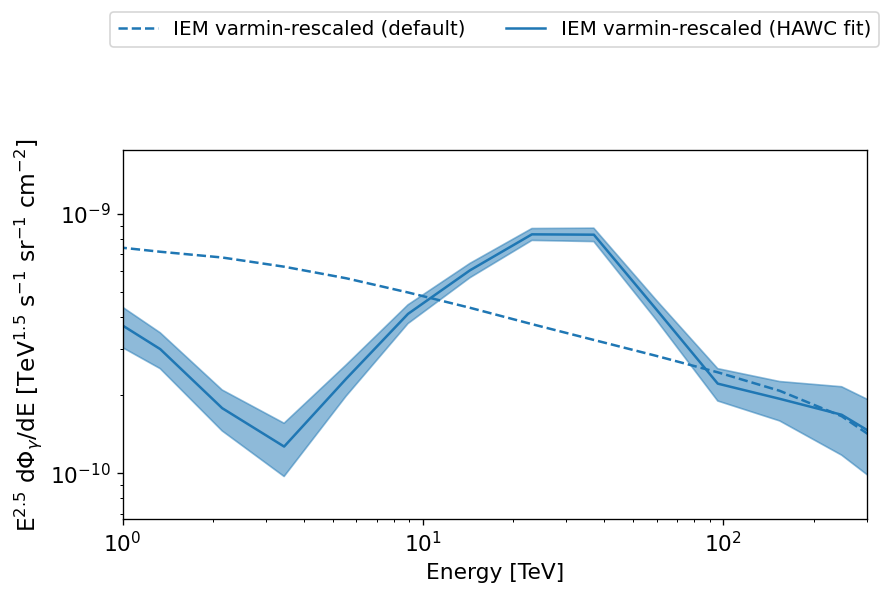

In [ ]:
# IEM spectra near HESS J1837.
from gammapy.maps import Map, WcsGeom

energy_axis = iem_varmin_rescaled[0].spatial_model.map.geom.axes[0]
fig_geom = WcsGeom.create(
    skydir=hessJ1837_pos.galactic,
    binsz=0.1,
    width=(80, 12),
    frame="galactic",
    proj="CAR",
    axes=[energy_axis],
)
energies = energy_axis.center.to("TeV")

plt.figure(figsize=(8, 4), dpi=120)
energy_power = 2.5
plt.xlim([1, 3e2])

# Default IEM, if the optional default object was created in the previous cell.
if "iem_varmin_rescaled_default" in globals() and len(iem_varmin_rescaled_default) > 0:
    for color, m, label in zip(defcol, iem_varmin_rescaled_default, ["IEM varmin-rescaled"]):
        m_dnde = Map.from_geom(fig_geom, data=m.evaluate_geom(fig_geom))
        values = np.mean(m_dnde.quantity, axis=(1, 2)).to("1/(TeV s sr cm2)")
        evalues = values * energies**energy_power
        plt.loglog(energies[evalues > 0], evalues[evalues > 0], "--", color=color, label=label + " (default)")
else:
    print("No default IEM model object found; plotting only the fitted IEM.")

# Fitted IEM.
for color, m, label in zip(defcol, iem_varmin_rescaled, ["IEM varmin-rescaled (HAWC fit)"]):
    if np.all(m.spectral_model.parameters.value == 1):
        continue
    m_dnde = Map.from_geom(fig_geom, data=m.evaluate_geom(fig_geom))
    values = np.mean(m_dnde.quantity, axis=(1, 2)).to("1/(TeV s sr cm2)")
    evalues = values * energies**energy_power
    plt.loglog(energies[evalues > 0], evalues[evalues > 0], color=color, label=label)

    norms, norms_errn, norms_errp = m.spectral_model.evaluate_error(energies)
    values_errn = values * norms_errn / norms
    values_errp = values * norms_errp / norms
    y_lo = (values - values_errn) * energies**energy_power
    y_hi = (values + values_errp) * energies**energy_power
    ax = plt.gca()
    ax.fill_between(energies.value, y_lo.value, y_hi.value, color=color, alpha=0.5)

plt.legend(ncol=2, fontsize=11.9, loc="upper center", bbox_to_anchor=(0.5, 1.4))
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel("Energy [TeV]", fontsize=13)
plt.ylabel(r"E$^{2.5}$ d$\Phi_{\gamma}$/dE [TeV$^{1.5}$ s$^{-1}$ sr$^{-1}$ cm$^{-2}$]", fontsize=14);


In [ ]:
#### Plot the default IEM from HERMES in the J1837 region  ####

#iem_varmin_rescaled = Models.read(f"{path}/iem_varmin_rescaled_default_HESS_J1837-069.yaml")
default_iem_hawc = iem_varmin_rescaled.to_template_sky_model(fig_geom, name=iem_varmin_rescaled[0].name)
default_iem_hawc.spatial_model.map.plot_interactive(add_cbar=True, cmap='ds9b')
#ax = default_iem_hawc.spatial_model.map.sum_over_axes().plot(cmap="ds9b", add_cbar=True, vmax=2e-6, stretch="sqrt")


The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.


interactive(children=(SelectionSlider(continuous_update=False, description='Select energy_true:', layout=Layou…

In [ ]:
# Plot the IEM from HERMES in the J1837 region re-fitted to 4HWC catalog data.
if not IEM_HESSJ1837_FITS.exists():
    raise FileNotFoundError(
        f"Missing HESS J1837 fitted IEM map: {IEM_HESSJ1837_FITS}\n"
        "Share iem_varmin_rescaled_4hwc_fit_HESS_J1837-069.fits or set HESSJ1837_DATA_DIR correctly."
    )

iem_HERMES_4HWC = Map.read(str(IEM_HESSJ1837_FITS))

print(iem_HERMES_4HWC.geom)
print(iem_HERMES_4HWC.geom.axes[0])

template_iem_4HWC = TemplateSpatialModel(
    iem_HERMES_4HWC,
    normalize=False,
)

template_iem_4HWC.map.plot_interactive(add_cbar=True, cmap="ds9b")


Map values are all zeros in at least one energy bin. Check and fix this!
The filename is not defined. Therefore, the model will not be serialised correctly. To set the filename, the "template_model.filename" attribute can be used.


WcsGeom

	axes       : ['lon', 'lat', 'energy_true']
	shape      : (np.int64(200), np.int64(200), 50)
	ndim       : 3
	frame      : galactic
	projection : CAR
	center     : 25.3 deg, -0.2 deg
	width      : 12.0 deg x 12.0 deg
	wcs ref    : 120.0 deg, 0.0 deg

MapAxis

	name       : energy_true
	unit       : 'TeV'     
	nbins      : 50        
	node type  : edges     
	edges min  : 1.0e-01 TeV
	edges max  : 1.0e+04 TeV
	interp     : log       



interactive(children=(SelectionSlider(continuous_update=False, description='Select energy_true:', layout=Layou…

## **Significance maps of the region**


### Pre-fit significance excess map

This section computes the excess-significance map before adding/fitting the ROI source model. The notebook keeps one safe plotting copy and avoids mutating the raw map data.


In [ ]:
from gammapy.maps import Map

if SIGNIFICANCE_STEP0_MAP.exists():
    significance = Map.read(str(SIGNIFICANCE_STEP0_MAP))
else:
    print(f"Optional precomputed significance map not found: {SIGNIFICANCE_STEP0_MAP}")
    significance = None


In [ ]:
%%time
# Significance excess map before including ROI source models.
# Correlation radius = 0.2 deg.
significance_roi_hessj1837, _, _ = make_maps_joint(
    datasets,
    radius=0.2 * u.deg,
    sum_over_energy_groups=True,
    method="excess",
)


-1.5276393 2.1468313
-1.2419728 2.2284462
-1.1472543 3.116142
-1.0451124 2.8619933
-0.9670747 3.7600791
-0.6803613 3.5825083
-0.65771925 3.0424016
-0.2265397 2.150774
CPU times: user 1.57 s, sys: 368 ms, total: 1.93 s
Wall time: 2.41 s


/home/a/Asu.Uenver/miniconda3/envs/gammapy-2.0/lib/python3.12/site-packages/gammapy/estimators/utils.py:1039: RuntimeWarning: divide by zero encountered in divide
  map_.ts.data - (map_.dnde.data / map_.dnde_err.data) ** 2


In [ ]:
# Sanity check and safe plotting copy for the pre-fit excess map.
# Gammapy may issue divide-by-zero RuntimeWarnings in masked or
# zero-uncertainty pixels. This is acceptable when the map is mostly finite.
finite_fraction_hessj1837 = summarize_map_finiteness(
    significance_roi_hessj1837,
    label="Pre-fit HESS J1837 excess significance map",
    warn_fraction=0.95,
)

significance_roi_hessj1837_safe = finite_map_copy(significance_roi_hessj1837)


Pre-fit HESS J1837 excess significance map:
  Shape: (1, 200, 200)
  Finite pixels: 39822 / 40000 (0.996)
  NaN pixels: 178
  Inf pixels: 0
  Finite min/max: -3.1619229307099603 30.131015350056483


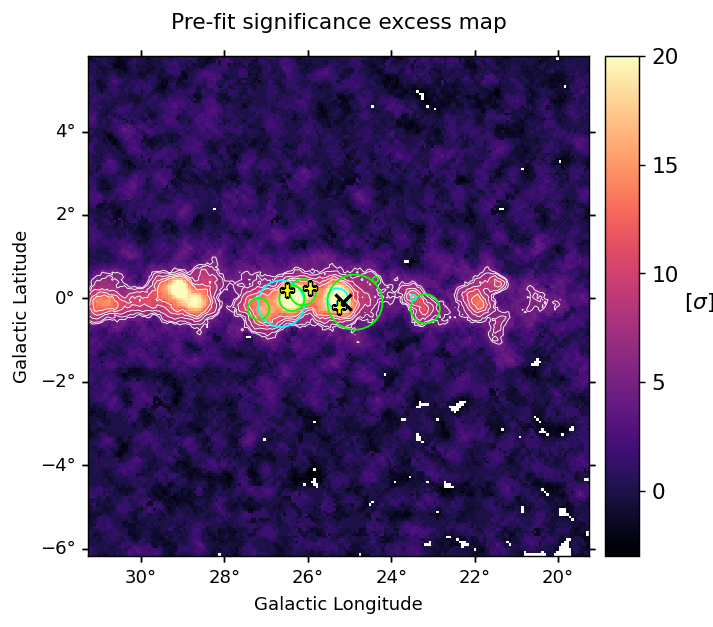

In [ ]:
# Plot the pre-fit significance excess map.
fig = plt.figure(figsize=(13, 5), dpi=130)

ax = significance_roi_hessj1837_safe.plot(
    clim=[-3, 20],
    cmap="magma",
)

im = [
    obj for obj in ax.get_children()
    if isinstance(obj, mpl.image.AxesImage)
][0]

# Plot selected zoom-region seed-list sources with catalog-match colors.
# cyan = matched/renamed to the full 4HWC catalog; lime = unmatched selected seed.
plot_catalog_matched_seed_overlays(
    models_4hwc_zoom_region,
    ax=ax,
    linestyle="-",
    kwargs_point=dict(marker="."),
)

# Plot contours using the safe map.
sig_contours = ax.contour(
    significance_roi_hessj1837_safe.data[0],
    levels=[5, 6, 8, 10, 12],
    colors="white",
    zorder=0,
    linewidths=0.5,
)

# Add target and pulsar markers.
add_standard_markers(ax, include_legend=False)

# Title and labels.
plt.title(r"Pre-fit significance excess map", loc="center", fontsize=12, pad=15)

cb_ax = fig.add_axes([0.67, 0.11, 0.02, 0.77])
cb = fig.colorbar(
    im,
    cax=cb_ax,
    orientation="vertical",
    ticks=[0, 5, 10, 15, 20],
)

cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.tick_params(axis="both", which="major", labelsize=12)
cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-140, x=2.8);


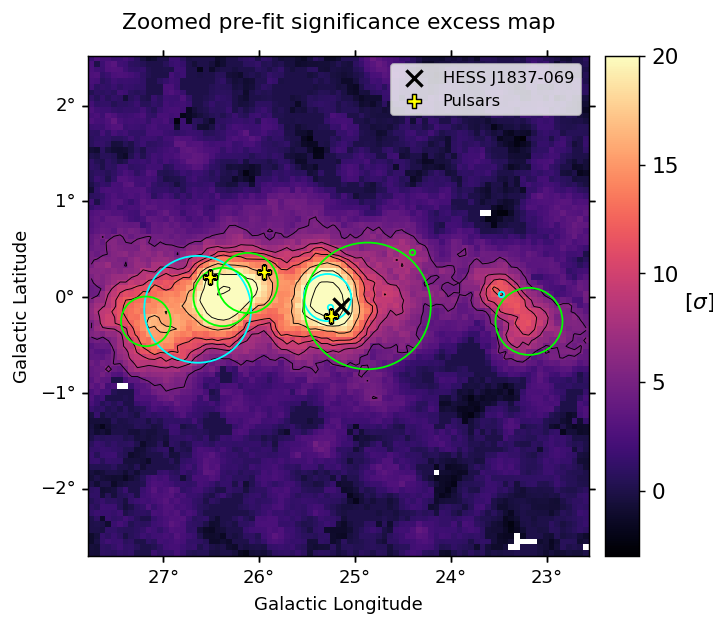

In [ ]:
# Zoomed version of the pre-fit excess-significance map.
fig = plt.figure(figsize=(13, 5), dpi=130)

tmp_excess = significance_roi_hessj1837_safe.cutout(
    zoom_analysis_center,
    width=ZOOM_ANALYSIS_WIDTH_LON,
)

ax = tmp_excess.plot(
    clim=[-3, 20],
    cmap="magma",
)

im = [
    obj for obj in ax.get_children()
    if isinstance(obj, mpl.image.AxesImage)
][0]

# Plot selected zoom-region seed-list sources with catalog-match colors.
plot_catalog_matched_seed_overlays(
    models_4hwc_zoom_region,
    ax=ax,
    linestyle="-",
    kwargs_point=dict(marker="."),
)

ax.contour(
    tmp_excess.data[0],
    levels=[5, 8, 10, 12, 16, 20, 25],
    colors="black",
    zorder=0,
    linewidths=0.5,
)

add_standard_markers(ax, include_legend=True)

plt.title(
    r"Zoomed pre-fit significance excess map",
    loc="center",
    fontsize=12,
    pad=15,
)

cb_ax = fig.add_axes([0.67, 0.11, 0.02, 0.77])
cb = fig.colorbar(
    im,
    cax=cb_ax,
    orientation="vertical",
    ticks=[0, 5, 10, 15, 20],
)

cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.tick_params(axis="both", which="major", labelsize=12)
cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-140, x=2.8);


### TS joint (on all the HAWC datasets) map before including sources in the model

### ATTENTION:
- The TS map is slower so let's define a mask_fit first add a margin of PSF_MAX_RADIUS (and the TSMapEstimator function is not defined further) --> SO IF THE CELL BELOW IS EXECUTED YOU CAN'T DO THE REST OH THE CODE
- The reference model is the one of 4HWC J1837


In [ ]:
# Prepare a copied dataset bundle for the optional pre-fit likelihood sqrt(TS) scan.
# Do not erode or otherwise modify the live `datasets` object before the main fit.

import copy

datasets_for_prefit_ts = copy.deepcopy(datasets)

for d in datasets_for_prefit_ts:
    if d.mask_fit is not None:
        d.mask_fit = d.mask_fit.binary_erode(PSF_MAX_RADIUS)


In [ ]:
%%time
# Pre-fit likelihood sqrt(TS) map.
# This is not a raw TS map: make_maps_joint(..., method="joint") returns result["sqrt_ts"].
# It is computed on a copied dataset object so the main fit below is not affected.

datasets_for_prefit_ts.models = None

sqrt_ts_roi_prefit, _, result_roi_prefit_ts = make_maps_joint(
    datasets_for_prefit_ts,
    radius=0.1 * u.deg,
    sum_over_energy_groups=False,
    n_jobs=6,
    method="joint",
)


Linear interpolation should be used with care on the 'norm' parameter. We recommend using 'log' interpretation instead.


CPU times: user 8.52 s, sys: 3.7 s, total: 12.2 s
Wall time: 1min 4s


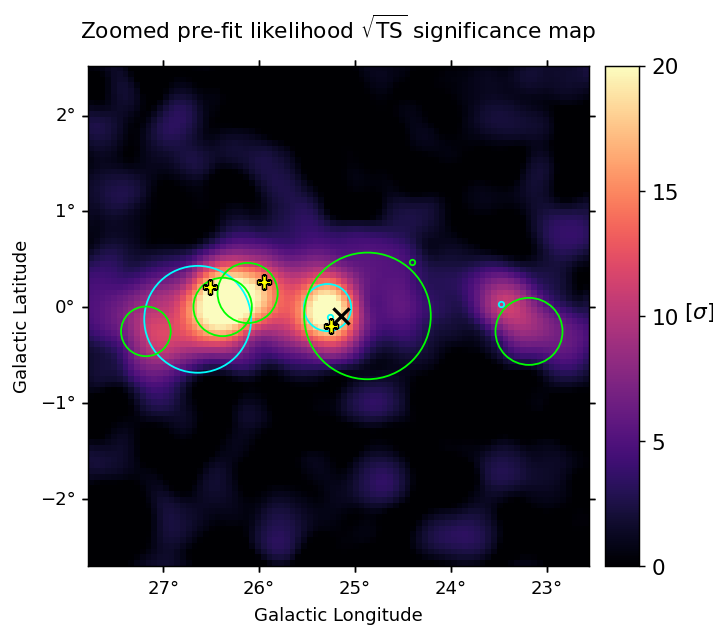

In [ ]:
# Plot the zoomed pre-fit likelihood sqrt(TS) significance map.
# This is not a raw TS map. It is a likelihood sqrt(TS) significance map.
# The colorbar is therefore in sigma-like units.

fig = plt.figure(figsize=(13, 5), dpi=130)

tmp_prefit_ts = sqrt_ts_roi_prefit.cutout(
    zoom_analysis_center,
    width=ZOOM_ANALYSIS_WIDTH_LON,
)

ax = tmp_prefit_ts.plot(
    clim=[0, 20],
    cmap="magma",
    interpolation="nearest",
)

im = [
    obj for obj in ax.get_children()
    if isinstance(obj, mpl.image.AxesImage)
][0]

# Plot selected zoom-region seed-list sources with catalog-match colors.
plot_catalog_matched_seed_overlays(
    models_4hwc_zoom_region,
    ax=ax,
    linestyle="-",
    kwargs_point=dict(marker="."),
)

add_standard_markers(ax, include_legend=False)

plt.title(
    r"Zoomed pre-fit likelihood $\sqrt{\mathrm{TS}}$ significance map",
    loc="center",
    fontsize=12,
    pad=15,
)

cb_ax = fig.add_axes([0.67, 0.11, 0.02, 0.77])
cb = fig.colorbar(
    im,
    cax=cb_ax,
    orientation="vertical",
    ticks=[0, 5, 10, 15, 20],
)

cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.tick_params(axis="both", which="major", labelsize=12)

# The plotted quantity is sqrt(TS), so it is shown in approximate sigma units.
cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-140, x=2.8);


**Added:** the cell above is the original, unmodified HAWC pre-fit significance map. The cell below only adds a visual overlay on top of the same figure -- Fermi-LAT's own independently-computed TS contours (from fermipy's ROI analysis, not from any joint statistic), plus a marker at the Fermi-LAT target position -- so you can visually compare where each instrument sees signal in this region.

In [ ]:
# Overlay Fermi-LAT TS contours (from fermipy's own ROI analysis) on the HAWC
# significance map above -- a visual cross-check only, does NOT feed into any
# fit. The joint spectral fit further below is what actually combines the
# two instruments statistically; this is just an annotation on an otherwise
# completely unmodified HAWC figure.
if FERMI_TS_MAP_FITS is not None and FERMI_TS_MAP_FITS.exists():
    fermi_ts_map_raw = Map.read(str(FERMI_TS_MAP_FITS))
    if fermi_ts_map_raw.data.ndim > 2:
        fermi_ts_map_raw = fermi_ts_map_raw.sum_over_axes()

    fermi_ts_reproj = fermi_ts_map_raw.interp_to_geom(tmp_prefit_ts.geom.to_image())
    print("Fermi-LAT TS map (reprojected) min/max:",
          np.nanmin(fermi_ts_reproj.data), np.nanmax(fermi_ts_reproj.data))

    ts_levels = [sigma_to_ts(s, df=1) for s in [3, 4, 5]]  # ~3,4,5 sigma-like contours
    ax.contour(
        fermi_ts_reproj.data,
        levels=ts_levels,
        colors="cyan",
        linewidths=1.2,
        linestyles="--",
    )
    ax.text(
        0.02, 0.98, "cyan dashed: Fermi-LAT TS contours (fermipy, 3/4/5$\sigma$-like)",
        transform=ax.transAxes, color="cyan", fontsize=9, va="top",
    )

    add_sky_marker(
        ax, hessJ1837_pos, label="Fermi-LAT ROI center",
        style="peak", color="cyan", marker="D", s=70,
    )
else:
    print(
        f"Optional Fermi-LAT TS map not found at {FERMI_TS_MAP_FITS} "
        "-- skipping contour overlay. Set FERMI_TS_MAP_FITS to the real "
        "filename in your roi_analysis folder to enable it, or leave it "
        "as None to skip permanently."
    )


Optional Fermi-LAT TS map not found at /project/ls-gruen/users/asu.uenver/fermi/output_hess1837_0651/roi_analysis/hess1837_postdelete_ts_pointsource_powerlaw_2.00_tsmap_0651.fits -- skipping contour overlay. Set FERMI_TS_MAP_FITS to the real filename in your roi_analysis folder to enable it, or leave it as None to skip permanently.


<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\s'
/scratch-local/slurm-job-tmp-16390091/ipykernel_2235612/4047760429.py:24: SyntaxWarning: invalid escape sequence '\s'
  0.02, 0.98, "cyan dashed: Fermi-LAT TS contours (fermipy, 3/4/5$\sigma$-like)",


## **HAWC analysis**


In [ ]:
## Diagnostic of the previous pre-fit likelihood sqrt(TS) map.

print(type(sqrt_ts_roi_prefit))
print(sqrt_ts_roi_prefit.meta)

data = sqrt_ts_roi_prefit.data
print("min/max:", np.nanmin(data), np.nanmax(data))

## Pixel scale diagnostic.
print(tmp_prefit_ts.geom)
print("Pixel size:", tmp_prefit_ts.geom.pixel_scales)

# The pixel size is ~0.06 deg, while the likelihood test-source/PSF scale
# is larger than one pixel. Neighboring sqrt(TS) values are therefore
# correlated, so this map is expected to look smoother than the excess map.


<class 'gammapy.maps.wcs.ndmap.WcsNDMap'>
{}
min/max: -1.01350962345455 24.79757388409427
WcsGeom

	axes       : ['lon', 'lat', 'energy']
	shape      : (np.int64(87), np.int64(87), 1)
	ndim       : 3
	frame      : galactic
	projection : CAR
	center     : 25.2 deg, -0.1 deg
	width      : 5.2 deg x 5.2 deg
	wcs ref    : 120.0 deg, 0.0 deg

Pixel size: [0d03m36s 0d03m36s]


### The zoom-region 4HWC source model used for fitting

The notebook now distinguishes between:

- `models_4hwc`: the full 127-component HAWC seed-list model with internal names;
- `models_4hwc_zoom_region`: all seed-list source models whose centroids fall inside the zoomed analysis region, **renamed by position-matching to the full 4HWC catalog CSV**;
- `models_4hwc_roi_matched`: a backward-compatible alias for `models_4hwc_zoom_region`;
- `models` / `datasets.models`: the model actually attached to the datasets and fitted.

For science plots, source overlays should correspond to the zoom-region/fitted source model, not the full 127-component seed-list context. cyan denotes selected seed-list sources matched/renamed to the full 4HWC catalog; lime denotes selected seed-list sources that remain unmatched. In this default setup, all selected zoom-region 4HWC/HAWC sources are included in the fit with fixed spatial parameters and free spectral normalizations. Spectral-shape parameters can be freed by setting `FREE_SOURCE_SPECTRAL_SHAPES = True`.


### Add the inputmodels to the DL4 datasets


In [ ]:
# Add zoom-region 4HWC/HAWC source models to the datasets.
#
# The source overlays in the maps should correspond to these selected/fitted models,
# not to the full 127-component seed-list object `models_4hwc`.
# cyan marks matched/renamed full-catalog 4HWC seeds; lime marks unmatched seeds.

import copy
from gammapy.modeling.models import Models

# Use an old hand-written input-model YAML only if explicitly requested.
# The default is False so the model is built from all seed-list sources inside the zoomed analysis region.
USE_EXISTING_INPUT_MODELS_YAML = False

# Optional: include the fitted varmin IEM model as an additional sky model.
# Keep False unless you intentionally want to refit the IEM together with the ROI sources.
INCLUDE_VARMIN_IEM_IN_FIT = False

if USE_EXISTING_INPUT_MODELS_YAML and INPUT_MODELS_YAML.exists():
    models = read_models_from_yaml_dir(INPUT_MODELS_YAML)
    print(f"Loaded input models from {INPUT_MODELS_YAML}")
else:
    models = Models([copy.deepcopy(model) for model in models_4hwc_zoom_region])
    print("Using all 4HWC/HAWC seed-list source models inside the zoomed analysis region.")

if INCLUDE_VARMIN_IEM_IN_FIT:
    for model in iem_varmin_rescaled_default:
        models.append(copy.deepcopy(model))
    print("Included varmin IEM model in the fit.")

# Conservative fit setup:
#   - keep all source spatial parameters fixed;
#   - fit every selected source at least through its spectral normalization;
#   - optionally free source spectral-shape parameters using the toggle below.
FREE_SOURCE_SPECTRAL_SHAPES = False
NORMALIZATION_PARAMETER_NAMES = {"amplitude", "norm", "lambda", "lambda_", "prefactor"}
REFERENCE_PARAMETER_NAMES = {"reference", "pivot", "scale", "ebreak", "e_0"}
zoom_region_source_names = set(models_4hwc_zoom_region.names)

for model in models:
    is_selected_hawc_source = getattr(model, "name", None) in zoom_region_source_names

    if is_selected_hawc_source and getattr(model, "spatial_model", None) is not None:
        for par in model.spatial_model.parameters:
            par.frozen = True

    if is_selected_hawc_source and getattr(model, "spectral_model", None) is not None:
        for par in model.spectral_model.parameters:
            pname = par.name.lower()
            if pname in REFERENCE_PARAMETER_NAMES:
                par.frozen = True
            elif FREE_SOURCE_SPECTRAL_SHAPES:
                par.frozen = False
            elif pname in NORMALIZATION_PARAMETER_NAMES:
                par.frozen = False
            else:
                par.frozen = True

# Attach the model to all datasets before fitting.
datasets.models = models

print("Models attached to datasets for fitting:")
for model in datasets.models:
    print(f"  - {model.name}")

print("\nFree parameters before fit:")
for par in datasets.models.parameters.free_parameters:
    print(par)


Using all 4HWC/HAWC seed-list source models inside the zoomed analysis region.


Models attached to datasets for fitting:
  - UNMATCHED Seed_27
  - UNMATCHED Seed_56
  - UNMATCHED Seed_58
  - 4HWC J1837-0650
  - 4HWC J1840-0536
  - UNMATCHED Seed_21
  - UNMATCHED Seed_144
  - 4HWC J1837-0650 seed2
  - UNMATCHED ROI4_add1_step0
  - 4HWC J1834-0828

Free parameters before fit:
Parameter(name='amplitude', value=1.9223104860244896e-14, factor=1.9223104860244896e-14, scale=1.0, unit=Unit("1 / (TeV s cm2)"), min=3.0937802357484667e-18, max=3.0937802357484668e-12, frozen=False, prior=None, id=0x154f525dfa40)
Parameter(name='amplitude', value=1.336319008180809e-15, factor=1.336319008180809e-15, scale=1.0, unit=Unit("1 / (TeV s cm2)"), min=1.7089362920608141e-18, max=1.708936292060814e-12, frozen=False, prior=None, id=0x154f525decf0)
Parameter(name='amplitude', value=1.541403310424313e-14, factor=1.541403310424313e-14, scale=1.0, unit=Unit("1 / (TeV s cm2)"), min=2.1757795075072476e-18, max=2.1757795075072472e-12, frozen=False, prior=None, id=0x154f5279c4d0)
Parameter(name=

In [ ]:
print(models)


Models

Component 0: SkyModel

  Name                      : UNMATCHED Seed_27
  Datasets names            : None
  Spectral model type       : LogParabolaSpectralModel
  Spatial  model type       : GeneralizedGaussianSpatialModel
  Temporal model type       : 
  Parameters:
    amplitude                     :   1.92e-14   +/- 1.2e-14 1 / (TeV s cm2)
    reference             (frozen):     10.000       TeV         
    alpha                 (frozen):      3.053                   
    beta                  (frozen):      0.139                   
    lon_0                 (frozen):     23.185       deg         
    lat_0                 (frozen):     -0.250       deg         
    r_0                   (frozen):      0.350       deg         
    eta                   (frozen):      0.992                   
    e                     (frozen):      0.000                   
    phi                   (frozen):      0.000       deg         

Component 1: SkyModel

  Name                      :

### Define the optimizer and fitting the inputmodels


In [ ]:
# Define the optimizer
minuit_opts = {"strategy": 1}
fit = Fit(store_trace=True, optimize_opts={"print_level": 1, "tol": 0.1})

fit.backend = "minuit"
fit.optimize_opts = minuit_opts


In [ ]:
%%time
# Fit the models
results = fit.run(datasets)
print(results)


OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 592
	total stat : -1489846915.16

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.

CPU times: user 4min 26s, sys: 898 ms, total: 4min 27s
Wall time: 4min 29s


## **Joint HAWC + Fermi-LAT fit (added)**

This is a genuinely new, additional result -- it does not replace or alter the HAWC-only fit above. `models` here is deep-copied into `models_joint` before use, so fitting `datasets_joint` (HAWC + the Fermi-LAT flux points) can never mutate the parameter values the HAWC-only `results`, `model_J1837_0650`, or any later cell in this notebook relies on. Everything below this point in the *original* notebook (residual maps, `npred`, per-source flux points) still reflects the HAWC-only fit, completely unaffected by this section.

In [ ]:
import copy as _copy
from gammapy.modeling.models import ExpCutoffPowerLawSpectralModel, SkyModel

models_joint = _copy.deepcopy(models)

target_name = "4HWC J1837-0650"
for m in models_joint:
    if getattr(m, "name", None) == target_name:
        continue
    for par in m.parameters:
        par.frozen = True  # Fermi's flux points don't constrain these

# --- Replace the target's spectral model with an ECPL, joint-fit only. ---
# `models`/`datasets`/`results` (the HAWC-only fit) still use the original
# LogParabola -- this only affects models_joint.
target_model_lp = models_joint[target_name]
lp = target_model_lp.spectral_model

ecpl_spectral_model = ExpCutoffPowerLawSpectralModel(
    amplitude=lp.amplitude.quantity,
    reference=lp.reference.quantity,
    index=lp.alpha.value,      # use the LogParabola's alpha as the initial index guess
    lambda_="0.1 TeV-1",       # initial guess -> Ecut ~ 10 TeV; adjust if the fit struggles
)
# alpha (cutoff sharpness) stays at its default of 1 and frozen -- a standard
# exponential cutoff, not a sub/super-exponential one.

target_model_joint = SkyModel(
    spatial_model=_copy.deepcopy(target_model_lp.spatial_model),
    spectral_model=ecpl_spectral_model,
    name=target_name,
)

for par in target_model_joint.spatial_model.parameters:
    par.frozen = True  # position/shape fixed, same as the HAWC-only fit

target_model_joint.spectral_model.reference.frozen = True
target_model_joint.spectral_model.amplitude.frozen = False
target_model_joint.spectral_model.index.frozen = False
target_model_joint.spectral_model.lambda_.frozen = False

models_joint.remove(target_name)
models_joint.append(target_model_joint)

datasets_joint = datasets.copy()
datasets_joint.append(fermi_flux_dataset)

for d in datasets_joint:
    if d.name == "fermi-lat":
        d.models = [models_joint[target_name]]
    else:
        d.models = models_joint

minuit_opts_joint = {"strategy": 1}
fit_joint = Fit(store_trace=True, optimize_opts={"print_level": 1, "tol": 0.1})
fit_joint.backend = "minuit"
fit_joint.optimize_opts = minuit_opts_joint

results_joint = fit_joint.run(datasets_joint)
print(results_joint)

/home/a/Asu.Uenver/miniconda3/envs/gammapy-2.0/lib/python3.12/site-packages/astropy/units/quantity.py:653: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/a/Asu.Uenver/miniconda3/envs/gammapy-2.0/lib/python3.12/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/a/Asu.Uenver/miniconda3/envs/gammapy-2.0/lib/python3.12/site-packages/astropy/units/quantity.py:653: RuntimeWarning: overflow encountered in multiply
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/a/Asu.Uenver/miniconda3/envs/gammapy-2.0/lib/python3.12/site-packages/gammapy/maps/wcs/ndmap.py:952: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  return scipy.signal.convolve(image, kernel, method=method, mode=mode)
/home

OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully, but uncertainties are unreliable.
	nfev       : 626
	total stat : -1489846883.60

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.



In [ ]:
# Quick comparison: HAWC-only vs. joint HAWC+Fermi-LAT best-fit target parameters.
model_J1837_0650_hawc_only = models["4HWC J1837-0650"]
model_J1837_0650_joint = models_joint["4HWC J1837-0650"]

print("HAWC-only fit -- 4HWC J1837-0650 free parameters:")
for par in model_J1837_0650_hawc_only.parameters.free_parameters:
    print(f"  {par.name:12s} = {par.value:.4g} +/- {par.error:.2g} {par.unit}")

print("\nJoint HAWC+Fermi-LAT fit -- 4HWC J1837-0650 free parameters:")
for par in model_J1837_0650_joint.parameters.free_parameters:
    print(f"  {par.name:12s} = {par.value:.4g} +/- {par.error:.2g} {par.unit}")


HAWC-only fit -- 4HWC J1837-0650 free parameters:
  amplitude    = 4.226e-14 +/- 1.8e-15 1 / (TeV s cm2)

Joint HAWC+Fermi-LAT fit -- 4HWC J1837-0650 free parameters:
  index        = 2.123 +/- 0.077 
  amplitude    = 8.562e-14 +/- 2.7e-14 1 / (TeV s cm2)
  lambda_      = 0.05225 +/- 0.0046 1 / TeV


In [ ]:
# stat_sum() give the total fit statistic S = - 2 * log(L), for likelihood L, with the current parameters
# TS = S_0 - S_1 = test statistic to obtain significance (or p-value)
L = datasets.stat_sum()
print(L)


-1489846915.159785


In [ ]:
# Check which zoom-region 4HWC/HAWC models are actually present in the fitted dataset model.

from gammapy.modeling.models import Models


def get_model_names(models_like):
    return [getattr(m, "name", str(m)) for m in list(models_like)]

selected_hawc_names = set(get_model_names(models_4hwc_zoom_region))
fitted_model_names = set(get_model_names(datasets.models))

common_names = sorted(selected_hawc_names & fitted_model_names)
selected_not_fitted = sorted(selected_hawc_names - fitted_model_names)
fitted_not_selected = sorted(fitted_model_names - selected_hawc_names)

models_hawc_fitted = Models([
    model for model in datasets.models
    if getattr(model, "name", None) in selected_hawc_names
])

print(f"Number of full seed-list models:          {len(models_4hwc)}")
print(f"Number of selected zoom-region models:   {len(selected_hawc_names)}")
print(f"Number of fitted dataset models:         {len(fitted_model_names)}")
print(f"Number of selected HAWC models fitted:   {len(common_names)}")

print("\nSelected zoom-region HAWC models included in the fit:")
for name in common_names:
    print(f"  - {name}")

if selected_not_fitted:
    print("\nWARNING: selected zoom-region HAWC models not in datasets.models:")
    for name in selected_not_fitted:
        print(f"  - {name}")

print("\nFitted models not in the selected zoom-region HAWC list:")
if fitted_not_selected:
    for name in fitted_not_selected:
        print(f"  - {name}")
else:
    print("  None")

# Fitted overlay color summary. These are the source overlays used in post-fit maps.
matched_fitted_overlay_models, unmatched_fitted_overlay_models = split_catalog_matched_seed_models(models_hawc_fitted)

print()
print(f"Catalog-matched fitted seed models shown in cyan: {len(matched_fitted_overlay_models)}")
for name in matched_fitted_overlay_models.names:
    print(f"  cyan - {name}")

print()
print(f"Unmatched fitted seed models shown in lime: {len(unmatched_fitted_overlay_models)}")
for name in unmatched_fitted_overlay_models.names:
    print(f"  lime   - {name}")


Number of full seed-list models:          127
Number of selected zoom-region models:   10
Number of fitted dataset models:         10
Number of selected HAWC models fitted:   10

Selected zoom-region HAWC models included in the fit:
  - 4HWC J1834-0828
  - 4HWC J1837-0650
  - 4HWC J1837-0650 seed2
  - 4HWC J1840-0536
  - UNMATCHED ROI4_add1_step0
  - UNMATCHED Seed_144
  - UNMATCHED Seed_21
  - UNMATCHED Seed_27
  - UNMATCHED Seed_56
  - UNMATCHED Seed_58

Fitted models not in the selected zoom-region HAWC list:
  None

Catalog-matched fitted seed models shown in cyan: 4
  cyan - 4HWC J1837-0650
  cyan - 4HWC J1840-0536
  cyan - 4HWC J1837-0650 seed2
  cyan - 4HWC J1834-0828

Unmatched fitted seed models shown in lime: 6
  lime   - UNMATCHED Seed_27
  lime   - UNMATCHED Seed_56
  lime   - UNMATCHED Seed_58
  lime   - UNMATCHED Seed_21
  lime   - UNMATCHED Seed_144
  lime   - UNMATCHED ROI4_add1_step0


In [ ]:
# Summarize free fitted parameters for the models currently attached to the datasets.

import pandas as pd
import numpy as np

rows = []

for model in datasets.models:
    model_name = getattr(model, "name", "")
    model_type = type(model).__name__

    free_params = []
    for par in model.parameters:
        if not par.frozen:
            value = par.value
            error = getattr(par, "error", np.nan)

            free_params.append(
                f"{par.name}={value:.4g}"
                + (f" ± {error:.2g}" if np.isfinite(error) else "")
            )

    rows.append(
        {
            "model": model_name,
            "type": model_type,
            "n_free": len(free_params),
            "free_parameters": ", ".join(free_params),
        }
    )

fit_param_summary = pd.DataFrame(rows)
fit_param_summary

,model,type,n_free,free_parameters
0,UNMATCHED Seed_27,SkyModel,1,amplitude=2.585e-14 ± 1.4e-15
1,UNMATCHED Seed_56,SkyModel,1,amplitude=1.939e-15 ± 4.4e-16
2,UNMATCHED Seed_58,SkyModel,1,amplitude=1.676e-14 ± 1.7e-15
3,4HWC J1837-0650,SkyModel,1,amplitude=4.226e-14 ± 1.8e-15
4,4HWC J1840-0536,SkyModel,1,amplitude=5.101e-14 ± 2.7e-15
5,UNMATCHED Seed_21,SkyModel,1,amplitude=1.163e-14 ± 9.1e-16
6,UNMATCHED Seed_144,SkyModel,1,amplitude=7.113e-15 ± 8.9e-16
7,4HWC J1837-0650 seed2,SkyModel,1,amplitude=5.033e-15 ± 8.1e-16
8,UNMATCHED ROI4_add1_step0,SkyModel,1,amplitude=8.076e-15 ± 9.8e-16
9,4HWC J1834-0828,SkyModel,1,amplitude=2.07e-15 ± 3.8e-16


### Parameters of the outputmodels


In [ ]:
results.parameters.to_table()
print(models)


Models

Component 0: SkyModel

  Name                      : UNMATCHED Seed_27
  Datasets names            : None
  Spectral model type       : LogParabolaSpectralModel
  Spatial  model type       : GeneralizedGaussianSpatialModel
  Temporal model type       : 
  Parameters:
    amplitude                     :   2.59e-14   +/- 1.4e-15 1 / (TeV s cm2)
    reference             (frozen):     10.000       TeV         
    alpha                 (frozen):      3.053                   
    beta                  (frozen):      0.139                   
    lon_0                 (frozen):     23.185       deg         
    lat_0                 (frozen):     -0.250       deg         
    r_0                   (frozen):      0.350       deg         
    eta                   (frozen):      0.992                   
    e                     (frozen):      0.000                   
    phi                   (frozen):      0.000       deg         

Component 1: SkyModel

  Name                      :

In [ ]:
OUTPUT_MODELS_YAML.parent.mkdir(parents=True, exist_ok=True)
models.write(str(OUTPUT_MODELS_YAML), overwrite=True)
print(f"Wrote fitted output models to: {OUTPUT_MODELS_YAML}")


Wrote fitted output models to: /project/ls-gruen/users/asu.uenver/outputs/24_outputmodels_4HWC_pass5p2_Ch103to1360NN_HESS_J1837-069.yaml


### Post-fit residual excess map in the zoomed analysis region

This section computes the post-fit residual excess-significance map after fitting the zoom-region HAWC source model. The **zoomed 5.2 deg × 5.2 deg cutout** is now treated as the primary analysis region for both the 2D residual map and the 1D residual-significance histogram. This keeps the visual map and the histogram statistically consistent.


The zoom width is intentionally set to 5.2 deg to exclude the residual boundary excess near Galactic longitude ~22 deg from the primary residual-distribution analysis. If the scientific goal is to model that boundary excess instead, increase the zoom width again and include the relevant boundary source in the fitted model.

In [ ]:
%%time
# Significance residual excess map after fitting the ROI source model.
# Correlation radius = 0.2 deg.
significance_roi_4hwc1837, _, _ = make_maps_joint(
    datasets,
    radius=0.2 * u.deg,
    sum_over_energy_groups=True,
    method="excess",
)


-1.5276868 1.4882373
-1.2419851 1.4736807
-1.1543094 1.5831286
-1.045253 1.711385
-0.9672253 2.018773
-0.7939203 2.508641
-0.9839262 2.7220876
-0.39634565 2.1497219
CPU times: user 1.11 s, sys: 18.8 ms, total: 1.13 s
Wall time: 1.13 s


/home/a/Asu.Uenver/miniconda3/envs/gammapy-2.0/lib/python3.12/site-packages/gammapy/estimators/utils.py:1039: RuntimeWarning: divide by zero encountered in divide
  map_.ts.data - (map_.dnde.data / map_.dnde_err.data) ** 2


In [ ]:
# Sanity check and safe zoomed analysis-region copies for the post-fit residual excess map.
#
# The full map is kept for bookkeeping, but the primary residual-analysis region
# is the same zoomed cutout used for the fitted-source model.

finite_fraction_4hwc1837_full = summarize_map_finiteness(
    significance_roi_4hwc1837,
    label="Full post-fit residual excess significance map",
    warn_fraction=0.50,
)

significance_roi_4hwc_safe_full = finite_map_copy(significance_roi_4hwc1837)

# Define the primary post-fit residual analysis map as the zoom-region cutout.
# Use the same center/width used when selecting the HAWC sources for the fit.
significance_roi_4hwc_zoom_safe = significance_roi_4hwc_safe_full.cutout(
    zoom_analysis_center,
    width=ZOOM_ANALYSIS_WIDTH_LON,
)

finite_fraction_4hwc1837_zoom = summarize_map_finiteness(
    significance_roi_4hwc_zoom_safe,
    label="Zoomed post-fit residual excess significance map",
    warn_fraction=0.50,
)

# Backward-compatible aliases for later cells.
# From this point on, `significance_roi_4hwc_safe` refers to the zoomed map.
significance_roi_4hwc_safe = significance_roi_4hwc_zoom_safe
significance_roi_4hwc_for_peaks = peak_search_map(significance_roi_4hwc_safe)

print("Primary post-fit residual analysis region")
print("-----------------------------------------")
print(significance_roi_4hwc_safe.geom)
print("Pixel size:", significance_roi_4hwc_safe.geom.pixel_scales)
print(f"Finite-pixel fraction in zoomed region: {finite_fraction_4hwc1837_zoom:.3f}")


Full post-fit residual excess significance map:
  Shape: (1, 200, 200)
  Finite pixels: 39822 / 40000 (0.996)
  NaN pixels: 178
  Inf pixels: 0
  Finite min/max: -3.704529462287029 24.159562093629845
Zoomed post-fit residual excess significance map:
  Shape: (1, 87, 87)
  Finite pixels: 7556 / 7569 (0.998)
  NaN pixels: 13
  Inf pixels: 0
  Finite min/max: -3.704529462287029 3.990232288062934
Primary post-fit residual analysis region
-----------------------------------------
WcsGeom

	axes       : ['lon', 'lat', 'energy']
	shape      : (np.int64(87), np.int64(87), 1)
	ndim       : 3
	frame      : galactic
	projection : CAR
	center     : 25.2 deg, -0.1 deg
	width      : 5.2 deg x 5.2 deg
	wcs ref    : 120.0 deg, 0.0 deg

Pixel size: [0d03m36s 0d03m36s]
Finite-pixel fraction in zoomed region: 0.998


peak significance l b


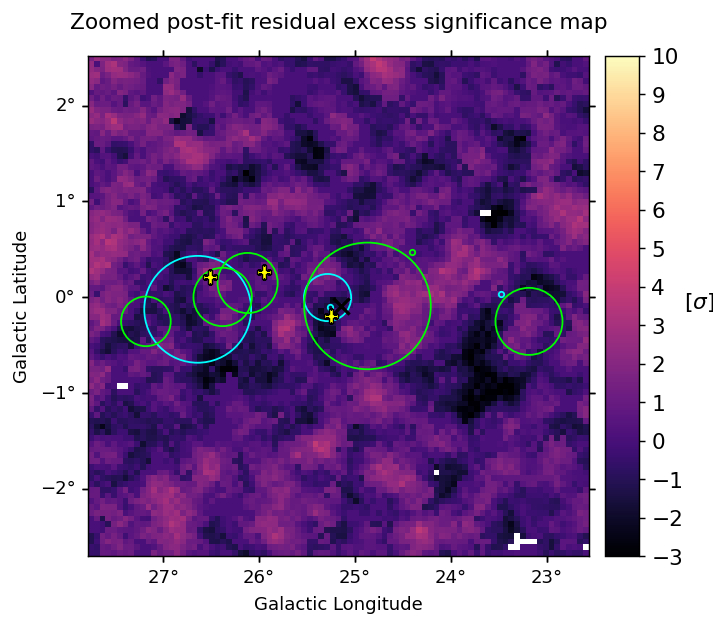

In [ ]:
# Plot the zoomed post-fit significance residual excess map.
# This is the primary 2D residual-excess analysis region.

fig = plt.figure(figsize=(13, 5), dpi=130)

ax = significance_roi_4hwc_safe.plot(
    clim=[-3, 10],
    cmap="magma",
    interpolation="nearest",
)

im = [
    obj for obj in ax.get_children()
    if isinstance(obj, mpl.image.AxesImage)
][0]

# Plot the zoom-region HAWC source model components actually included in the fitted model.
# cyan = matched/renamed to the full 4HWC catalog; lime = unmatched selected seed.
plot_catalog_matched_seed_overlays(
    models_hawc_fitted,
    ax=ax,
    linestyle="-",
    kwargs_point=dict(marker="."),
)

# Plot residual contours using the same zoomed map shown in the image.
sig_contours = ax.contour(
    significance_roi_4hwc_safe.data[0],
    levels=[4, 5],
    colors="white",
    zorder=0,
    linewidths=0.5,
)

# Add target and pulsar markers.
add_standard_markers(ax, include_legend=False)

# Get and plot peaks with significance > 4 sigma in the zoomed map.
peaks = find_peaks(
    significance_roi_4hwc_for_peaks,
    threshold=4,
    min_distance="0.1 deg",
)
add_peak_markers(ax, peaks)

plt.title(
    r"Zoomed post-fit residual excess significance map",
    loc="center",
    fontsize=12,
    pad=15,
)

cb_ax = fig.add_axes([0.67, 0.11, 0.02, 0.77])
cb = fig.colorbar(
    im,
    cax=cb_ax,
    orientation="vertical",
    ticks=[-3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
)

cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.tick_params(axis="both", which="major", labelsize=12)
cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-140, x=2.8);


## Significance distribution for the zoomed post-fit residual map

The histogram below is computed from the **same zoomed post-fit residual-excess map** shown above. It intentionally does not use the full 200 × 200 map, so the 1D residual distribution and 2D residual plot refer to the same analysis region.


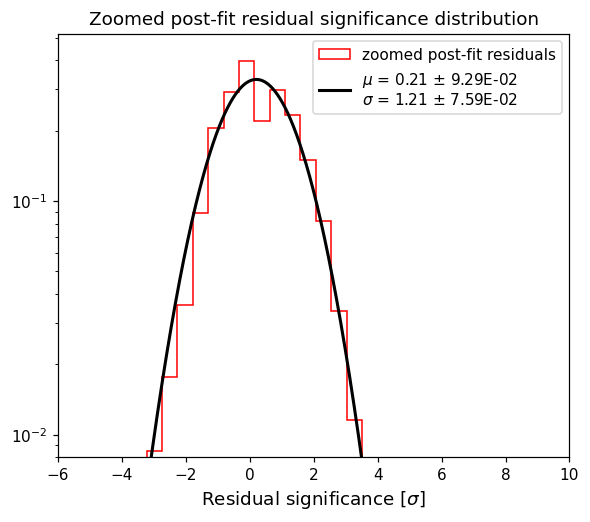

In [ ]:
# Significance distribution of the zoomed post-fit residual excess map.
# Reuse the same zoomed map shown above; do not recompute or use the full-ROI map.

from gammapy.visualization import plot_distribution

fig, ax = plt.subplots(figsize=(6, 5), dpi=110)

plot_distribution(
    significance_roi_4hwc_safe,
    func="norm",
    ax=np.array([ax]),
    kwargs_hist=dict(
        histtype="step",
        color="r",
        bins=16,
        density=True,
        label="zoomed post-fit residuals",
    ),
)

ax.set_yscale("log")
yl = ax.get_ylim()
# Raise the lower y-axis limit for readability; this does not change the fitted distribution.
ax.set_ylim([8e-3, yl[1]])
ax.set_xlim([-6, 10])

ax.set_xlabel(r"Residual significance [$\sigma$]", fontsize=12)
ax.set_title("Zoomed post-fit residual significance distribution", fontsize=12)
ax.legend()
plt.show()


(<WCSAxes: >,
 <Axes: xlabel='Energy [$\\mathrm{TeV}$]', ylabel='Residuals (data - model)'>)

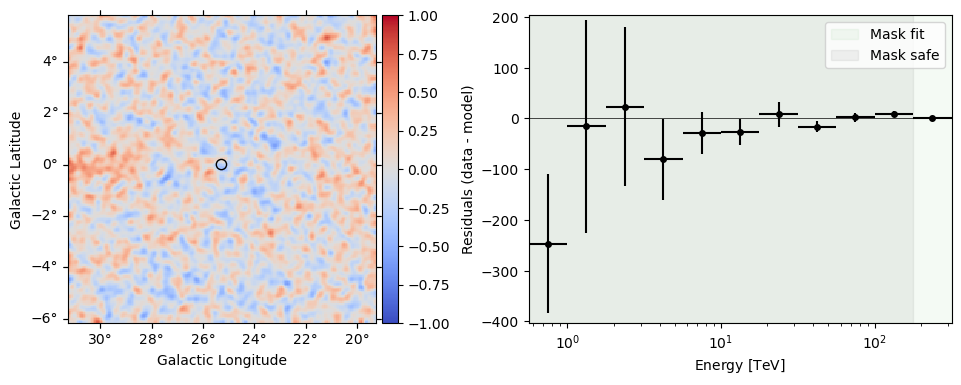

In [ ]:
# Residuals around the main 4HWC source nearest to HESS J1837-069.
# The source names are catalog-style names produced by the seed-list/full-catalog
# position matching step above.

model_J1837_0650 = get_model_by_catalog_name(models, "4HWC J1837-0650")
region = CircleSkyRegion(model_J1837_0650.position, radius=0.2 * u.deg)

datasets[0].plot_residuals(
    kwargs_spatial=dict(method="diff/sqrt(model)", vmin=-1, vmax=1),
    kwargs_spectral=dict(region=region),
)


### Predicted counts map of the outputmodels


In [ ]:
# Predicted signal counts map for datasets with the same geom
npred=Map.from_geom(datasets[0].counts.geom)
for d in datasets :
    #npred += d.npred()
    npred += d.npred_signal() # to not see the background


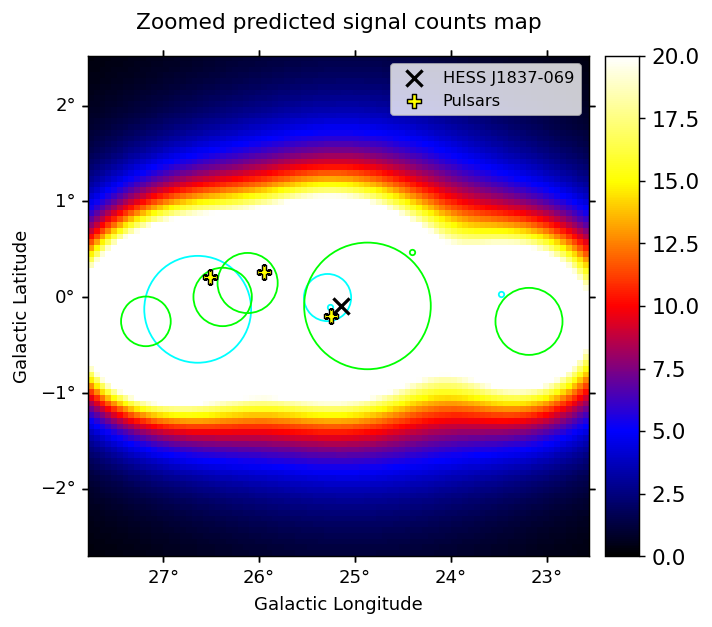

In [ ]:
# plot the 3D map
fig = plt.figure(figsize=(13,5), dpi=130)
npred_sum_zoom = npred.sum_over_axes().cutout(zoom_analysis_center, width=ZOOM_ANALYSIS_WIDTH_LON)
ax = npred_sum_zoom.plot(cmap='ds9b', clim=[0,20])
im = [obj for obj in ax.get_children() if isinstance(obj, mpl.image.AxesImage)][0]

# plot the fitted seed-list sources with catalog-match colors
plot_catalog_matched_seed_overlays(models_hawc_fitted, ax=ax, linestyle="-", kwargs_point=dict(marker="."))

# add target and pulsar markers
add_standard_markers(ax, include_legend=True)
# title and labels
plt.title(r"Zoomed predicted signal counts map", loc="center", fontsize=12, pad=15)
cb_ax = fig.add_axes([0.67, 0.11, 0.02, 0.77]) # (position: profondeur, hauteur; taille: epaisseur, longueur)
cb = fig.colorbar(im, cax=cb_ax, orientation='vertical') # or horizontal with fig.add_axes([.51, .91, .15, 0.04])
cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.tick_params(axis="both", which="major", labelsize=12)
#cb.ax.set_xlabel("Counts", fontsize=12, labelpad=-140, x=2.8); # or labelpad=-30, x=-0.09


### Butterfly plots and SEDs of the ROI sources


In [ ]:
########## Models of the ROI sources ##########
# These lookups use the catalog-style names assigned during the full-catalog
# position-matching step. If a name is absent, the helper prints available names.

model_J1837_0650 = get_model_by_catalog_name(models, "4HWC J1837-0650")
model_J1840_0536 = get_model_by_catalog_name(models, "4HWC J1840-0536")
model_J1834_0828 = get_model_by_catalog_name(models, "4HWC J1834-0828")

########## Energy band and number of flux points ##########
Emin = 1 * u.TeV
Emax = 350 * u.TeV
nbin = 10

########## source names and degrees of freedom ##########
source_name_J1837 = model_J1837_0650.name
source_name_J1840 = model_J1840_0536.name
source_name_J1834 = model_J1834_0828.name
dof = 6

print("ROI source names used in later SED/flux-point cells:")
print("  J1837:", source_name_J1837)
print("  J1840:", source_name_J1840)
print("  J1834:", source_name_J1834)


ROI source names used in later SED/flux-point cells:
  J1837: 4HWC J1837-0650
  J1840: 4HWC J1840-0536
  J1834: 4HWC J1834-0828


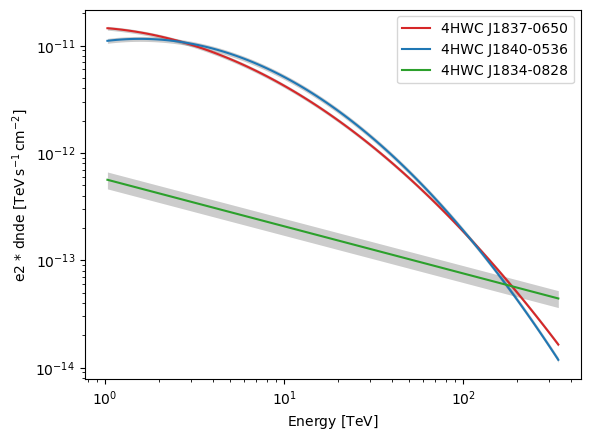

In [ ]:
########## Butterfly plots of the ROI sources ##########

# butterfly function
def plot_spectrum(model, result, label, color):
    spec = model.spectral_model
    energy_range = [Emin, Emax]
    spec.plot(
        energy_bounds=energy_range, energy_power=2, label=label, color=color
    )
    spec.plot_error(energy_bounds=energy_range, energy_power=2, color=color)

# butterfly plot of the ROI sources
plot_spectrum(model_J1837_0650, results, label=source_name_J1837, color="tab:red")
plot_spectrum(model_J1840_0536, results, label=source_name_J1840, color="tab:blue")
plot_spectrum(model_J1834_0828, results, label=source_name_J1834, color="tab:green")
plt.legend()


In [ ]:
########## Flux points computation of the ROI sources ##########

# energy band and number of flux points
energy_edges = MapAxis.from_energy_bounds(Emin,Emax,nbin).edges

# J1837 flux points computation (need to separate the datasets ?)
fpe_J1837 = FluxPointsEstimator(
    energy_edges=energy_edges, source=source_name_J1837,
    selection_optional="all", 
)
flux_points_J1837 = fpe_J1837.run(datasets)

# J1837 flux points table
flux_points_J1837.to_table(sed_type="dnde", formatted=True)

e_ref,e_min,e_max,dnde,dnde_err,dnde_errp,dnde_errn,dnde_ul,dnde_sensitivity,ts,sqrt_ts,npred,npred_excess,stat,stat_null,stat_scan,is_ul,counts,success,norm_scan
TeV,TeV,TeV,1 / (TeV s cm2),1 / (TeV s cm2),1 / (TeV s cm2),1 / (TeV s cm2),1 / (TeV s cm2),1 / (TeV s cm2),,,,,,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64[8],float32[8],float64,float64,float64[11],bool,float64[8],bool,float64[11]
1.334,1.000,1.778,8.609e-12,8.783e-13,8.781e-13,8.787e-13,1.037e-11,4.369e-12,97.028,9.850,46154179.14144485 .. 0.0,8769.907 .. 0.0,-615369919.923,-615369822.895,-615369854.929 .. -615368770.367,False,46187630.0 .. 0.0,True,0.200 .. 5.000
2.371,1.778,3.162,1.834e-12,1.341e-13,1.343e-13,1.340e-13,2.103e-12,6.579e-13,192.976,13.892,26462743.92439086 .. 0.0,3773.9846 .. 0.0,-461260930.356,-461260737.380,-461260814.325 .. -461257515.508,False,26465609.0 .. 0.0,True,0.200 .. 5.000
4.217,3.162,5.623,4.377e-13,2.763e-14,2.771e-14,2.760e-14,4.932e-13,1.299e-13,273.946,16.551,7127615.727756817 .. 0.0,634.7999 .. 0.0,-151769270.595,-151768996.649,-151769105.567 .. -151765535.460,False,7130710.0 .. 0.0,True,0.200 .. 5.000
7.499,5.623,10.000,9.461e-14,5.539e-15,5.568e-15,5.517e-15,1.058e-13,2.387e-14,355.048,18.843,1901380.0082522198 .. 8.990159276493389e-09,140.96326 .. 0.0,-31288509.496,-31288154.448,-31288296.156 .. -31285255.245,False,1900209.0 .. 0.0,True,0.200 .. 5.000
13.335,10.000,17.783,1.846e-14,1.319e-15,1.329e-15,1.308e-15,2.112e-14,5.347e-15,258.696,16.084,747253.6857625463 .. 209.78868373316698,40.82786 .. 6.117827,-5838348.028,-5838089.332,-5838190.860 .. -5836638.998,False,748562.0 .. 217.0,True,0.200 .. 5.000
23.714,17.783,31.623,3.662e-15,3.547e-16,3.594e-16,3.502e-16,4.390e-15,1.298e-15,154.780,12.441,645897.0278050979 .. 2486.147421042441,16.593725 .. 67.54761,-2118083.798,-2117929.018,-2117982.934 .. -2117525.895,False,644939.0 .. 2921.0,True,0.200 .. 5.000
42.170,31.623,56.234,6.142e-16,8.683e-17,8.885e-17,8.483e-17,7.960e-16,3.096e-16,81.596,9.033,144278.92277610136 .. 3525.3210629882374,5.1017604 .. 79.91655,268732.409,268814.005,268787.373 .. 268906.322,False,143978.0 .. 4159.0,True,0.200 .. 5.000
74.989,56.234,100.000,6.417e-17,1.866e-17,1.967e-17,1.767e-17,1.056e-16,6.659e-17,20.913,4.573,86329.13130543107 .. 633.2500476959333,1.2216489 .. 22.906715,245335.813,245356.726,245348.306 .. 245396.539,False,86358.0 .. 842.0,True,0.200 .. 5.000


In [ ]:
print(results_joint.success)
print(results_joint.message)  # if available -- tells you if minuit actually converged cleanly or gave up

True
Optimization terminated successfully, but uncertainties are unreliable.


(-2.0, 2.0)

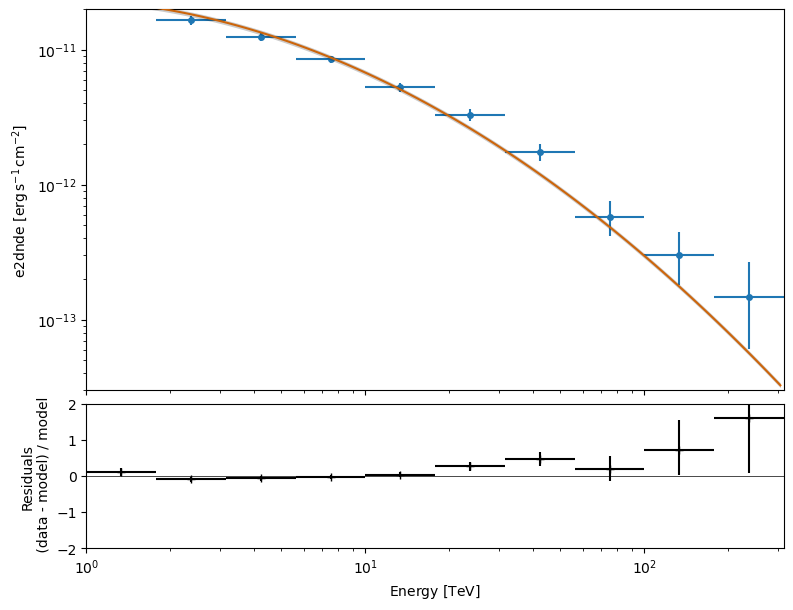

In [ ]:
# J1837 SED
flux_points_J1837.is_ul = flux_points_J1837.ts < 4
flux_points_J1837_dataset = FluxPointsDataset(data=flux_points_J1837, models=model_J1837_0650)

ax1,ax2 = flux_points_J1837_dataset.plot_fit()
ax1.set_ylim(3e-14,2e-11)
ax2.set_ylim(-2.0,2.0)


In [ ]:
# J1840 flux points computation (need to separate the datasets ?)
fpe_J1840 = FluxPointsEstimator(energy_edges=energy_edges, source=source_name_J1840, selection_optional="all")
flux_points_J1840 = fpe_J1840.run(datasets)

# J1840 flux points table
flux_points_J1840.to_table(sed_type="dnde", formatted=True)


e_ref,e_min,e_max,dnde,dnde_err,dnde_errp,dnde_errn,dnde_ul,dnde_sensitivity,ts,sqrt_ts,npred,npred_excess,stat,stat_null,stat_scan,is_ul,counts,success,norm_scan
TeV,TeV,TeV,1 / (TeV s cm2),1 / (TeV s cm2),1 / (TeV s cm2),1 / (TeV s cm2),1 / (TeV s cm2),1 / (TeV s cm2),,,,,,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64[8],float32[8],float64,float64,float64[11],bool,float64[8],bool,float64[11]
1.334,1.000,1.778,7.281e-12,1.183e-12,1.183e-12,1.183e-12,9.636e-12,5.901e-12,37.923,6.158,46154188.97061877 .. 0.0,7523.6284 .. 0.0,-615369919.509,-615369881.586,-615369893.882 .. -615369479.109,False,46187630.0 .. 0.0,True,0.200 .. 5.000
2.371,1.778,3.162,1.485e-12,1.922e-13,1.922e-13,1.921e-13,1.869e-12,9.541e-13,60.369,7.770,26462197.52681958 .. 0.0,2908.631 .. 0.0,-461260934.585,-461260874.216,-461260902.130 .. -461259142.109,False,26465609.0 .. 0.0,True,0.200 .. 5.000
4.217,3.162,5.623,5.246e-13,4.066e-14,4.074e-14,4.061e-14,6.062e-13,1.970e-13,173.840,13.185,7127678.392731479 .. 0.0,700.39996 .. 0.0,-151769269.159,-151769095.319,-151769157.847 .. -151767057.615,False,7130710.0 .. 0.0,True,0.200 .. 5.000
7.499,5.623,10.000,9.978e-14,7.759e-15,7.787e-15,7.735e-15,1.154e-13,3.596e-14,182.772,13.519,1901363.720304133 .. 8.992080763744523e-09,135.94414 .. -1.2901458e-11,-31288512.887,-31288330.114,-31288407.183 .. -31285767.382,False,1900209.0 .. 0.0,True,0.200 .. 5.000
13.335,10.000,17.783,2.348e-14,1.833e-15,1.843e-15,1.823e-15,2.719e-14,7.986e-15,194.892,13.960,747255.6713305424 .. 210.20076034429917,47.794556 .. 8.7826605,-5838348.635,-5838153.742,-5838224.198 .. -5836846.367,False,748562.0 .. 217.0,True,0.200 .. 5.000
23.714,17.783,31.623,4.537e-15,4.700e-16,4.748e-16,4.655e-16,5.498e-15,1.935e-15,119.092,10.913,645897.8638262877 .. 2492.3252331203867,19.549948 .. 92.29158,-2118083.620,-2117964.528,-2118002.801 .. -2117554.463,False,644939.0 .. 2921.0,True,0.200 .. 5.000
42.170,31.623,56.234,8.957e-16,1.198e-16,1.217e-16,1.179e-16,1.143e-15,4.701e-16,76.659,8.755,144280.64011189324 .. 3556.561629715815,7.388577 .. 125.37604,268725.207,268801.866,268783.223 .. 268849.037,False,143978.0 .. 4159.0,True,0.200 .. 5.000
74.989,56.234,100.000,7.249e-17,2.472e-17,2.577e-17,2.368e-17,1.261e-16,1.031e-16,11.941,3.456,86329.22752136186 .. 635.0340452873395,1.4795924 .. 27.639965,245335.780,245347.721,245343.626 .. 245383.761,False,86358.0 .. 842.0,True,0.200 .. 5.000


(-2.0, 2.0)

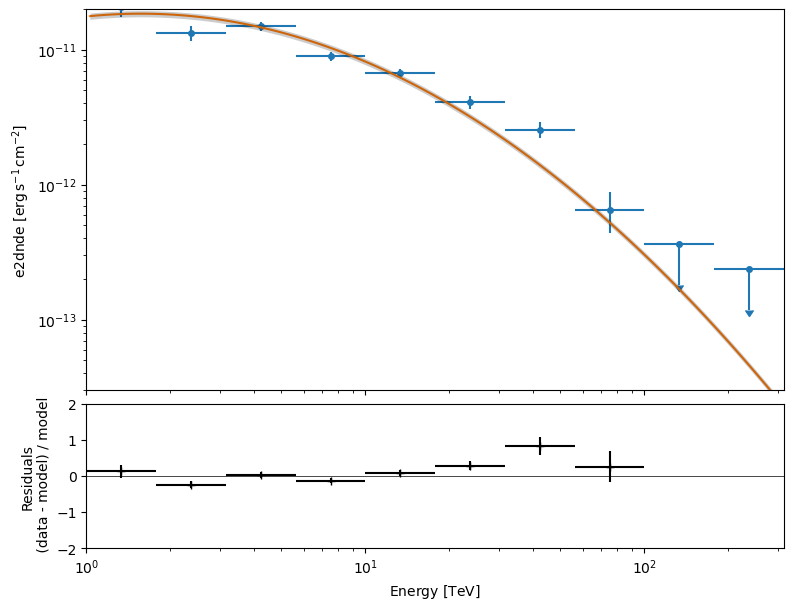

In [ ]:
# J1840 SED
flux_points_J1840.is_ul = flux_points_J1840.ts < 4
flux_points_J1840_dataset = FluxPointsDataset(data=flux_points_J1840, models=model_J1840_0536)

ax1,ax2 = flux_points_J1840_dataset.plot_fit()
ax1.set_ylim(3e-14,2e-11)
ax2.set_ylim(-2.0,2.0)


In [ ]:
# energy band and number of flux points
energy_edges = MapAxis.from_energy_bounds(2 * u.TeV,350 * u.TeV,15).edges

# J1834 flux points computation (need to separate the datasets ?)
fpe_J1834 = FluxPointsEstimator(energy_edges=energy_edges, source=source_name_J1834, selection_optional="all")
flux_points_J1834 = fpe_J1834.run(datasets)

# J1834 flux points table
flux_points_J1834.to_table(sed_type="dnde", formatted=True)


e_ref,e_min,e_max,dnde,dnde_err,dnde_errp,dnde_errn,dnde_ul,dnde_sensitivity,ts,sqrt_ts,npred,npred_excess,stat,stat_null,stat_scan,is_ul,counts,success,norm_scan
TeV,TeV,TeV,1 / (TeV s cm2),1 / (TeV s cm2),1 / (TeV s cm2),1 / (TeV s cm2),1 / (TeV s cm2),1 / (TeV s cm2),,,,,,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64[8],float64[8],float64,float64,float64[11],bool,float64[8],bool,float64[11]
2.240,1.778,2.822,-6.889e-14,7.992e-14,8.068e-14,8.023e-14,9.310e-14,4.029e-13,0.730,-0.854,26462885.12204482 .. 0.0,-124.06512451171875 .. 0.0,-461260931.538,-461260930.808,-461260930.434 .. -461260899.141,True,26465609.0 .. 0.0,True,0.200 .. 5.000
2.987,2.822,3.162,nan,nan,nan,nan,nan,nan,nan,nan,nan .. nan,nan .. nan,nan,-461260930.808,nan .. nan,False,0.0 .. 0.0,False,0.200 .. 5.000
4.217,3.162,5.623,2.227e-14,1.186e-14,1.211e-14,1.189e-14,4.654e-14,5.973e-14,3.512,1.874,7127672.679289287 .. 0.0,32.82193374633789 .. 0.0,-151769269.279,-151769265.767,-151769266.779 .. -151769244.022,True,7130710.0 .. 0.0,True,0.200 .. 5.000
6.677,5.623,7.928,2.875e-15,2.473e-15,2.498e-15,2.552e-15,8.078e-15,1.278e-14,1.290,1.136,1901381.041179655 .. 8.990159276493389e-09,3.1507532596588135 .. 0.0,-31288510.401,-31288509.111,-31288509.947 .. -31288440.564,True,1900209.0 .. 0.0,True,0.200 .. 5.000
8.904,7.928,10.000,nan,nan,nan,nan,nan,nan,nan,nan,nan .. nan,nan .. nan,nan,-461260930.808,nan .. nan,False,0.0 .. 0.0,False,0.200 .. 5.000
12.564,10.000,15.785,1.071e-15,4.691e-16,4.904e-16,4.538e-16,2.089e-15,2.136e-15,6.477,2.545,747252.1018926981 .. 209.55237746477397,1.7799155712127686 .. 0.25717175006866455,-5838347.867,-5838341.390,-5838344.185 .. -5838284.074,False,748562.0 .. 217.0,True,0.200 .. 5.000
16.754,15.785,17.783,nan,nan,nan,nan,nan,nan,nan,nan,nan .. nan,nan .. nan,nan,-461260930.808,nan .. nan,False,0.0 .. 0.0,False,0.200 .. 5.000
23.714,17.783,31.623,3.415e-16,1.088e-16,1.154e-16,1.030e-16,5.849e-16,4.247e-16,18.194,4.265,645893.8897346694 .. 2473.516043795048,1.1201285123825073 .. 5.1038432121276855,-2118079.704,-2118061.510,-2118068.446 .. -2118040.804,False,644939.0 .. 2921.0,True,0.200 .. 5.000


(-2.0, 2.0)

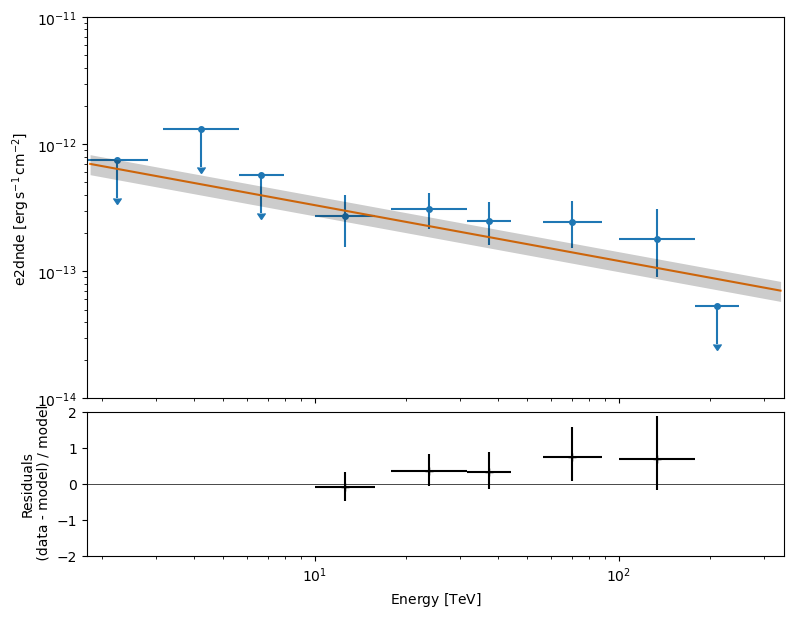

In [ ]:
# J1834 SED
flux_points_J1834.is_ul = flux_points_J1834.ts < 4
flux_points_J1834_dataset = FluxPointsDataset(data=flux_points_J1834, models=model_J1834_0828)

ax1,ax2 = flux_points_J1834_dataset.plot_fit()
ax1.set_ylim(1e-14,1e-11)
ax2.set_ylim(-2.0,2.0)


### Pivot energy, integrated flux and integrated energy flux of the ROI sources


In [ ]:
# Pivot-energy diagnostic.
# A NaN pivot energy is not an error. It can occur when only normalization is free,
# when covariance is insufficient, or when the relative flux error is energy-independent.

import numpy as np

def print_pivot_energy_safe(model, label):
    try:
        pivot = model.spectral_model.pivot_energy
    except Exception as err:
        print(f"Pivot energy of {label}: unavailable ({type(err).__name__}: {err})")
        return

    try:
        pivot_value = pivot.to_value("TeV")
    except Exception:
        pivot_value = np.nan

    if np.isfinite(pivot_value):
        print(f"Pivot energy of {label}: {pivot:.3g}")
    else:
        print(
            f"Pivot energy of {label}: not defined "
            "(likely because the relative flux error is energy-independent)."
        )

print_pivot_energy_safe(model_J1837_0650, source_name_J1837)
print_pivot_energy_safe(model_J1840_0536, source_name_J1840)
print_pivot_energy_safe(model_J1834_0828, source_name_J1834)


Pivot energy of 4HWC J1837-0650: not defined (likely because the relative flux error is energy-independent).
Pivot energy of 4HWC J1840-0536: not defined (likely because the relative flux error is energy-independent).
Pivot energy of 4HWC J1834-0828: not defined (likely because the relative flux error is energy-independent).


In [ ]:
# source integrated flux and its error computation over the whole energy band
print(f"Integrated flux of the {source_name_J1837} is", model_J1837_0650.spectral_model.integral_error(Emin, Emax))
print(f"Integrated flux of the {source_name_J1840} is", model_J1840_0536.spectral_model.integral_error(Emin, Emax))
print(f"Integrated flux of the {source_name_J1834} is", model_J1834_0828.spectral_model.integral_error(Emin, Emax))


Integrated flux of the 4HWC J1837-0650 is [1.07355925e-11 4.43663272e-13 4.39168994e-13] 1 / (s cm2)
Integrated flux of the 4HWC J1840-0536 is [9.75126120e-12 5.18420728e-13 5.13169162e-13] 1 / (s cm2)
Integrated flux of the 4HWC J1834-0828 is [3.96564697e-13 7.14614583e-14 7.07375586e-14] 1 / (s cm2)


In [ ]:
# source integrated energy flux and its error computation over the whole energy band
print(f"Integrated energy flux of the {source_name_J1837} is", model_J1837_0650.spectral_model.energy_flux_error(Emin, Emax, epsilon=0.0001))
print(f"Integrated energy flux of the {source_name_J1840} is", model_J1840_0536.spectral_model.energy_flux_error(Emin, Emax, epsilon=0.0001))
print(f"Integrated energy flux of the {source_name_J1834} is", model_J1834_0828.spectral_model.energy_flux_error(Emin, Emax, epsilon=0.0001))


Integrated energy flux of the 4HWC J1837-0650 is [2.60196704e-11 1.07529902e-12 1.06440632e-12] TeV / (s cm2)
Integrated energy flux of the 4HWC J1840-0536 is [2.61126335e-11 1.38826458e-12 1.37420155e-12] TeV / (s cm2)
Integrated energy flux of the 4HWC J1834-0828 is [1.20064834e-12 2.16358345e-13 2.14166650e-13] TeV / (s cm2)


### TS of the ROI sources


In [ ]:
########## Freeze source-shape parameters and define TS helpers ##########
# This replaces the old source-by-source blocks and is robust to different
# Gammapy spatial models, e.g. GaussianSpatialModel vs GeneralizedGaussianSpatialModel.

def freeze_if_present(model, parameter_names, model_part="spatial_model"):
    """Freeze named parameters only if they exist on the requested model part."""
    part = getattr(model, model_part)
    for par_name in parameter_names:
        if hasattr(part, par_name):
            getattr(part, par_name).frozen = True
        else:
            print(f"{model.name}: {model_part}.{par_name} not present; skipping.")


def freeze_source_shape_parameters(model):
    """Freeze position, morphology, and spectral-shape parameters; leave normalisation free."""
    freeze_if_present(model, ["lon_0", "lat_0"], "spatial_model")
    freeze_if_present(model, ["sigma", "r_0", "eta", "e", "phi"], "spatial_model")
    freeze_if_present(model, ["alpha", "beta", "index", "lambda_", "reference"], "spectral_model")


def free_norm_like_parameters(model):
    """Free only amplitude / normalisation-like parameters."""
    norm_names = {"amplitude", "K", "norm", "norm1", "norm2", "prefactor"}
    for par in model.parameters:
        if par.name in norm_names:
            par.frozen = False


roi_source_names = [source_name_J1837, source_name_J1840, source_name_J1834]

for src_name in roi_source_names:
    model = datasets.models[src_name]
    freeze_source_shape_parameters(model)
    print(model.name)
    print(model.spatial_model)
    print(model.spectral_model)


4HWC J1837-0650: spatial_model.sigma not present; skipping.
4HWC J1837-0650: spectral_model.index not present; skipping.
4HWC J1837-0650: spectral_model.lambda_ not present; skipping.
4HWC J1837-0650
GeneralizedGaussianSpatialModel

type  name    value    unit   error      min        max    frozen link prior
---- ----- ----------- ---- --------- ---------- --------- ------ ---- -----
     lon_0  2.5286e+01  deg 0.000e+00  2.497e+01 2.557e+01   True           
     lat_0 -1.8904e-03  deg 0.000e+00 -3.360e-01 2.640e-01   True           
       r_0  2.4597e-01  deg 0.000e+00  6.000e-02 7.500e-01   True           
       eta  9.9024e-01      0.000e+00  1.000e-01 1.000e+00   True           
         e  0.0000e+00      0.000e+00  0.000e+00 9.500e-01   True           
       phi  0.0000e+00  deg 0.000e+00        nan       nan   True           
LogParabolaSpectralModel

type    name     value         unit      ...    max    frozen link prior
---- --------- ---------- -------------- ... -------

In [ ]:
########## TS and Significance of the ROI sources ##########
# Computes a profiled TS when the null model has free normalisation parameters.
# If no free parameters remain, it falls back to a fixed-background TS.

def compute_source_ts(datasets, models, source_name, dof=1, fit_opts=None):
    """Compute TS for one source by removing it and fitting/evaluating the null model."""
    datasets.models = models

    # Alternative model: source included
    stat_with_source = datasets.stat_sum()
    print(f"\n===== {source_name} =====")
    print(f"Fit statistic with {source_name}: {stat_with_source}")

    # Null model: source removed
    datasets_copied = datasets.copy()
    models_copied = models.copy()

    if source_name in models_copied.names:
        models_copied.remove(source_name)
    else:
        print("Available model names:", models_copied.names)
        raise ValueError(f"{source_name} not found in models_copied.")

    datasets_copied.models = models_copied

    # Let remaining source/background normalisations adjust if possible.
    for model in models_copied:
        free_norm_like_parameters(model)

    free_pars = datasets_copied.models.parameters.free_parameters
    print("Free parameters in null model:", free_pars.names)

    results_copied = None
    if len(free_pars.names) > 0:
        minuit_opts = {"strategy": 1}
        fit = Fit(store_trace=True, optimize_opts={"print_level": 1, "tol": 0.1})
        fit.backend = "minuit"
        fit.optimize_opts = minuit_opts if fit_opts is None else fit_opts
        results_copied = fit.run(datasets_copied)
        print(results_copied)
    else:
        print("No free parameters in the null model; computing fixed-background TS.")

    stat_without_source = datasets_copied.stat_sum()
    print(f"Fit statistic without {source_name}: {stat_without_source}")

    ts_source = stat_without_source - stat_with_source
    if ts_source < 0 and abs(ts_source) < 1e-6:
        ts_source = 0.0

    sig_source = ts_to_sigma(ts=ts_source, df=dof)
    print(f"TS of {source_name}: {ts_source}")
    print(f"Significance of {source_name}: {sig_source}")

    return {
        "source": source_name,
        "stat_with_source": stat_with_source,
        "stat_without_source": stat_without_source,
        "ts": ts_source,
        "sigma": sig_source,
        "fit_result_null": results_copied,
        "models_null": models_copied,
    }


ts_results = {}
for src_name in roi_source_names:
    ts_results[src_name] = compute_source_ts(datasets, models, src_name, dof=dof)



===== 4HWC J1837-0650 =====
Fit statistic with 4HWC J1837-0650: -1489846915.1597817
Free parameters in null model: ['amplitude', 'amplitude', 'amplitude', 'amplitude', 'amplitude', 'amplitude', 'amplitude', 'amplitude', 'amplitude']
OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 997
	total stat : -1489846275.21

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.

Fit statistic without 4HWC J1837-0650: -1489846275.2059562
TS of 4HWC J1837-0650: 639.9538254737854
Significance of 4HWC J1837-0650: 24.72618162184496

===== 4HWC J1840-0536 =====
Fit statistic with 4HWC J1840-0536: -1489846915.1597817
Free parameters in null model: ['amplitude', 'amplitude', 'amplitude', 'amplitude', 'amplitude', 'amplitude', 'amplitude', 'amplitude', 'amplitude']
OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	me

### Post-fit residual likelihood $\sqrt{\mathrm{TS}}$ map

This diagnostic recomputes the likelihood $\sqrt{\mathrm{TS}}$ map after the zoom-region/fitted 4HWC/HAWC source model has been attached to the datasets and fitted. It is **not** obtained by subtracting the pre-fit TS map, because TS is a likelihood-ratio quantity and is not additive. A remaining bright peak indicates that an additional test source at that location would still improve the likelihood after the fitted model has been accounted for.


In [ ]:
%%time
# Post-fit residual likelihood sqrt(TS) map.
#
# Important:
# This is not a subtraction of the pre-fit TS map. TS is a likelihood-ratio
# quantity, so we recompute the likelihood sqrt(TS) scan after the fitted
# source model is attached to the datasets.

import copy

datasets_for_postfit_ts = copy.deepcopy(datasets)

# ------------------------------------------------------------
# Repair mask_fit and sanitize maps before TSMapEstimator
# ------------------------------------------------------------
for idx, dataset in enumerate(datasets_for_postfit_ts):
    print(f"\nDataset {idx}: {dataset.name}")

    if dataset.mask_fit is None or dataset.mask_fit.data.sum() == 0:
        print("  resetting mask_fit = mask_safe")
        dataset.mask_fit = dataset.mask_safe.copy()
    else:
        dataset.mask_fit.data &= dataset.mask_safe.data

    print("  mask_safe valid pixels:", dataset.mask_safe.data.sum())
    print("  mask_fit valid pixels:", dataset.mask_fit.data.sum())

    # Replace non-finite values in standard maps.
    for attr in ["counts", "background", "exposure"]:
        m = getattr(dataset, attr, None)
        if m is not None:
            bad = ~np.isfinite(m.data)
            if bad.any():
                print(f"  replacing {bad.sum()} non-finite values in {attr}")
                m.data[bad] = 0.0

    # Keep fit mask only where background is finite and positive.
    if getattr(dataset, "background", None) is not None:
        valid_bkg = np.isfinite(dataset.background.data) & (dataset.background.data > 0)
        if dataset.mask_fit.data.shape == valid_bkg.squeeze().shape:
            dataset.mask_fit.data &= valid_bkg.squeeze()
        else:
            dataset.mask_fit.data &= np.any(valid_bkg, axis=0)

    print("  final mask_fit valid pixels:", dataset.mask_fit.data.sum())

    if dataset.mask_fit.data.sum() == 0:
        raise ValueError(f"{dataset.name}: mask_fit is all False after repair.")

# Recompute the likelihood sqrt(TS) map after the fitted source model is included.
sqrt_ts_roi_postfit, _, result_roi_postfit_ts = make_maps_joint(
    datasets_for_postfit_ts,
    radius=0.1 * u.deg,
    sum_over_energy_groups=False,
    n_jobs=6,
    method="joint",
)

summarize_map_finiteness(
    sqrt_ts_roi_postfit,
    label="Post-fit residual likelihood sqrt(TS) map",
    warn_fraction=0.50,
)

sqrt_ts_roi_postfit_safe = finite_map_copy(sqrt_ts_roi_postfit)



Dataset 0: DatasetGalacticPlaneBin3Ch103to1360NN_HESS J1837-069
  mask_safe valid pixels: 390326
  mask_fit valid pixels: 390326
  final mask_fit valid pixels: 390326

Dataset 1: DatasetGalacticPlaneBin4Ch103to1360NN_HESS J1837-069
  mask_safe valid pixels: 359925
  mask_fit valid pixels: 359925
  final mask_fit valid pixels: 359925

Dataset 2: DatasetGalacticPlaneBin5Ch103to1360NN_HESS J1837-069
  mask_safe valid pixels: 371093
  mask_fit valid pixels: 371093
  final mask_fit valid pixels: 371093

Dataset 3: DatasetGalacticPlaneBin6Ch103to1360NN_HESS J1837-069
  mask_safe valid pixels: 350326
  mask_fit valid pixels: 350326
  final mask_fit valid pixels: 350326

Dataset 4: DatasetGalacticPlaneBin7Ch103to1360NN_HESS J1837-069
  mask_safe valid pixels: 320169
  mask_fit valid pixels: 320169
  final mask_fit valid pixels: 319925

Dataset 5: DatasetGalacticPlaneBin8Ch103to1360NN_HESS J1837-069
  mask_safe valid pixels: 310326
  mask_fit valid pixels: 310326
  final mask_fit valid pixels:

/home/a/Asu.Uenver/miniconda3/envs/gammapy-2.0/lib/python3.12/site-packages/scipy/signal/_signaltools.py:568: RuntimeWarning: invalid value encountered in multiply
  ret = ifft(sp1 * sp2, fshape, axes=axes)
/home/a/Asu.Uenver/miniconda3/envs/gammapy-2.0/lib/python3.12/site-packages/gammapy/maps/wcs/ndmap.py:952: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  return scipy.signal.convolve(image, kernel, method=method, mode=mode)
/home/a/Asu.Uenver/miniconda3/envs/gammapy-2.0/lib/python3.12/site-packages/scipy/signal/_signaltools.py:568: RuntimeWarning: invalid value encountered in multiply
  ret = ifft(sp1 * sp2, fshape, axes=axes)
/home/a/Asu.Uenver/miniconda3/envs/gammapy-2.0/lib/python3.12/site-packages/gammapy/maps/wcs/ndmap.py:952: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  return scipy.signal.convolve(i

Post-fit residual likelihood sqrt(TS) map:
  Shape: (1, 200, 200)
  Finite pixels: 40000 / 40000 (1.000)
  NaN pixels: 0
  Inf pixels: 0
  Finite min/max: -1.4335118356112329 22.9882756400932
CPU times: user 56.1 s, sys: 5.37 s, total: 1min 1s
Wall time: 5min 19s


In [ ]:
# Inspect post-fit residual likelihood sqrt(TS) map output robustly.
# This works whether make_maps_joint returns a WcsNDMap or a Maps-like object.

def inspect_map_output(obj, label="output"):
    if hasattr(obj, "keys"):
        for key in obj.keys():
            inspect_map_output(obj[key], label=str(key))
        return

    data = obj.data
    finite = np.isfinite(data)

    print(f"\nMap: {label}")
    print("  type:", type(obj))
    print("  shape:", data.shape)
    print("  finite pixels:", finite.sum())
    print("  NaN pixels:", np.isnan(data).sum())
    print("  inf pixels:", np.isinf(data).sum())

    if finite.any():
        print("  min finite:", data[finite].min())
        print("  max finite:", data[finite].max())
    else:
        print("  No finite pixels found.")


inspect_map_output(sqrt_ts_roi_postfit, "sqrt_ts_roi_postfit")



Map: sqrt_ts_roi_postfit
  type: <class 'gammapy.maps.wcs.ndmap.WcsNDMap'>
  shape: (1, 200, 200)
  finite pixels: 40000
  NaN pixels: 0
  inf pixels: 0
  min finite: -1.4335118356112329
  max finite: 22.9882756400932


WcsGeom

	axes       : ['lon', 'lat', 'energy']
	shape      : (np.int64(87), np.int64(87), 1)
	ndim       : 3
	frame      : galactic
	projection : CAR
	center     : 25.2 deg, -0.1 deg
	width      : 5.2 deg x 5.2 deg
	wcs ref    : 120.0 deg, 0.0 deg

Pixel size: [0d03m36s 0d03m36s]


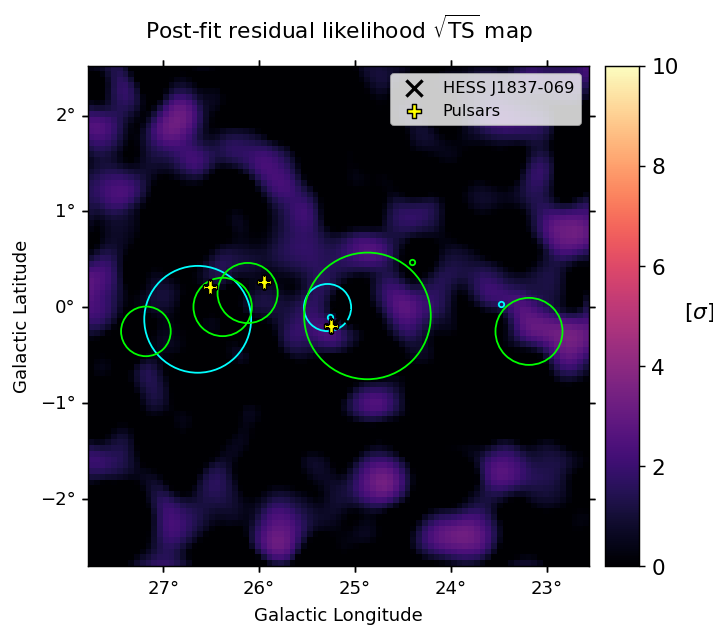

In [ ]:
# Plot the zoomed post-fit residual likelihood sqrt(TS) map.

fig = plt.figure(figsize=(13, 5), dpi=130)

tmp_postfit_ts = sqrt_ts_roi_postfit_safe.cutout(
    zoom_analysis_center,
    width=ZOOM_ANALYSIS_WIDTH_LON,
)

print(tmp_postfit_ts.geom)
print("Pixel size:", tmp_postfit_ts.geom.pixel_scales)

ax = tmp_postfit_ts.plot(
    clim=[0, 10],
    cmap="magma",
    interpolation="nearest",
)

im = [
    obj for obj in ax.get_children()
    if isinstance(obj, mpl.image.AxesImage)
][0]

# Plot the zoom-region 4HWC/HAWC sources that are actually included in the fitted model.
# cyan = matched/renamed to the full 4HWC catalog; lime = unmatched selected seed.
plot_catalog_matched_seed_overlays(
    models_hawc_fitted,
    ax=ax,
    linestyle="-",
    kwargs_point=dict(marker="."),
)

# Residual contours.
ax.contour(
    tmp_postfit_ts.data[0],
    levels=[4, 5, 8, 10],
    colors="white",
    zorder=0,
    linewidths=0.5,
)

add_standard_markers(ax, include_legend=True)

plt.title(
    r"Post-fit residual likelihood $\sqrt{\mathrm{TS}}$ map",
    loc="center",
    fontsize=12,
    pad=15,
)

cb_ax = fig.add_axes([0.67, 0.11, 0.02, 0.77])
cb = fig.colorbar(
    im,
    cax=cb_ax,
    orientation="vertical",
    ticks=[0, 2, 4, 6, 8, 10],
)
cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.tick_params(axis="both", which="major", labelsize=12)

# The plotted quantity is sqrt(TS), so it is shown in approximate sigma units.
cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-140, x=2.8);


### Pre-fit versus post-fit likelihood $\sqrt{\mathrm{TS}}$ comparison

The comparison below checks whether the zoom-region/fitted 4HWC/HAWC source model reduces the strongest source-like likelihood residuals. This is not a subtraction of TS maps; it compares the maxima of two independently computed likelihood scans.


In [ ]:
# Compare the pre-fit and post-fit likelihood sqrt(TS) maps in the same zoomed analysis region.

sqrt_ts_roi_prefit_zoom = finite_map_copy(sqrt_ts_roi_prefit).cutout(
    zoom_analysis_center,
    width=ZOOM_ANALYSIS_WIDTH_LON,
)
sqrt_ts_roi_postfit_zoom = finite_map_copy(sqrt_ts_roi_postfit).cutout(
    zoom_analysis_center,
    width=ZOOM_ANALYSIS_WIDTH_LON,
)

def finite_minmax(map_obj):
    data = map_obj.data
    finite = np.isfinite(data)
    if not finite.any():
        return np.nan, np.nan
    return np.nanmin(data[finite]), np.nanmax(data[finite])

pre_min, pre_max = finite_minmax(sqrt_ts_roi_prefit_zoom)
post_min, post_max = finite_minmax(sqrt_ts_roi_postfit_zoom)

print("Likelihood sqrt(TS) comparison in zoomed analysis region")
print("-------------------------------------------------------")
print(f"Pre-fit likelihood sqrt(TS) max:       {pre_max:.3f}")
print(f"Post-fit residual sqrt(TS) max:        {post_max:.3f}")

if np.isfinite(pre_max) and np.isfinite(post_max):
    print(f"Reduction in max sqrt(TS):             {pre_max - post_max:.3f}")
    print(f"Post/pre max ratio:                    {post_max / pre_max:.3f}")


Likelihood sqrt(TS) comparison in zoomed analysis region
-------------------------------------------------------
Pre-fit likelihood sqrt(TS) max:       24.798
Post-fit residual sqrt(TS) max:        3.454
Reduction in max sqrt(TS):             21.344
Post/pre max ratio:                    0.139


## **Added: HAWC + Fermi-LAT broadband SED overlay**

Appended at the very end so nothing above it is disturbed. Plots the original, unmodified HAWC-only flux points (`flux_points_J1837`, computed earlier in the untouched part of this notebook) together with the Fermi-LAT flux points built above (`flux_points_fermi`, from fermipy's own SED) on one GeV-TeV axis -- same idea as the "Joint HAWC + Fermi-LAT SED" figure in the MapDataset-based notebook, just built from fermipy's finished SED instead of a re-derived one.

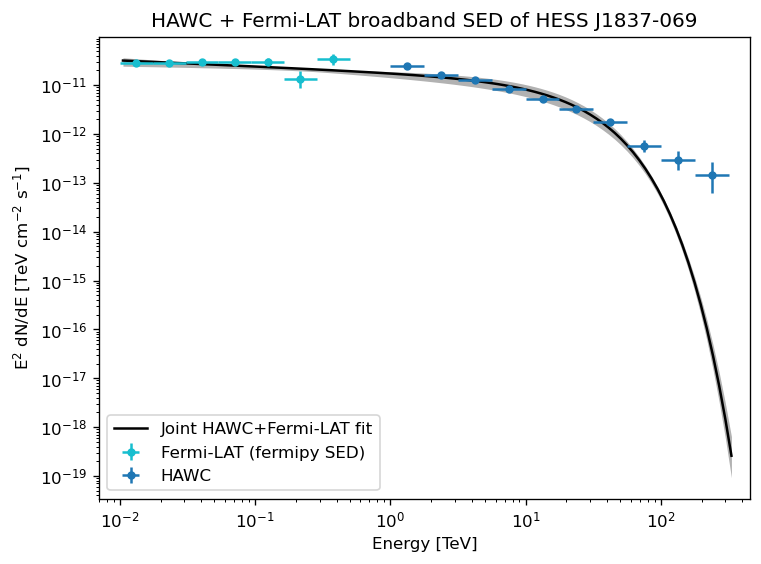

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=120)

# Full broadband range spanning both instruments, computed explicitly so
# neither instrument's points get silently cropped by the other's internal
# plot range (Fermi runs GeV-scale, HAWC runs TeV-scale).
fermi_e_min = float(np.min(gammapy_sed_table["e_min"])) * u.TeV
fermi_e_max = float(np.max(gammapy_sed_table["e_max"])) * u.TeV
E_broadband_min = min(fermi_e_min, Emin)
E_broadband_max = max(fermi_e_max, Emax)

# Butterfly: the joint HAWC+Fermi-LAT best-fit model if you ran that section
# (RUN_JOINT_FIT = True), falling back to the HAWC-only fit otherwise.
if "models_joint" in globals():
    target_model_for_butterfly = models_joint["4HWC J1837-0650"]
    butterfly_label = "Joint HAWC+Fermi-LAT fit"
else:
    target_model_for_butterfly = models["4HWC J1837-0650"]
    butterfly_label = "HAWC-only fit (joint fit not run)"
    print("models_joint not found -- showing the HAWC-only butterfly instead. "
          "Set RUN_JOINT_FIT = True and rerun that section for the real joint butterfly.")

target_model_for_butterfly.spectral_model.plot(
    ax=ax, energy_bounds=[E_broadband_min, E_broadband_max],
    sed_type="e2dnde", label=butterfly_label, color="black",
)
target_model_for_butterfly.spectral_model.plot_error(
    ax=ax, energy_bounds=[E_broadband_min, E_broadband_max],
    sed_type="e2dnde", color="black", alpha=0.3,
)

flux_points_fermi.plot(ax=ax, sed_type="e2dnde", label="Fermi-LAT (fermipy SED)", color="tab:cyan")
flux_points_J1837.plot(ax=ax, sed_type="e2dnde", label="HAWC")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(E_broadband_min.to_value("TeV") * 0.7, E_broadband_max.to_value("TeV") * 1.3)
ax.set_xlabel("Energy [TeV]")
ax.set_ylabel(r"E$^2$ dN/dE [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_title("HAWC + Fermi-LAT broadband SED of HESS J1837-069")
ax.legend()

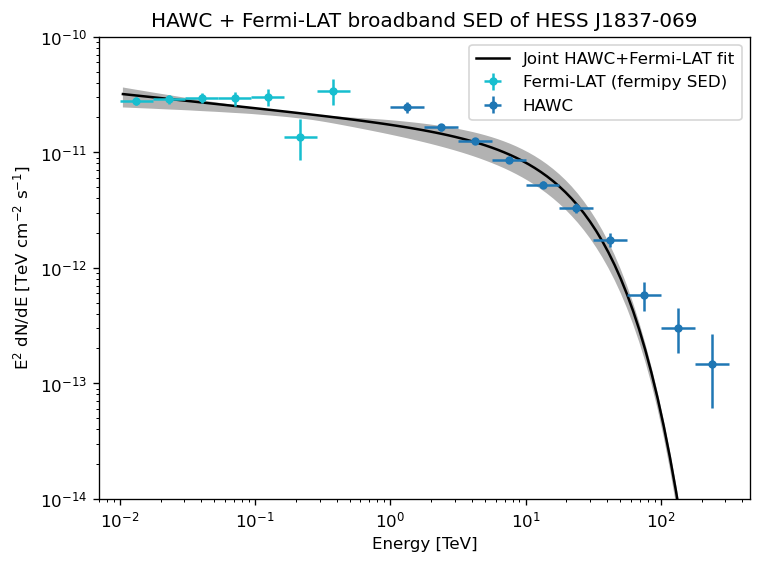

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=120)

# Full broadband range spanning both instruments, computed explicitly so
# neither instrument's points get silently cropped by the other's internal
# plot range (Fermi runs GeV-scale, HAWC runs TeV-scale).
fermi_e_min = float(np.min(gammapy_sed_table["e_min"])) * u.TeV
fermi_e_max = float(np.max(gammapy_sed_table["e_max"])) * u.TeV
E_broadband_min = min(fermi_e_min, Emin)
E_broadband_max = max(fermi_e_max, Emax)

# Butterfly: the joint HAWC+Fermi-LAT best-fit model if you ran that section
# (RUN_JOINT_FIT = True), falling back to the HAWC-only fit otherwise.
if "models_joint" in globals():
    target_model_for_butterfly = models_joint["4HWC J1837-0650"]
    butterfly_label = "Joint HAWC+Fermi-LAT fit"
else:
    target_model_for_butterfly = models["4HWC J1837-0650"]
    butterfly_label = "HAWC-only fit (joint fit not run)"
    print("models_joint not found -- showing the HAWC-only butterfly instead. "
          "Set RUN_JOINT_FIT = True and rerun that section for the real joint butterfly.")

target_model_for_butterfly.spectral_model.plot(
    ax=ax, energy_bounds=[E_broadband_min, E_broadband_max],
    sed_type="e2dnde", label=butterfly_label, color="black",
)
target_model_for_butterfly.spectral_model.plot_error(
    ax=ax, energy_bounds=[E_broadband_min, E_broadband_max],
    sed_type="e2dnde", color="black", alpha=0.3,
)

flux_points_fermi.plot(ax=ax, sed_type="e2dnde", label="Fermi-LAT (fermipy SED)", color="tab:cyan")
flux_points_J1837.plot(ax=ax, sed_type="e2dnde", label="HAWC")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(E_broadband_min.to_value("TeV") * 0.7, E_broadband_max.to_value("TeV") * 1.3)
ax.set_ylim(1e-14, 1e-10)
ax.set_xlabel("Energy [TeV]")
ax.set_ylabel(r"E$^2$ dN/dE [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_title("HAWC + Fermi-LAT broadband SED of HESS J1837-069")
ax.legend()

In [ ]:
for d in datasets_joint:
    print(d.name, d.stat_sum())

DatasetGalacticPlaneBin3Ch103to1360NN_HESS J1837-069 -1150991239.2858768
DatasetGalacticPlaneBin4Ch103to1360NN_HESS J1837-069 -285689380.8863872
DatasetGalacticPlaneBin5Ch103to1360NN_HESS J1837-069 -49104747.333870746
DatasetGalacticPlaneBin6Ch103to1360NN_HESS J1837-069 -4622520.262911249
DatasetGalacticPlaneBin7Ch103to1360NN_HESS J1837-069 125343.99358141651
DatasetGalacticPlaneBin8Ch103to1360NN_HESS J1837-069 233275.8417861252
DatasetGalacticPlaneBin9Ch103to1360NN_HESS J1837-069 141062.10315467027
DatasetGalacticPlaneBin10Ch103to1360NN_HESS J1837-069 61311.477170276274
fermi-lat 10.757316339870181


In [ ]:
# ==========================================================================
# Combined HAWC + Fermi-LAT significance map -- adds the two independently
# computed TS maps pixel by pixel (valid under Wilks' theorem for independent
# datasets: TS = -2*Delta(lnL), and log-likelihoods from independent
# instruments simply sum). This is an approximation relative to a true joint
# spatial re-fit (see the MapDataset-based notebook for that) -- it combines
# two independently-optimized significances rather than re-optimizing one
# shared model simultaneously across both instruments' real data.
#
# Everything is labeled -- HAWC 4HWC/matched-seed sources, the Fermi-LAT ROI
# center, and the combined-significance contour levels themselves.
# ==========================================================================
from matplotlib.lines import Line2D

if "fermi_ts_reproj" not in globals():
    print(
        "fermi_ts_reproj isn't defined -- run the Fermi TS contour-overlay "
        "cell (right after the HAWC significance map) first, and make sure "
        "FERMI_TS_MAP_FITS points at a real file."
    )
else:
    # tmp_prefit_ts stores *signed* sqrt(TS) (sign marks excess vs. deficit),
    # so square it back to TS while preserving sign rather than assuming it's
    # non-negative.
    ts_hawc = np.sign(tmp_prefit_ts.data) * tmp_prefit_ts.data**2
    # Fermi's TS map is already TS (not sqrt); clip at 0 defensively in case
    # any pixels have a negative TS from a failed per-pixel fit.
    ts_fermi = np.clip(fermi_ts_reproj.data, 0, None)

    ts_combined = ts_hawc + ts_fermi
    sqrt_ts_combined_data = np.sign(ts_combined) * np.sqrt(np.abs(ts_combined))

    sqrt_ts_combined = Map.from_geom(tmp_prefit_ts.geom, data=sqrt_ts_combined_data)

    fig = plt.figure(figsize=(13, 5), dpi=130)
    ax = sqrt_ts_combined.plot(clim=[0, 20], cmap="magma", interpolation="nearest")

    im = [obj for obj in ax.get_children() if isinstance(obj, mpl.image.AxesImage)][0]

    # --- HAWC 4HWC/matched-seed source markers (cyan = matched to full
    # catalog, lime = unmatched selected seed) -----------------------------
    plot_catalog_matched_seed_overlays(
        models_hawc_fitted,
        ax=ax,
        linestyle="-",
        kwargs_point=dict(marker="."),
    )

    # --- Combined significance contours (labeled with sigma) --------------
    combined_sigma_levels = [3, 5, 10, 15, 20]
    cs_combined = ax.contour(
        sqrt_ts_combined_data[0],
        levels=combined_sigma_levels,
        colors="white",
        linewidths=0.8,
        zorder=0,
    )
    ax.clabel(cs_combined, inline=True, fontsize=6, fmt=r"%d$\sigma$", colors="white")

    # --- Standard source markers (pulsar/SNR/etc, HAWC's usual overlay) ---
    add_standard_markers(ax, include_legend=False)

    # --- Fermi-LAT ROI center marker ---------------------------------------
    add_sky_marker(
        ax, hessJ1837_pos, label="Fermi-LAT ROI center",
        style="peak", color="cyan", marker="D", s=70,
    )

    # --- Colorbar ------------------------------------------------------------
    cb_ax = fig.add_axes([0.67, 0.11, 0.02, 0.77])
    cb = fig.colorbar(im, cax=cb_ax, orientation="vertical", ticks=[0, 5, 10, 15, 20])
    cb.ax.xaxis.set_ticks_position("top")
    cb.ax.xaxis.set_label_position("top")
    cb.ax.tick_params(axis="both", which="major", labelsize=12)
    cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-140, x=2.8)

    # --- Manual legend combining everything ----------------------------------
    legend_handles = [
        Line2D([0], [0], color="white", lw=1.2, label="Combined HAWC+Fermi-LAT $\\sqrt{TS}$ contours"),
        Line2D([0], [0], marker="D", color="cyan", linestyle="None", markersize=7, label="Fermi-LAT ROI center"),
        Line2D([0], [0], marker=".", color="cyan", linestyle="-", label="4HWC-matched HAWC source"),
        Line2D([0], [0], marker=".", color="lime", linestyle="-", label="Unmatched HAWC seed"),
    ]
    ax.legend(handles=legend_handles, loc="upper right", fontsize=7, framealpha=0.8)

    plt.title(
        r"Combined HAWC + Fermi-LAT $\sqrt{\mathrm{TS}}$ significance (TS-summed, approximate)",
        loc="center", fontsize=12, pad=15,
    )

    print("Combined sqrt(TS) min/max:", np.nanmin(sqrt_ts_combined_data), np.nanmax(sqrt_ts_combined_data))

fermi_ts_reproj isn't defined -- run the Fermi TS contour-overlay cell (right after the HAWC significance map) first, and make sure FERMI_TS_MAP_FITS points at a real file.


In [ ]:
# ==========================================================================
# Combined HAWC + Fermi-LAT significance map -- WITH Fermi-LAT's own TS
# contours overlaid separately (in addition to the combined/TS-summed
# contours). This is the same background as the cell above; it just adds a
# second, distinct contour layer (dashed cyan) so you can see how much of
# the combined significance is being driven by Fermi-LAT alone.
# ==========================================================================
from matplotlib.lines import Line2D

if "fermi_ts_reproj" not in globals():
    print(
        "fermi_ts_reproj isn't defined -- run the Fermi TS contour-overlay "
        "cell (right after the HAWC significance map) first, and make sure "
        "FERMI_TS_MAP_FITS points at a real file."
    )
else:
    # Same combined-TS construction as the cell above.
    ts_hawc = np.sign(tmp_prefit_ts.data) * tmp_prefit_ts.data**2
    ts_fermi = np.clip(fermi_ts_reproj.data, 0, None)

    ts_combined = ts_hawc + ts_fermi
    sqrt_ts_combined_data = np.sign(ts_combined) * np.sqrt(np.abs(ts_combined))

    sqrt_ts_combined = Map.from_geom(tmp_prefit_ts.geom, data=sqrt_ts_combined_data)

    fig = plt.figure(figsize=(13, 5), dpi=130)
    ax = sqrt_ts_combined.plot(clim=[0, 20], cmap="magma", interpolation="nearest")

    im = [obj for obj in ax.get_children() if isinstance(obj, mpl.image.AxesImage)][0]

    # --- HAWC 4HWC/matched-seed source markers -----------------------------
    plot_catalog_matched_seed_overlays(
        models_hawc_fitted,
        ax=ax,
        linestyle="-",
        kwargs_point=dict(marker="."),
    )

    # --- Combined significance contours (white, labeled with sigma) -------
    combined_sigma_levels = [3, 5, 10, 15, 20]
    cs_combined = ax.contour(
        sqrt_ts_combined_data[0],
        levels=combined_sigma_levels,
        colors="white",
        linewidths=0.8,
        zorder=0,
    )
    ax.clabel(cs_combined, inline=True, fontsize=6, fmt=r"%d$\sigma$", colors="white")

    # --- Fermi-LAT-only TS contours, overlaid separately (dashed cyan) ----
    # This is Fermi's significance alone (not summed with HAWC), reprojected
    # onto the same geometry -- distinct from the combined contours above.
    fermi_sigma_levels = [3, 4, 5]
    fermi_ts_levels = [sigma_to_ts(s, df=1) for s in fermi_sigma_levels]
    cs_fermi = ax.contour(
        ts_fermi,
        levels=fermi_ts_levels,
        colors="cyan",
        linewidths=1.2,
        linestyles="--",
        zorder=1,
    )
    fermi_labels = {lvl: f"{s}$\\sigma$" for lvl, s in zip(fermi_ts_levels, fermi_sigma_levels)}
    ax.clabel(cs_fermi, inline=True, fontsize=7, fmt=fermi_labels, colors="cyan")

    # --- Standard source markers -------------------------------------------
    add_standard_markers(ax, include_legend=False)

    # --- Fermi-LAT ROI center marker ---------------------------------------
    add_sky_marker(
        ax, hessJ1837_pos, label="Fermi-LAT ROI center",
        style="peak", color="cyan", marker="D", s=70,
    )

    # --- Colorbar ------------------------------------------------------------
    cb_ax = fig.add_axes([0.67, 0.11, 0.02, 0.77])
    cb = fig.colorbar(im, cax=cb_ax, orientation="vertical", ticks=[0, 5, 10, 15, 20])
    cb.ax.xaxis.set_ticks_position("top")
    cb.ax.xaxis.set_label_position("top")
    cb.ax.tick_params(axis="both", which="major", labelsize=12)
    cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-140, x=2.8)

    # --- Manual legend --------------------------------------------------------
    legend_handles = [
        Line2D([0], [0], color="white", lw=1.2, label="Combined HAWC+Fermi-LAT $\\sqrt{TS}$ contours"),
        Line2D([0], [0], color="cyan", lw=1.2, linestyle="--", label="Fermi-LAT-only TS contours"),
        Line2D([0], [0], marker="D", color="cyan", linestyle="None", markersize=7, label="Fermi-LAT ROI center"),
        Line2D([0], [0], marker=".", color="cyan", linestyle="-", label="4HWC-matched HAWC source"),
        Line2D([0], [0], marker=".", color="lime", linestyle="-", label="Unmatched HAWC seed"),
    ]
    ax.legend(handles=legend_handles, loc="upper right", fontsize=7, framealpha=0.8)

    plt.title(
        r"Combined HAWC + Fermi-LAT $\sqrt{\mathrm{TS}}$ significance, with Fermi-LAT-only contours",
        loc="center", fontsize=12, pad=15,
    )

    print("Combined sqrt(TS) min/max:", np.nanmin(sqrt_ts_combined_data), np.nanmax(sqrt_ts_combined_data))

fermi_ts_reproj isn't defined -- run the Fermi TS contour-overlay cell (right after the HAWC significance map) first, and make sure FERMI_TS_MAP_FITS points at a real file.


In [ ]:
# ==========================================================================
# Final combined figure: HAWC post-fit significance map + Fermi-LAT TS
# contours overlaid. Everything is labeled -- HAWC 4HWC/matched-seed
# sources, the Fermi-LAT ROI center, and the Fermi contour levels
# themselves (via clabel). This is a visual cross-check only -- the
# contours are Fermi-LAT's own independently-computed TS map, not part
# of any joint fit.
# ==========================================================================
from matplotlib.lines import Line2D
if "FERMI_TS_MAP_FITS" not in globals() or FERMI_TS_MAP_FITS is None or not FERMI_TS_MAP_FITS.exists():
    print(
        "FERMI_TS_MAP_FITS isn't set or doesn't exist -- skipping the combined "
        "HAWC+Fermi map. Set FERMI_TS_MAP_FITS in the path-config cell to your "
        "fermipy TS map FITS file first."
    )
else:
    from gammapy.maps import Map

    # Reproject Fermi's TS map onto the same (post-fit, zoomed) geometry as
    # the HAWC map below -- fresh here so this cell is self-contained even
    # if the earlier pre-fit contour-overlay cell wasn't run.
    fermi_ts_map_raw = Map.read(str(FERMI_TS_MAP_FITS))
    fermi_ts_reproj_final = fermi_ts_map_raw.interp_to_geom(tmp_postfit_ts.geom.to_image())

    fig = plt.figure(figsize=(13, 5), dpi=130)

    ax = tmp_postfit_ts.plot(clim=[0, 10], cmap="magma", interpolation="nearest")

    im = [obj for obj in ax.get_children() if isinstance(obj, mpl.image.AxesImage)][0]

    # --- HAWC 4HWC/matched-seed source markers (cyan = matched to full
    # catalog, lime = unmatched selected seed) -----------------------------
    plot_catalog_matched_seed_overlays(
        models_hawc_fitted,
        ax=ax,
        linestyle="-",
        kwargs_point=dict(marker="."),
    )

    # --- HAWC residual contours (white, from the post-fit likelihood) -----
    hawc_contour_levels = [4, 5, 8, 10]
    cs_hawc = ax.contour(
        tmp_postfit_ts.data[0],
        levels=hawc_contour_levels,
        colors="white",
        zorder=0,
        linewidths=0.5,
    )
    ax.clabel(cs_hawc, inline=True, fontsize=6, fmt=r"%d$\sigma$", colors="white")

    # --- Fermi-LAT TS contours (cyan, labeled with sigma) ------------------
    fermi_sigma_levels = [3, 4, 5]
    fermi_ts_levels = [sigma_to_ts(s, df=1) for s in fermi_sigma_levels]
    cs_fermi = ax.contour(
        fermi_ts_reproj_final.data,
        levels=fermi_ts_levels,
        colors="cyan",
        linewidths=1.2,
        zorder=1,
    )
    fermi_labels = {lvl: f"{s}$\\sigma$" for lvl, s in zip(fermi_ts_levels, fermi_sigma_levels)}
    ax.clabel(cs_fermi, inline=True, fontsize=7, fmt=fermi_labels, colors="cyan")

    # --- Standard source markers (pulsar/SNR/etc, HAWC's usual overlay) ---
    add_standard_markers(ax, include_legend=False)

    # --- Fermi-LAT ROI center marker ---------------------------------------
    add_sky_marker(
        ax, hessJ1837_pos, label="Fermi-LAT ROI center",
        style="peak", color="cyan", marker="D", s=70,
    )

    # --- Colorbar ------------------------------------------------------------
    cb_ax = fig.add_axes([0.67, 0.11, 0.02, 0.77])
    cb = fig.colorbar(im, cax=cb_ax, orientation="vertical", ticks=[0, 2, 4, 6, 8, 10])
    cb.ax.xaxis.set_ticks_position("top")
    cb.ax.xaxis.set_label_position("top")
    cb.ax.tick_params(axis="both", which="major", labelsize=12)
    cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-140, x=2.8)

    # --- Manual legend combining HAWC markers + Fermi contours + ROI marker -
    legend_handles = [
        Line2D([0], [0], color="white", lw=1.5, label="HAWC post-fit residual $\\sqrt{TS}$ contours"),
        Line2D([0], [0], color="cyan", lw=1.5, label="Fermi-LAT TS contours (fermipy)"),
        Line2D([0], [0], marker="D", color="cyan", linestyle="None", markersize=7, label="Fermi-LAT ROI center"),
        Line2D([0], [0], marker=".", color="cyan", linestyle="-", label="4HWC-matched HAWC source"),
        Line2D([0], [0], marker=".", color="lime", linestyle="-", label="Unmatched HAWC seed"),
    ]
    ax.legend(handles=legend_handles, loc="upper right", fontsize=7, framealpha=0.8)

    plt.title(
        r"HAWC post-fit $\sqrt{\mathrm{TS}}$ (post-fit residual) with Fermi-LAT TS contours overlaid",
        loc="center", fontsize=12, pad=15,
    )

    plt.show()

FERMI_TS_MAP_FITS isn't set or doesn't exist -- skipping the combined HAWC+Fermi map. Set FERMI_TS_MAP_FITS in the path-config cell to your fermipy TS map FITS file first.


In [ ]:
if FERMI_TS_MAP_FITS is None or not FERMI_TS_MAP_FITS.exists():
    print(f"FERMI_TS_MAP_FITS not found at {FERMI_TS_MAP_FITS} -- cannot plot.")
else:
    fermi_ts_map_raw = Map.read(str(FERMI_TS_MAP_FITS))
    if fermi_ts_map_raw.data.ndim > 2:
        fermi_ts_map_raw = fermi_ts_map_raw.sum_over_axes()

    fermi_ts_zoom = fermi_ts_map_raw.cutout(zoom_analysis_center, width=ZOOM_ANALYSIS_WIDTH_LON)
    ts_peak_fermi = np.nanmax(fermi_ts_zoom.data)
    sigma_peak_fermi = ts_to_sigma(ts_peak_fermi, df=1)

    fig = plt.figure(figsize=(13, 5), dpi=130)
    ax = fermi_ts_zoom.plot(cmap="magma", interpolation="nearest")
    im = [obj for obj in ax.get_children() if isinstance(obj, mpl.image.AxesImage)][0]

    plot_catalog_matched_seed_overlays(models_hawc_fitted, ax=ax, linestyle="-", kwargs_point=dict(marker="."))
    add_standard_markers(ax, include_legend=False)
    add_sky_marker(ax, hessJ1837_pos, label="Fermi-LAT ROI center", style="peak", color="cyan", marker="D", s=70)

    ax.text(
        0.02, 0.98,
        f"Peak TS = {ts_peak_fermi:.1f}  (~{sigma_peak_fermi:.2f}$\\sigma$)",
        transform=ax.transAxes, color="white", fontsize=11, va="top",
        bbox=dict(facecolor="black", alpha=0.5, boxstyle="round"),
    )

    cb_ax = fig.add_axes([0.67, 0.11, 0.02, 0.77])
    cb = fig.colorbar(im, cax=cb_ax, orientation="vertical")
    cb.ax.xaxis.set_ticks_position("top")
    cb.ax.xaxis.set_label_position("top")
    cb.ax.set_xlabel("TS", fontsize=12, labelpad=-140, x=2.8)

    plt.title(r"Fermi-LAT-only TS map (fermipy)", loc="center", fontsize=12, pad=15)
    plt.show()

FERMI_TS_MAP_FITS not found at /project/ls-gruen/users/asu.uenver/fermi/output_hess1837_0651/roi_analysis/hess1837_postdelete_ts_pointsource_powerlaw_2.00_tsmap_0651.fits -- cannot plot.


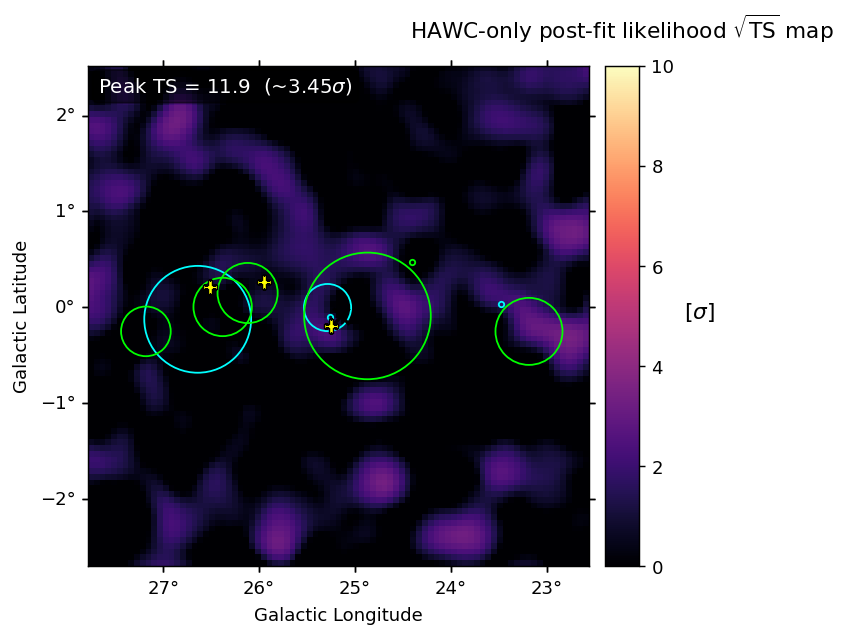

In [ ]:
ts_hawc_zoom_data = np.sign(tmp_postfit_ts.data) * tmp_postfit_ts.data**2
ts_peak_hawc = np.nanmax(ts_hawc_zoom_data)
sigma_peak_hawc = ts_to_sigma(ts_peak_hawc, df=1)

fig = plt.figure(figsize=(13, 5), dpi=130)
ax = tmp_postfit_ts.plot(clim=[0, 10], cmap="magma", interpolation="nearest")
im = [obj for obj in ax.get_children() if isinstance(obj, mpl.image.AxesImage)][0]

plot_catalog_matched_seed_overlays(models_hawc_fitted, ax=ax, linestyle="-", kwargs_point=dict(marker="."))
add_standard_markers(ax, include_legend=False)

ax.text(
    0.02, 0.98,
    f"Peak TS = {ts_peak_hawc:.1f}  (~{sigma_peak_hawc:.2f}$\\sigma$)",
    transform=ax.transAxes, color="white", fontsize=11, va="top",
    bbox=dict(facecolor="black", alpha=0.5, boxstyle="round"),
)

cb_ax = fig.add_axes([0.67, 0.11, 0.02, 0.77])
cb = fig.colorbar(im, cax=cb_ax, orientation="vertical", ticks=[0, 2, 4, 6, 8, 10])
cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-140, x=2.8)

plt.title(r"HAWC-only post-fit likelihood $\sqrt{\mathrm{TS}}$ map", loc="center", fontsize=12, pad=15)
plt.show()

In [ ]:
if FERMI_TS_MAP_FITS is None or not FERMI_TS_MAP_FITS.exists():
    print(f"FERMI_TS_MAP_FITS not found at {FERMI_TS_MAP_FITS} -- cannot plot.")
else:
    fermi_ts_map_raw = Map.read(str(FERMI_TS_MAP_FITS))
    if fermi_ts_map_raw.data.ndim > 2:
        fermi_ts_map_raw = fermi_ts_map_raw.sum_over_axes()

    fermi_ts_zoom = fermi_ts_map_raw.cutout(zoom_analysis_center, width=ZOOM_ANALYSIS_WIDTH_LON)
    ts_peak_fermi = np.nanmax(fermi_ts_zoom.data)
    sigma_peak_fermi = ts_to_sigma(ts_peak_fermi, df=1)

    fig = plt.figure(figsize=(13, 5), dpi=130)
    ax = fermi_ts_zoom.plot(cmap="magma", interpolation="nearest")
    im = [obj for obj in ax.get_children() if isinstance(obj, mpl.image.AxesImage)][0]

    plot_catalog_matched_seed_overlays(models_hawc_fitted, ax=ax, linestyle="-", kwargs_point=dict(marker="."))
    add_standard_markers(ax, include_legend=False)
    add_sky_marker(ax, hessJ1837_pos, label="Fermi-LAT ROI center", style="peak", color="cyan", marker="D", s=70)

    ax.text(
        0.02, 0.98,
        f"Peak TS = {ts_peak_fermi:.1f}  (~{sigma_peak_fermi:.2f}$\\sigma$)",
        transform=ax.transAxes, color="white", fontsize=11, va="top",
        bbox=dict(facecolor="black", alpha=0.5, boxstyle="round"),
    )

    cb_ax = fig.add_axes([0.67, 0.11, 0.02, 0.77])
    cb = fig.colorbar(im, cax=cb_ax, orientation="vertical")
    cb.ax.xaxis.set_ticks_position("top")
    cb.ax.xaxis.set_label_position("top")
    cb.ax.set_xlabel("TS", fontsize=12, labelpad=-140, x=2.8)

    plt.title(r"Fermi-LAT-only TS map (fermipy)", loc="center", fontsize=12, pad=15)
    plt.show()

FERMI_TS_MAP_FITS not found at /project/ls-gruen/users/asu.uenver/fermi/output_hess1837_0651/roi_analysis/hess1837_postdelete_ts_pointsource_powerlaw_2.00_tsmap_0651.fits -- cannot plot.


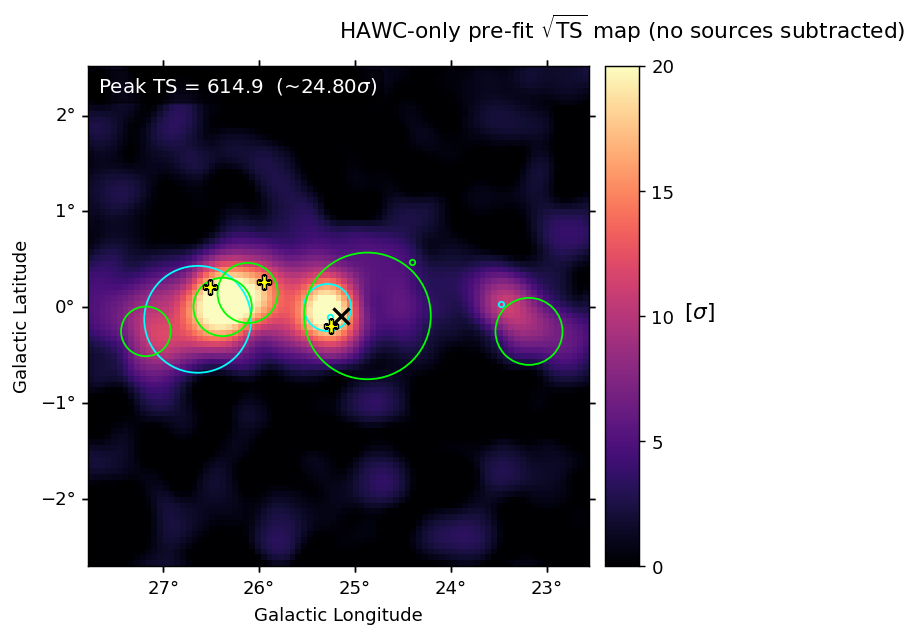

In [ ]:
ts_prefit_data = np.sign(tmp_prefit_ts.data) * tmp_prefit_ts.data**2
ts_peak_prefit = np.nanmax(ts_prefit_data)
sigma_peak_prefit = ts_to_sigma(ts_peak_prefit, df=1)

fig = plt.figure(figsize=(13, 5), dpi=130)
ax = tmp_prefit_ts.plot(clim=[0, 20], cmap="magma", interpolation="nearest")
im = [obj for obj in ax.get_children() if isinstance(obj, mpl.image.AxesImage)][0]

plot_catalog_matched_seed_overlays(models_4hwc_zoom_region, ax=ax, linestyle="-", kwargs_point=dict(marker="."))
add_standard_markers(ax, include_legend=False)

ax.text(
    0.02, 0.98, f"Peak TS = {ts_peak_prefit:.1f}  (~{sigma_peak_prefit:.2f}$\\sigma$)",
    transform=ax.transAxes, color="white", fontsize=11, va="top",
    bbox=dict(facecolor="black", alpha=0.5, boxstyle="round"),
)

cb_ax = fig.add_axes([0.67, 0.11, 0.02, 0.77])
cb = fig.colorbar(im, cax=cb_ax, orientation="vertical", ticks=[0, 5, 10, 15, 20])
cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-140, x=2.8)

plt.title(r"HAWC-only pre-fit $\sqrt{\mathrm{TS}}$ map (no sources subtracted)", loc="center", fontsize=12, pad=15)
plt.show()

/home/a/Asu.Uenver/miniconda3/envs/gammapy-2.0/lib/python3.12/site-packages/scipy/signal/_signaltools.py:568: RuntimeWarning: invalid value encountered in multiply
  ret = ifft(sp1 * sp2, fshape, axes=axes)
/home/a/Asu.Uenver/miniconda3/envs/gammapy-2.0/lib/python3.12/site-packages/gammapy/maps/wcs/ndmap.py:952: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  return scipy.signal.convolve(image, kernel, method=method, mode=mode)
/home/a/Asu.Uenver/miniconda3/envs/gammapy-2.0/lib/python3.12/site-packages/scipy/signal/_signaltools.py:568: RuntimeWarning: invalid value encountered in multiply
  ret = ifft(sp1 * sp2, fshape, axes=axes)
/home/a/Asu.Uenver/miniconda3/envs/gammapy-2.0/lib/python3.12/site-packages/gammapy/maps/wcs/ndmap.py:952: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  return scipy.signal.convolve(i

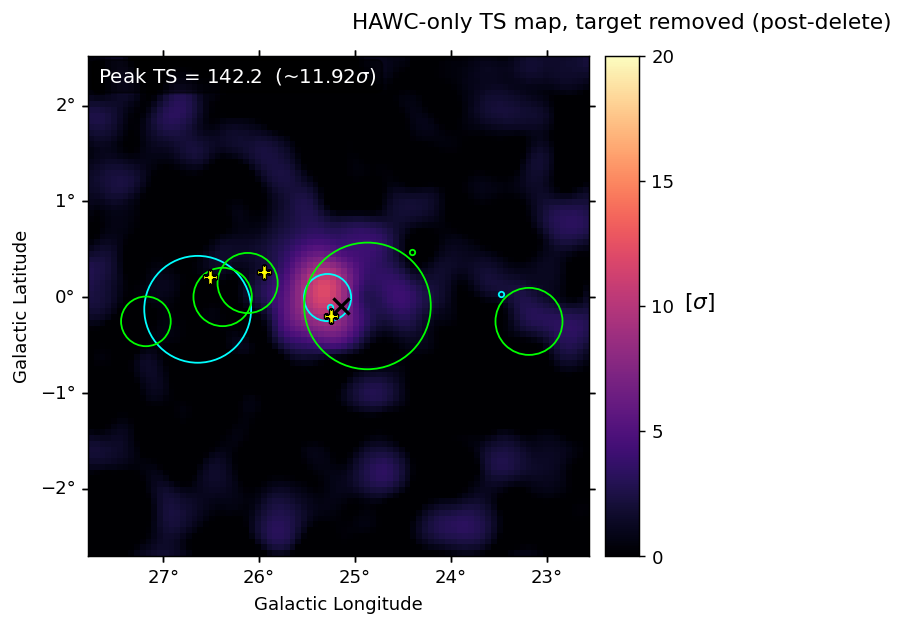

In [ ]:
import copy

target_model_name = "4HWC J1837-0650"  # explicit, doesn't depend on target_name's current value

models_postdelete = copy.deepcopy(models)
models_postdelete.remove(target_model_name)
for m in models_postdelete:
    for par in m.parameters:
        par.frozen = True

datasets_postdelete = copy.deepcopy(datasets)
for dataset in datasets_postdelete:
    if dataset.mask_fit is None or dataset.mask_fit.data.sum() == 0:
        dataset.mask_fit = dataset.mask_safe.copy()
    else:
        dataset.mask_fit.data &= dataset.mask_safe.data
    for attr in ["counts", "background", "exposure"]:
        m = getattr(dataset, attr, None)
        if m is not None:
            bad = ~np.isfinite(m.data)
            if bad.any():
                m.data[bad] = 0.0
    if getattr(dataset, "background", None) is not None:
        valid_bkg = np.isfinite(dataset.background.data) & (dataset.background.data > 0)
        if dataset.mask_fit.data.shape == valid_bkg.squeeze().shape:
            dataset.mask_fit.data &= valid_bkg.squeeze()
        else:
            dataset.mask_fit.data &= np.any(valid_bkg, axis=0)

datasets_postdelete.models = models_postdelete

sqrt_ts_hawc_postdelete, _, _ = make_maps_joint(
    datasets_postdelete, radius=0.1 * u.deg,
    sum_over_energy_groups=False, n_jobs=6, method="joint",
)
sqrt_ts_hawc_postdelete_safe = finite_map_copy(sqrt_ts_hawc_postdelete)

tmp_postdelete_ts = sqrt_ts_hawc_postdelete_safe.cutout(zoom_analysis_center, width=ZOOM_ANALYSIS_WIDTH_LON)
ts_postdelete_data = np.sign(tmp_postdelete_ts.data) * tmp_postdelete_ts.data**2
ts_peak_postdelete = np.nanmax(ts_postdelete_data)
sigma_peak_postdelete = ts_to_sigma(ts_peak_postdelete, df=1)

fig = plt.figure(figsize=(13, 5), dpi=130)
ax = tmp_postdelete_ts.plot(clim=[0, 20], cmap="magma", interpolation="nearest")
im = [obj for obj in ax.get_children() if isinstance(obj, mpl.image.AxesImage)][0]

plot_catalog_matched_seed_overlays(models_hawc_fitted, ax=ax, linestyle="-", kwargs_point=dict(marker="."))
add_standard_markers(ax, include_legend=False)

ax.text(
    0.02, 0.98, f"Peak TS = {ts_peak_postdelete:.1f}  (~{sigma_peak_postdelete:.2f}$\\sigma$)",
    transform=ax.transAxes, color="white", fontsize=11, va="top",
    bbox=dict(facecolor="black", alpha=0.5, boxstyle="round"),
)

cb_ax = fig.add_axes([0.67, 0.11, 0.02, 0.77])
cb = fig.colorbar(im, cax=cb_ax, orientation="vertical", ticks=[0, 5, 10, 15, 20])
cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-140, x=2.8)

plt.title(r"HAWC-only TS map, target removed (post-delete)", loc="center", fontsize=12, pad=15)
plt.show()

In [ ]:
# ============================================================================
# Save every SED product from this notebook -- flux points, best-fit
# spectral models (butterflies), and their fit parameters -- as plain FITS
# files under OUTPUT_DIR/sed_fits_export/. Safe to re-run: every step is
# wrapped so a variable that doesn't exist yet (e.g. models_joint, if you
# didn't run the joint-fit section) is skipped rather than raising.
# ============================================================================

from astropy.table import Table
from astropy.io import fits
from gammapy.maps import MapAxis
import astropy.units as u
import numpy as np

SED_OUTPUT_DIR = OUTPUT_DIR / "sed_fits_export"
SED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

saved_files = []  # (label, path) manifest printed at the end


def _save_fluxpoints(fp, label):
    path = SED_OUTPUT_DIR / f"{label}_fluxpoints.fits"
    try:
        fp.write(path, sed_type="dnde", format="gadf-sed", overwrite=True)
        saved_files.append((f"{label} flux points", path))
    except Exception as exc:
        print(f"[skip] {label} flux points: {exc!r}")


def _sample_model_curve_table(spectral_model, energy_min, energy_max, n_points=100):
    """Sample a spectral model + its error band on a log energy grid, using
    the SAME recipe (evaluate_error, default random_state=42) that
    SpectralModel.plot_error() uses internally -- so this table reproduces
    this notebook's own butterfly bands exactly, rather than approximating
    them with a different method."""
    energy_axis = MapAxis.from_energy_bounds(energy_min, energy_max, n_points, name="energy")
    energy = energy_axis.center
    dnde, dnde_errn, dnde_errp = spectral_model.evaluate_error(energy)
    e2 = energy**2
    t = Table()
    t["e_ref"] = energy
    t["dnde"] = dnde
    t["dnde_errn"] = dnde_errn
    t["dnde_errp"] = dnde_errp
    t["e2dnde"] = (e2 * dnde).to("TeV cm-2 s-1")
    t["e2dnde_errn"] = (e2 * dnde_errn).to("TeV cm-2 s-1")
    t["e2dnde_errp"] = (e2 * dnde_errp).to("TeV cm-2 s-1")
    return t


def _save_model(model, label, energy_min, energy_max, n_points=100):
    try:
        spec = model.spectral_model if hasattr(model, "spectral_model") else model
        curve_table = _sample_model_curve_table(spec, energy_min, energy_max, n_points=n_points)
        curve_table.meta["MODEL"] = str(getattr(model, "name", label))[:60]
        curve_table.meta["SPECTAG"] = str(getattr(spec, "tag", ["", ""])[0])
        curve_path = SED_OUTPUT_DIR / f"{label}_curve.fits"
        curve_table.write(curve_path, format="fits", overwrite=True)
        saved_files.append((f"{label} best-fit curve (butterfly)", curve_path))

        params_table = model.parameters.to_table()
        params_path = SED_OUTPUT_DIR / f"{label}_params.fits"
        params_table.write(params_path, format="fits", overwrite=True)
        saved_files.append((f"{label} fit parameters", params_path))
        return curve_table
    except Exception as exc:
        print(f"[skip] {label} model curve/params: {exc!r}")
        return None


# ------------------------------------------------------------------------
# 1. Flux points -- Fermi-LAT + each HAWC ROI source, wherever they exist.
# ------------------------------------------------------------------------
_fluxpoint_vars = {
    "fermi": "flux_points_fermi",
    "hawc_J1837": "flux_points_J1837",
    "hawc_J1840": "flux_points_J1840",
    "hawc_J1834": "flux_points_J1834",
}
for label, varname in _fluxpoint_vars.items():
    if varname in globals():
        _save_fluxpoints(globals()[varname], label)

# ------------------------------------------------------------------------
# 2. Best-fit spectral models (butterflies) + their fit parameters.
#    Both the HAWC-only fit and, if you ran that section, the joint
#    HAWC+Fermi-LAT fit for the main target -- this second one is the
#    "Fermi+HAWC (HESS J1837-069) fit" you specifically want to keep.
# ------------------------------------------------------------------------
_e_min_default = Emin if "Emin" in globals() else 1 * u.TeV
_e_max_default = Emax if "Emax" in globals() else 350 * u.TeV
_e_broadband_min = E_broadband_min if "E_broadband_min" in globals() else _e_min_default
_e_broadband_max = E_broadband_max if "E_broadband_max" in globals() else _e_max_default

joint_curve_table = None
if "model_J1837_0650" in globals():
    _save_model(model_J1837_0650, "J1837_hawc_only", _e_min_default, _e_max_default)
if "models_joint" in globals():
    try:
        target_joint = models_joint["4HWC J1837-0650"]
        joint_curve_table = _save_model(
            target_joint, "J1837_joint_hawc_fermi", _e_broadband_min, _e_broadband_max
        )
    except Exception as exc:
        print(f"[skip] joint HAWC+Fermi-LAT model: {exc!r}")
if "model_J1840_0536" in globals():
    _save_model(model_J1840_0536, "J1840_hawc_only", _e_min_default, _e_max_default)
if "model_J1834_0828" in globals():
    _save_model(model_J1834_0828, "J1834_hawc_only", _e_min_default, _e_max_default)

# ------------------------------------------------------------------------
# 3. One combined multi-extension FITS reproducing the broadband SED
#    overlay plots above (Fermi flux points + HAWC flux points + the
#    joint-or-HAWC-only butterfly), in a single file.
# ------------------------------------------------------------------------
hdus = [fits.PrimaryHDU()]
if "flux_points_fermi" in globals():
    t = flux_points_fermi.to_table(sed_type="dnde", formatted=False)
    hdu = fits.table_to_hdu(t)
    hdu.name = "FERMI_FLUXPOINTS"
    hdus.append(hdu)
if "flux_points_J1837" in globals():
    t = flux_points_J1837.to_table(sed_type="dnde", formatted=False)
    hdu = fits.table_to_hdu(t)
    hdu.name = "HAWC_J1837_FLUXPOINTS"
    hdus.append(hdu)

_master_curve = joint_curve_table
_master_curve_label = "JOINT_HAWC_FERMI_BUTTERFLY"
if _master_curve is None and "model_J1837_0650" in globals():
    _master_curve = _sample_model_curve_table(
        model_J1837_0650.spectral_model, _e_min_default, _e_max_default
    )
    _master_curve_label = "HAWC_ONLY_BUTTERFLY"
if _master_curve is not None:
    hdu = fits.table_to_hdu(_master_curve)
    hdu.name = _master_curve_label
    hdus.append(hdu)

if len(hdus) > 1:
    master_path = SED_OUTPUT_DIR / "HESSJ1837_broadband_SED_master.fits"
    fits.HDUList(hdus).writeto(master_path, overwrite=True)
    saved_files.append(("Combined broadband SED (all-in-one)", master_path))

# ------------------------------------------------------------------------
print(f"\nSaved {len(saved_files)} FITS file(s) to {SED_OUTPUT_DIR}:")
for label, path in saved_files:
    print(f"  {label:45s} -> {path.name}")
print(
    "\nOpen these with FluxPoints.read(...) / plain astropy.table.Table.read(...) "
    "(flux points) or Table.read(...) (curves/params), or load the whole set at "
    "once in the companion SED_fits_viewer.ipynb notebook."
)


Saved 13 FITS file(s) to /project/ls-gruen/users/asu.uenver/outputs/sed_fits_export:
  fermi flux points                             -> fermi_fluxpoints.fits
  hawc_J1837 flux points                        -> hawc_J1837_fluxpoints.fits
  hawc_J1840 flux points                        -> hawc_J1840_fluxpoints.fits
  hawc_J1834 flux points                        -> hawc_J1834_fluxpoints.fits
  J1837_hawc_only best-fit curve (butterfly)    -> J1837_hawc_only_curve.fits
  J1837_hawc_only fit parameters                -> J1837_hawc_only_params.fits
  J1837_joint_hawc_fermi best-fit curve (butterfly) -> J1837_joint_hawc_fermi_curve.fits
  J1837_joint_hawc_fermi fit parameters         -> J1837_joint_hawc_fermi_params.fits
  J1840_hawc_only best-fit curve (butterfly)    -> J1840_hawc_only_curve.fits
  J1840_hawc_only fit parameters                -> J1840_hawc_only_params.fits
  J1834_hawc_only best-fit curve (butterfly)    -> J1834_hawc_only_curve.fits
  J1834_hawc_only fit parameters        

In [ ]:
# ============================================================================
# Save every significance/TS/counts map this notebook produced as plain
# FITS files under OUTPUT_DIR/maps_fits_export/. Each of these is already a
# gammapy Map, so this is just Map.write() -- no sampling workaround needed
# (unlike the SED curves). Same defensive pattern as the SED-export cell:
# a variable that doesn't exist yet (a section you didn't run) is skipped,
# not raised.
# ============================================================================

MAPS_OUTPUT_DIR = OUTPUT_DIR / "maps_fits_export"
MAPS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

saved_maps = []  # (label, path) manifest printed at the end


def _save_map(map_obj, label):
    path = MAPS_OUTPUT_DIR / f"{label}.fits"
    try:
        map_obj.write(path, overwrite=True)
        saved_maps.append((label, path))
    except Exception as exc:
        print(f"[skip] {label}: {exc!r}")


# name -> variable name in this notebook
_map_vars = {
    "significance_prefit_excess": "significance_roi_hessj1837_safe",
    "sqrt_ts_prefit_full": "sqrt_ts_roi_prefit",
    "sqrt_ts_prefit_zoom": "tmp_prefit_ts",
    "significance_postfit_residual": "significance_roi_4hwc_safe_full",
    "sqrt_ts_postfit_full": "sqrt_ts_roi_postfit",
    "sqrt_ts_postfit_zoom": "tmp_postfit_ts",
    "sqrt_ts_combined_hawc_fermi": "sqrt_ts_combined",
    "sqrt_ts_hawc_postdelete_full": "sqrt_ts_hawc_postdelete",
    "sqrt_ts_hawc_postdelete_zoom": "tmp_postdelete_ts",
    "npred_outputmodels": "npred",
}

for label, varname in _map_vars.items():
    if varname in globals():
        _save_map(globals()[varname], label)

print(f"\nSaved {len(saved_maps)} map FITS file(s) to {MAPS_OUTPUT_DIR}:")
for label, path in saved_maps:
    print(f"  {label:35s} -> {path.name}")


Saved 9 map FITS file(s) to /project/ls-gruen/users/asu.uenver/outputs/maps_fits_export:
  significance_prefit_excess          -> significance_prefit_excess.fits
  sqrt_ts_prefit_full                 -> sqrt_ts_prefit_full.fits
  sqrt_ts_prefit_zoom                 -> sqrt_ts_prefit_zoom.fits
  significance_postfit_residual       -> significance_postfit_residual.fits
  sqrt_ts_postfit_full                -> sqrt_ts_postfit_full.fits
  sqrt_ts_postfit_zoom                -> sqrt_ts_postfit_zoom.fits
  sqrt_ts_hawc_postdelete_full        -> sqrt_ts_hawc_postdelete_full.fits
  sqrt_ts_hawc_postdelete_zoom        -> sqrt_ts_hawc_postdelete_zoom.fits
  npred_outputmodels                  -> npred_outputmodels.fits


In [ ]:
import numpy as np
import astropy.units as u


def _fmt_q(q, unit=None, fmt="{:.3g}"):
    """Format a Quantity, or a [value, errn, errp] Quantity array (the
    shape integral_error/energy_flux_error/evaluate_error return), as
    'value (+errp/-errn) unit'."""
    try:
        if hasattr(q, "shape") and q.shape and len(q) == 3:
            val, errn, errp = q
            if unit:
                val, errn, errp = val.to(unit), errn.to(unit), errp.to(unit)
            return f"{fmt.format(val.value)} (+{fmt.format(errp.value)}/-{fmt.format(errn.value)}) {val.unit}"
        if unit:
            q = q.to(unit)
        return f"{fmt.format(q.value)} {q.unit}"
    except Exception as exc:
        return f"<unavailable: {exc!r}>"


def _fmt_par(par):
    try:
        err = getattr(par, "error", np.nan)
        if np.isfinite(err) and err != 0:
            return f"{par.name} = {par.value:.4g} +/- {err:.2g} {par.unit}"
        return f"{par.name} = {par.value:.4g} {par.unit}"
    except Exception as exc:
        return f"{getattr(par, 'name', '?')}: <unavailable: {exc!r}>"


print("=" * 78)
print("HESS J1837-069 / HAWC+Fermi-LAT ANALYSIS -- PARAMETER SUMMARY")
print("=" * 78)

# ---------------------------------------------------------------------
# 1. Target / pulsar positions
# ---------------------------------------------------------------------
print("\n--- Positions ---")
if "hessJ1837_pos" in globals():
    print(f"HESS J1837-069 (HGPS-style) : {hessJ1837_pos.icrs}")
if "psr1838_pos" in globals():
    print(f"PSR J1838-0655              : {psr1838_pos.icrs}")

# ---------------------------------------------------------------------
# 2. Fit convergence summary
# ---------------------------------------------------------------------
print("\n--- Fit convergence ---")
if "results" in globals():
    print(f"HAWC-only fit       : success={results.success}  total_stat={results.total_stat:.2f}  nfev={getattr(results, 'nfev', 'n/a')}")
if "results_joint" in globals():
    print(f"Joint HAWC+Fermi fit: success={results_joint.success}  total_stat={results_joint.total_stat:.2f}  nfev={getattr(results_joint, 'nfev', 'n/a')}")

# ---------------------------------------------------------------------
# 3. Per-source best-fit parameters (HAWC-only, and joint if available)
# ---------------------------------------------------------------------
_source_labels = {
    "model_J1837_0650": "J1837 (4HWC J1837-0650)",
    "model_J1840_0536": "J1840 (4HWC J1840-0536)",
    "model_J1834_0828": "J1834 (4HWC J1834-0828)",
}

print("\n--- Best-fit spectral parameters (HAWC-only) ---")
for model_var, label in _source_labels.items():
    if model_var in globals():
        model = globals()[model_var]
        print(f"\n{label}  [{type(model.spectral_model).__name__}]")
        for par in model.parameters.free_parameters:
            print(f"    {_fmt_par(par)}")

if "models_joint" in globals():
    print("\n--- Best-fit spectral parameters (joint HAWC+Fermi-LAT, target only) ---")
    try:
        target_joint = models_joint["4HWC J1837-0650"]
        print(f"\nJ1837 (4HWC J1837-0650)  [{type(target_joint.spectral_model).__name__}]")
        for par in target_joint.parameters.free_parameters:
            print(f"    {_fmt_par(par)}")
    except Exception as exc:
        print(f"  [unavailable: {exc!r}]")

# ---------------------------------------------------------------------
# 4. Detection significance per source (from the TS/significance section)
# ---------------------------------------------------------------------
if "ts_results" in globals():
    print("\n--- Detection TS / significance (source removed vs. included) ---")
    for src_name, r in ts_results.items():
        print(f"  {src_name:20s}  TS = {r['ts']:.2f}   significance = {r['sigma']:.2f} sigma")

# ---------------------------------------------------------------------
# 5. Pivot energy, integrated flux, integrated energy flux per source
# ---------------------------------------------------------------------
print("\n--- Pivot energy / integrated flux / integrated energy flux ---")
_e_min_default = Emin if "Emin" in globals() else 1 * u.TeV
_e_max_default = Emax if "Emax" in globals() else 350 * u.TeV
for model_var, label in _source_labels.items():
    if model_var not in globals():
        continue
    model = globals()[model_var]
    print(f"\n{label}  (integrated over {_e_min_default} - {_e_max_default})")
    try:
        pivot = model.spectral_model.pivot_energy
        pivot_val = pivot.to_value("TeV")
        print(f"    Pivot energy       : {pivot:.3g}" if np.isfinite(pivot_val) else "    Pivot energy       : not defined")
    except Exception as exc:
        print(f"    Pivot energy       : unavailable ({exc!r})")
    try:
        flux = model.spectral_model.integral_error(_e_min_default, _e_max_default)
        print(f"    Integrated flux    : {_fmt_q(flux)}")
    except Exception as exc:
        print(f"    Integrated flux    : unavailable ({exc!r})")
    try:
        eflux = model.spectral_model.energy_flux_error(_e_min_default, _e_max_default, epsilon=0.0001)
        print(f"    Integrated eflux   : {_fmt_q(eflux)}")
    except Exception as exc:
        print(f"    Integrated eflux   : unavailable ({exc!r})")

# ---------------------------------------------------------------------
# 6. Flux-points summary
# ---------------------------------------------------------------------
print("\n--- Flux points ---")
_fp_labels = {
    "flux_points_fermi": "Fermi-LAT",
    "flux_points_J1837": "HAWC J1837",
    "flux_points_J1840": "HAWC J1840",
    "flux_points_J1834": "HAWC J1834",
}
for var, label in _fp_labels.items():
    if var not in globals():
        continue
    fp = globals()[var]
    try:
        t = fp.to_table(sed_type="dnde", formatted=False)
        n = len(t)
        n_ul = int(np.sum(t["ts"] < 4)) if "ts" in t.colnames else "n/a"
        e_lo = t["e_min"].quantity.min() if "e_min" in t.colnames else t["e_ref"].quantity.min()
        e_hi = t["e_max"].quantity.max() if "e_max" in t.colnames else t["e_ref"].quantity.max()
        print(f"  {label:12s}: {n} points ({n_ul} upper limits), {e_lo:.3g} - {e_hi:.3g}")
    except Exception as exc:
        print(f"  {label:12s}: unavailable ({exc!r})")

# ---------------------------------------------------------------------
# 7. Peak significance from the significance/TS maps
# ---------------------------------------------------------------------
print("\n--- Peak significance across maps ---")

def _peak(map_obj):
    data = map_obj.data
    finite = np.isfinite(data)
    return float(np.nanmax(data[finite])) if finite.any() else float("nan")

_map_labels = {
    "significance_roi_hessj1837_safe": "Pre-fit excess significance (full ROI)",
    "tmp_prefit_ts": "Pre-fit likelihood sqrt(TS) (zoomed)",
    "significance_roi_4hwc_safe": "Post-fit residual excess (zoomed, primary)",
    "tmp_postfit_ts": "Post-fit residual likelihood sqrt(TS) (zoomed)",
    "sqrt_ts_combined": "Combined HAWC+Fermi-LAT sqrt(TS)",
}
for var, label in _map_labels.items():
    if var in globals():
        try:
            print(f"  {label:45s}: peak = {_peak(globals()[var]):.2f}")
        except Exception as exc:
            print(f"  {label:45s}: unavailable ({exc!r})")

if "ts_peak_postdelete" in globals() and "sigma_peak_postdelete" in globals():
    print(f"  {'Post-delete (target removed) TS map':45s}: peak TS = {ts_peak_postdelete:.2f} (~{sigma_peak_postdelete:.2f} sigma)")

print("\n" + "=" * 78)

HESS J1837-069 / HAWC+Fermi-LAT ANALYSIS -- PARAMETER SUMMARY

--- Positions ---
HESS J1837-069 (HGPS-style) : <SkyCoord (ICRS): (ra, dec) in deg
    (279.37, -6.96)>
PSR J1838-0655              : <SkyCoord (ICRS): (ra, dec) in deg
    (279.513, -6.926)>

--- Fit convergence ---
HAWC-only fit       : success=True  total_stat=-1489846915.16  nfev=592
Joint HAWC+Fermi fit: success=True  total_stat=-1489846883.60  nfev=626

--- Best-fit spectral parameters (HAWC-only) ---

J1837 (4HWC J1837-0650)  [LogParabolaSpectralModel]
    amplitude = 4.226e-14 +/- 1.8e-15 1 / (TeV s cm2)

J1840 (4HWC J1840-0536)  [LogParabolaSpectralModel]
    amplitude = 5.101e-14 +/- 2.7e-15 1 / (TeV s cm2)

J1834 (4HWC J1834-0828)  [LogParabolaSpectralModel]
    amplitude = 2.07e-15 +/- 3.8e-16 1 / (TeV s cm2)

--- Best-fit spectral parameters (joint HAWC+Fermi-LAT, target only) ---

J1837 (4HWC J1837-0650)  [ExpCutoffPowerLawSpectralModel]
    index = 2.123 +/- 0.077 
    amplitude = 8.562e-14 +/- 2.7e-14 1 / (T

    Integrated eflux   : 2.6e-11 (+1.06e-12/-1.08e-12) TeV / (s cm2)

J1840 (4HWC J1840-0536)  (integrated over 1.0 TeV - 350.0 TeV)
    Pivot energy       : not defined
    Integrated flux    : 9.75e-12 (+5.13e-13/-5.18e-13) 1 / (s cm2)


    Integrated eflux   : 2.61e-11 (+1.37e-12/-1.39e-12) TeV / (s cm2)

J1834 (4HWC J1834-0828)  (integrated over 1.0 TeV - 350.0 TeV)
    Pivot energy       : not defined
    Integrated flux    : 3.97e-13 (+7.07e-14/-7.15e-14) 1 / (s cm2)
    Integrated eflux   : 1.2e-12 (+2.14e-13/-2.16e-13) TeV / (s cm2)

--- Flux points ---
  Fermi-LAT   : 7 points (0 upper limits), 0.01 TeV - 0.5 TeV
  HAWC J1837  : 10 points (0 upper limits), 1 TeV - 316 TeV
  HAWC J1840  : 10 points (2 upper limits), 1 TeV - 316 TeV
  HAWC J1834  : 15 points (4 upper limits), 1.78 TeV - 350 TeV

--- Peak significance across maps ---
  Pre-fit excess significance (full ROI)       : peak = 30.13
  Pre-fit likelihood sqrt(TS) (zoomed)         : peak = 24.80
  Post-fit residual excess (zoomed, primary)   : peak = 3.99
  Post-fit residual likelihood sqrt(TS) (zoomed): peak = 3.45
  Post-delete (target removed) TS map          : peak TS = 142.16 (~11.92 sigma)

